In [1]:
from src.ffnn import *
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm 
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Evaluation
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
data = pd.read_csv('datasetml_2026.csv')


In [2]:
data.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


In [4]:
data.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [5]:
# Cek missing values
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})

,Missing Count,Missing (%)
cgpa,0,0.0
backlogs,0,0.0
college_tier,0,0.0
country,0,0.0
university_ranking_band,0,0.0
internship_count,0,0.0
aptitude_score,0,0.0
communication_score,0,0.0
specialization,0,0.0
industry,0,0.0


placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64


<Axes: xlabel='count', ylabel='placement_status'>

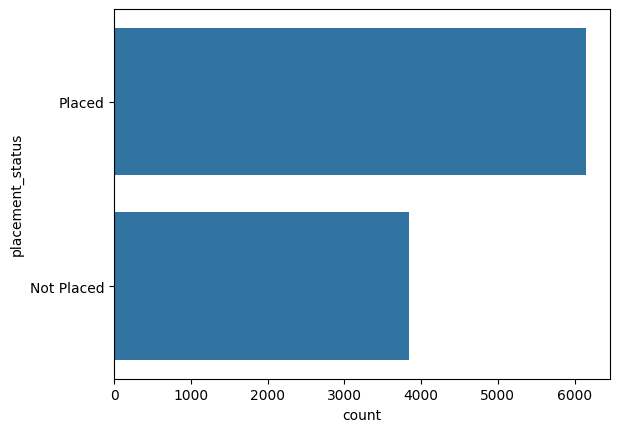

In [6]:
print(data['placement_status'].value_counts())

sns.countplot(data['placement_status'])

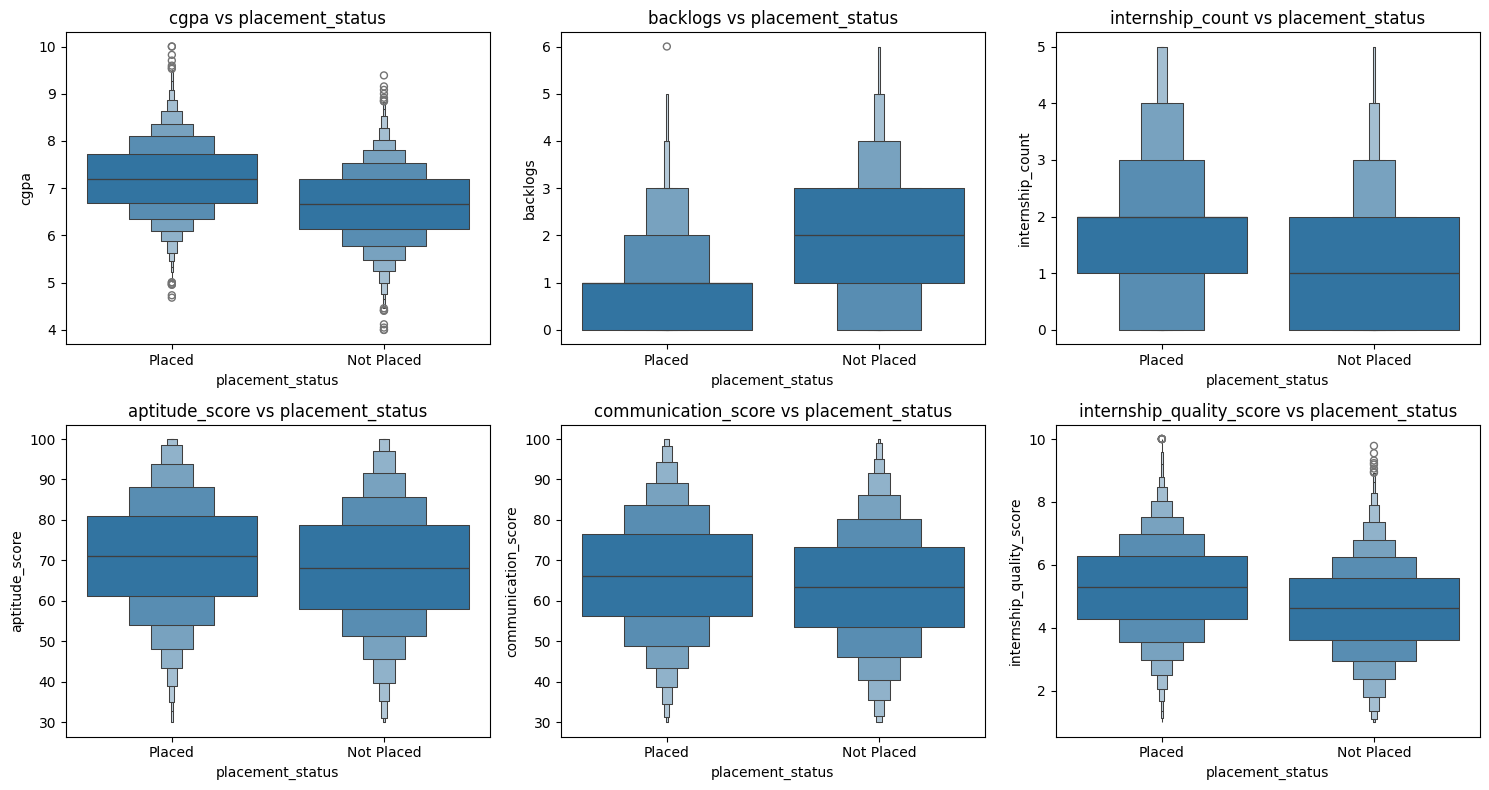

In [7]:
import math
numerical_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
n_cols = 3 
n_rows = math.ceil(len(numerical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxenplot(
        data=data,
        x='placement_status',
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs placement_status")
    axes[i].set_xlabel('placement_status')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

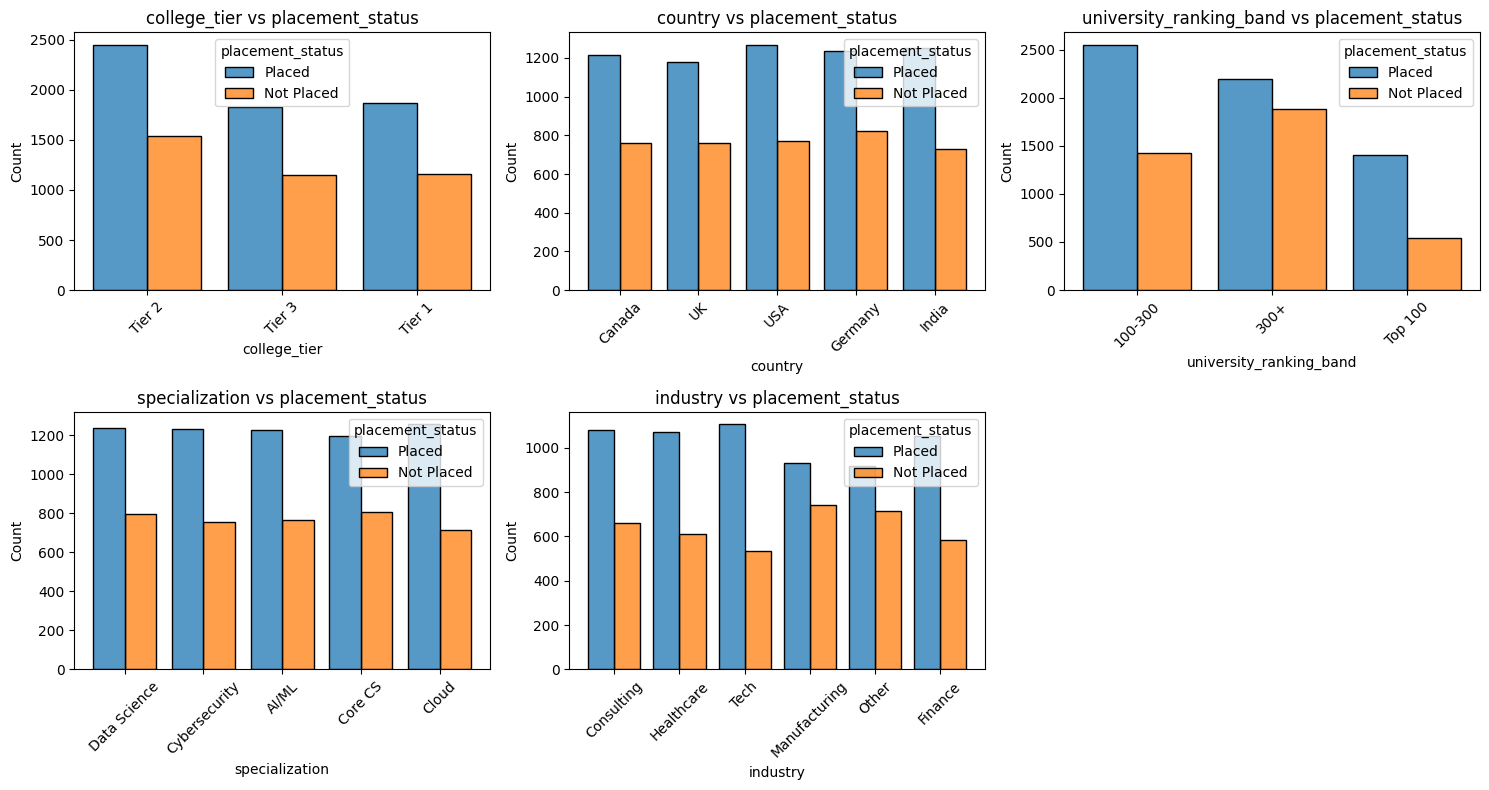

In [8]:
categorical_cols = data.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols.remove('placement_status')
n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.histplot(
        data=data,
        x=col,
        hue='placement_status',
        multiple="dodge",
        shrink=0.8,
        discrete=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} vs placement_status")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

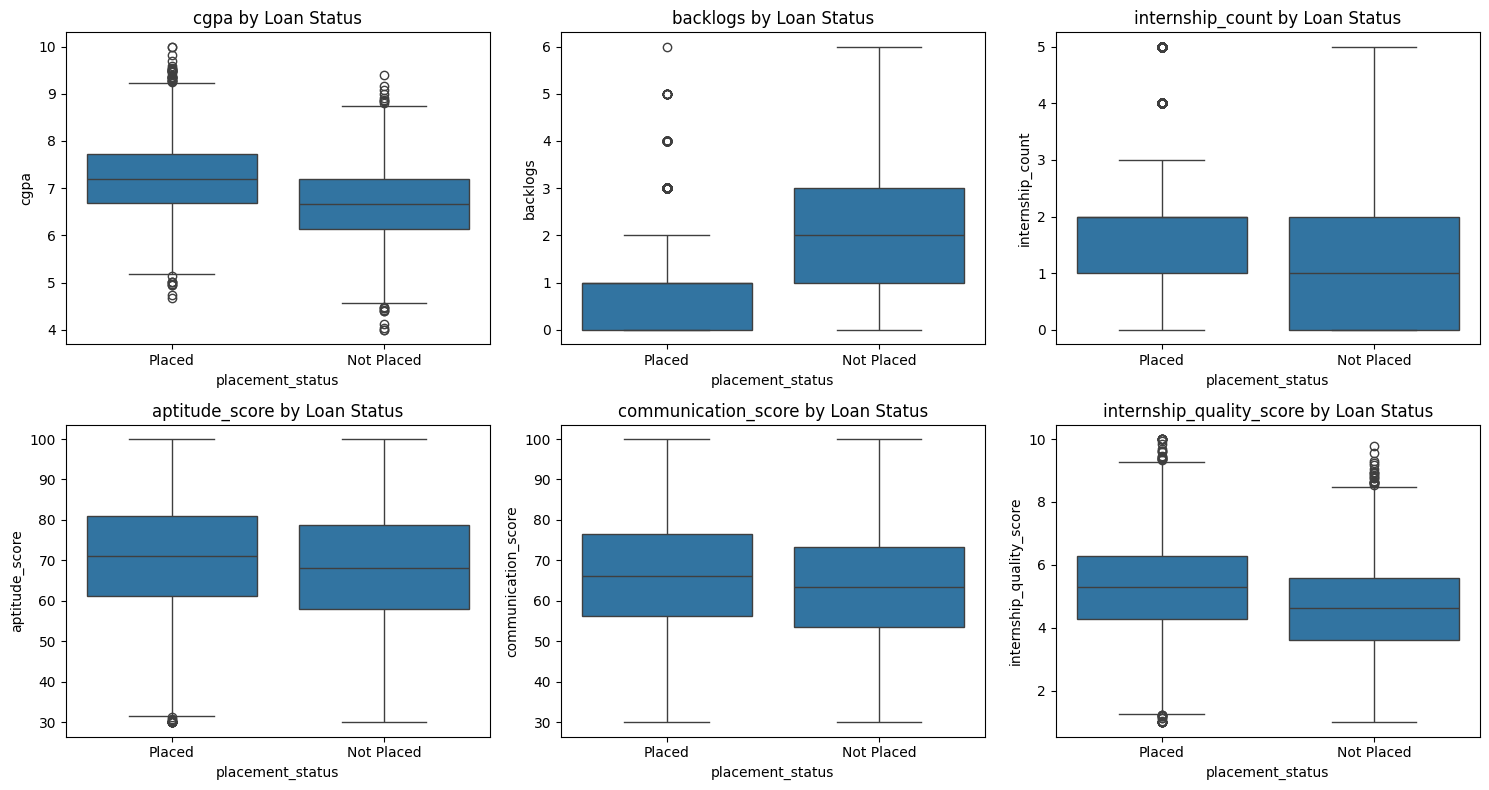

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numerical_cols):
    sns.boxplot(data=data, x='placement_status', y=col, ax=ax)
    ax.set_title(f'{col} by Loan Status')

plt.tight_layout()
plt.show()

In [10]:
#preprocessing
TARGET_COL = 'placement_status'

print("Categorical:", categorical_cols + ['placement_status'])
print("Numerical:  ", numerical_cols)

# Buat salinan
X = data.drop(columns=[TARGET_COL])
y = data[TARGET_COL]

Categorical: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry', 'placement_status']
Numerical:   ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']


In [11]:
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

label_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_),
    )
)
print("Label mapping:", label_mapping)

# Encode semua fitur kategorikal secara cepat
X_enc = pd.get_dummies(X, drop_first=True)

Label mapping: {'Not Placed': np.int64(0), 'Placed': np.int64(1)}


In [12]:
X_train_df, X_val_df, y_train_np, y_val_np = train_test_split(
    X_enc,
    y_enc,
    test_size=0.2,
    random_state=42,
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)
X_val = scaler.transform(X_val_df)

X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
y_train = y_train_np.astype(np.float32).reshape(-1, 1)
y_val = y_val_np.astype(np.float32).reshape(-1, 1)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)

X_train: (8000, 23) | y_train: (8000, 1)
X_val:   (2000, 23) | y_val:   (2000, 1)


In [13]:
def get_iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in numerical_cols:
    lower, upper = get_iqr_bounds(data[col])
    n = ((data[col] < lower) | (data[col] > upper)).sum()
    print(f"{col}: {n} outliers")


cgpa: 83 outliers
backlogs: 29 outliers
internship_count: 662 outliers
aptitude_score: 0 outliers
communication_score: 0 outliers
internship_quality_score: 36 outliers


In [14]:
input_dim = int(X_train.shape[1])
model = FFNN([input_dim, 12, 6, 3, 1], [Tanh, Tanh, Tanh, Sigmoid])

EPOCHS = 50
model.train(X_train, y_train, EPOCHS)

Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [01:11<00:00,  1.43s/it]


In [16]:
results = {}

def evaluate_model(model, X_val, y_val, model_name="Model"):
    model.predict(X_val)
    y_prob = model.result()
    y_pred = (y_prob >= 0.5).astype(int).reshape(-1)
    y_true = y_val.astype(int).reshape(-1)

    print(f"{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["not placed (0)", "placed (1)"],
        )
    )
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    print(f">>> Macro F1-Score: {macro_f1:.4f}\n")
    return macro_f1

Training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:46<00:00,  1.55s/it, loss=50648.265625]

  [WIDTH] w=8
                precision    recall  f1-score   support

not placed (0)       0.45      0.53      0.49       775
    placed (1)       0.67      0.60      0.63      1225

      accuracy                           0.57      2000
     macro avg       0.56      0.56      0.56      2000
  weighted avg       0.58      0.57      0.57      2000

>>> Macro F1-Score: 0.5577



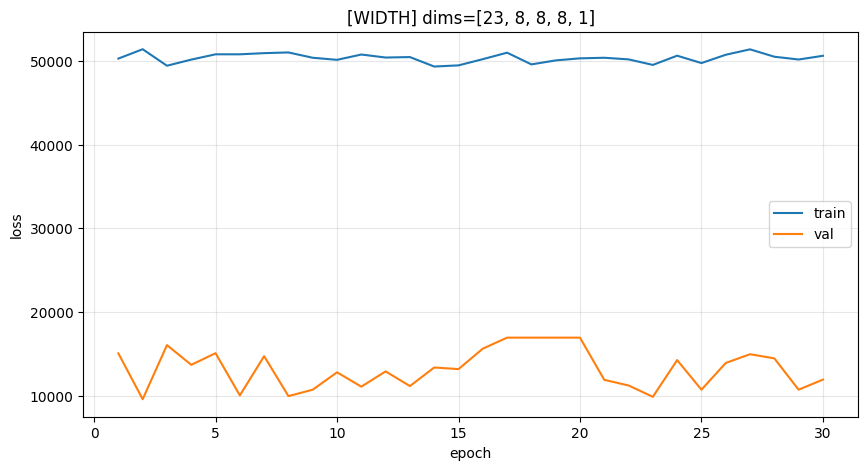

Training:   7%|███████▌                                                                                                         | 2/30 [00:03<00:50,  1.79s/it, loss=50800.152344]


KeyboardInterrupt: 

In [18]:
def plot_loss(loss_train, loss_val, title):
    ep = np.arange(1, len(loss_train) + 1)
    plt.figure(figsize=(10, 5))
    plt.plot(ep, loss_train, label="train")
    plt.plot(ep, loss_val, label="val")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

epochs = 30
lr = 0.1
input_dim = int(X_train.shape[1])

widths = [8, 16, 32]
res_width = []
for w in widths:
    dims = [input_dim, w, w, w, 1]
    model = FFNN(dims, [Tanh, Tanh, Tanh, Sigmoid], BCE, lr)
    model.train(X_train, y_train, epochs, True, None, X_val, y_val)

    f1 = evaluate_model(model, X_val, y_val, model_name=f"[WIDTH] w={w}")
    plot_loss(model.training_loss, model.validation_loss, title=f"[WIDTH] dims={dims}")
    res_width.append({"w": w, "dims": dims, "macro_f1": f1})
    
print("Summary width:", res_width)

width_fixed = 16
depths = [1, 2, 4]
res_depth = []
for d in depths:
    dims = [input_dim] + [width_fixed] * d + [1]
    acts = [Tanh] * d + [Sigmoid]
    model = FFNN(dims, acts, BCE, lr)
    model.train(X_train, y_train, epochs, True, None, X_val, y_val)

    f1 = evaluate_model(model, X_val, y_val, model_name=f"[DEPTH] hidden={d}")
    plot_loss(model.training_loss, model.validation_loss, title=f"[DEPTH] dims={dims}")
    res_depth.append({"d": d, "dims": dims, "macro_f1": f1})

print("Summary depth:", res_depth)

Training: 100%|██████████| 30/30 [00:13<00:00,  2.14it/s, loss=4378.375488]

  [ACT] h1=Linear
                precision    recall  f1-score   support

not placed (0)       0.64      0.77      0.70       775
    placed (1)       0.83      0.73      0.78      1225

      accuracy                           0.75      2000
     macro avg       0.74      0.75      0.74      2000
  weighted avg       0.76      0.75      0.75      2000

>>> Macro F1-Score: 0.7403



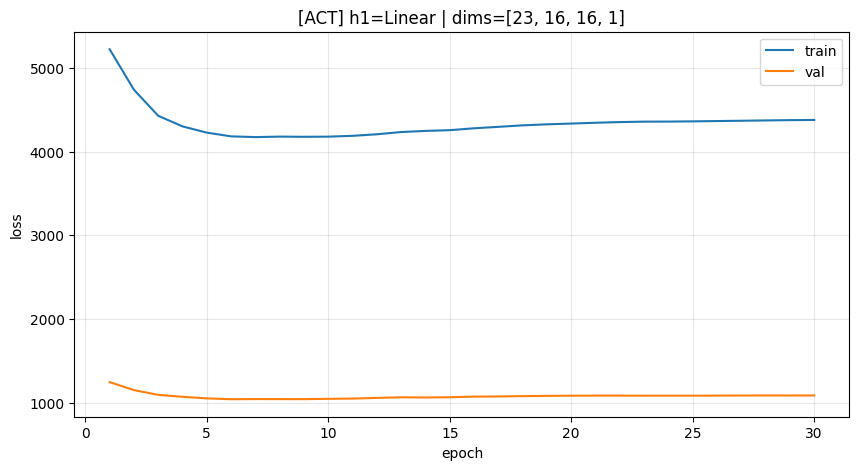

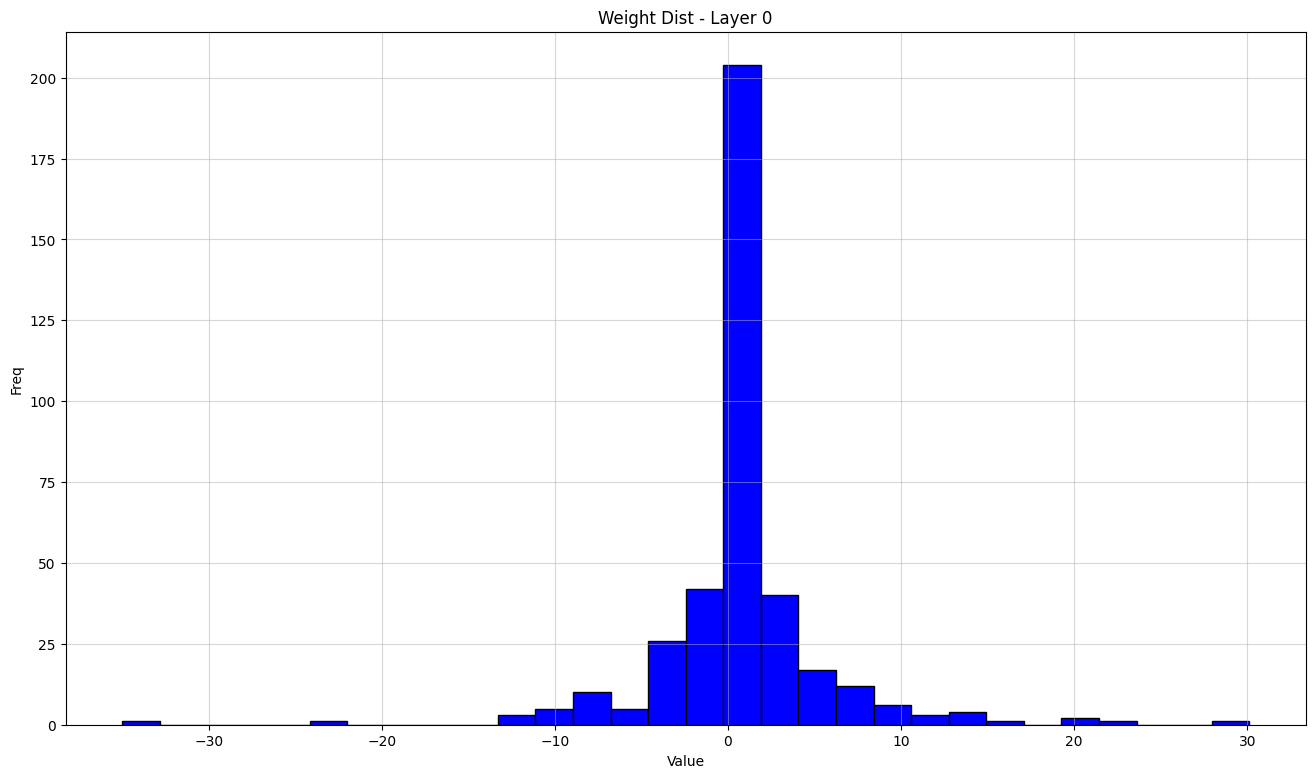

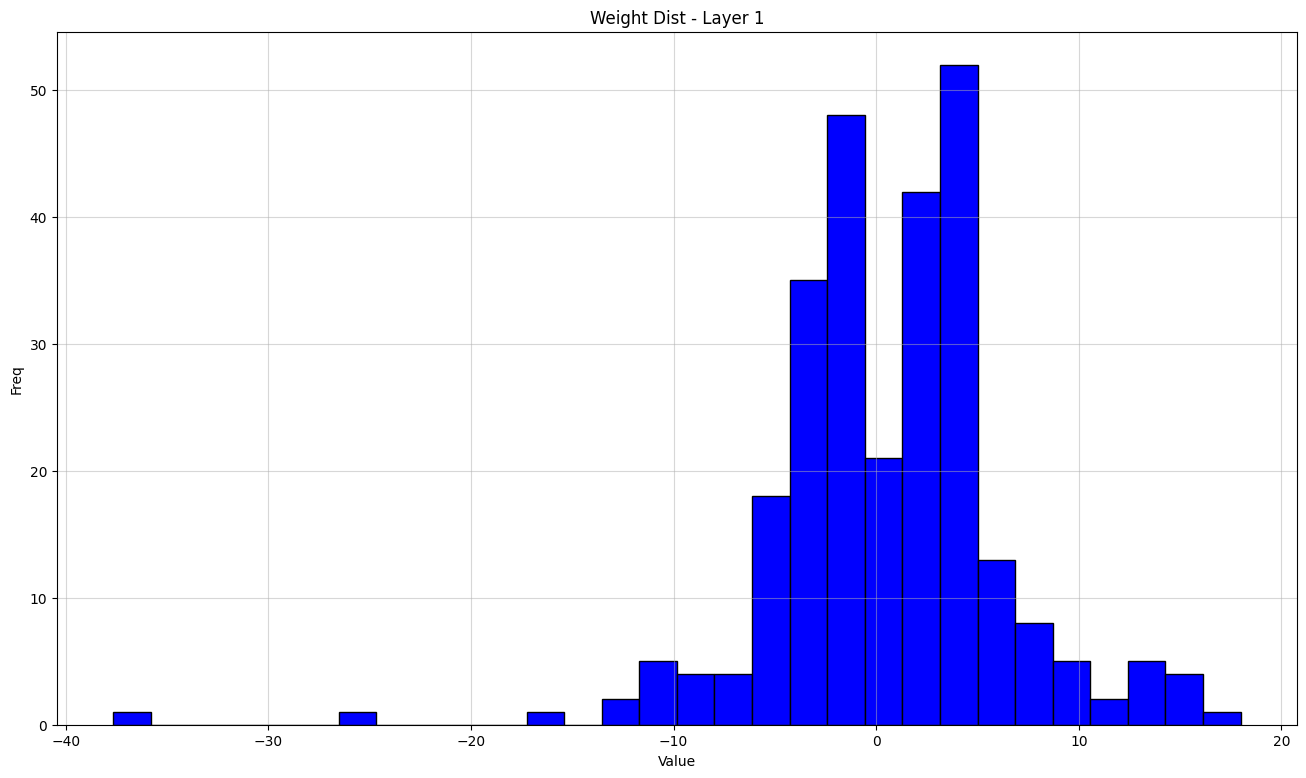

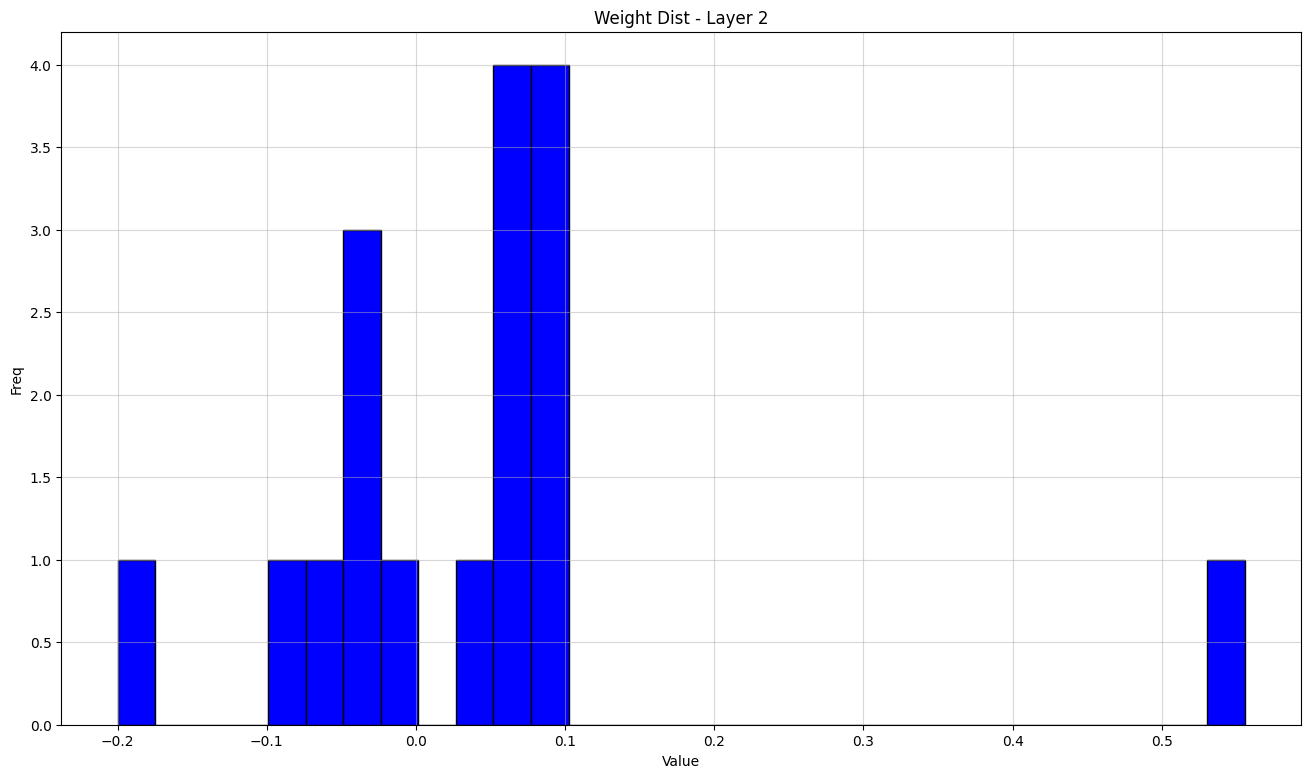

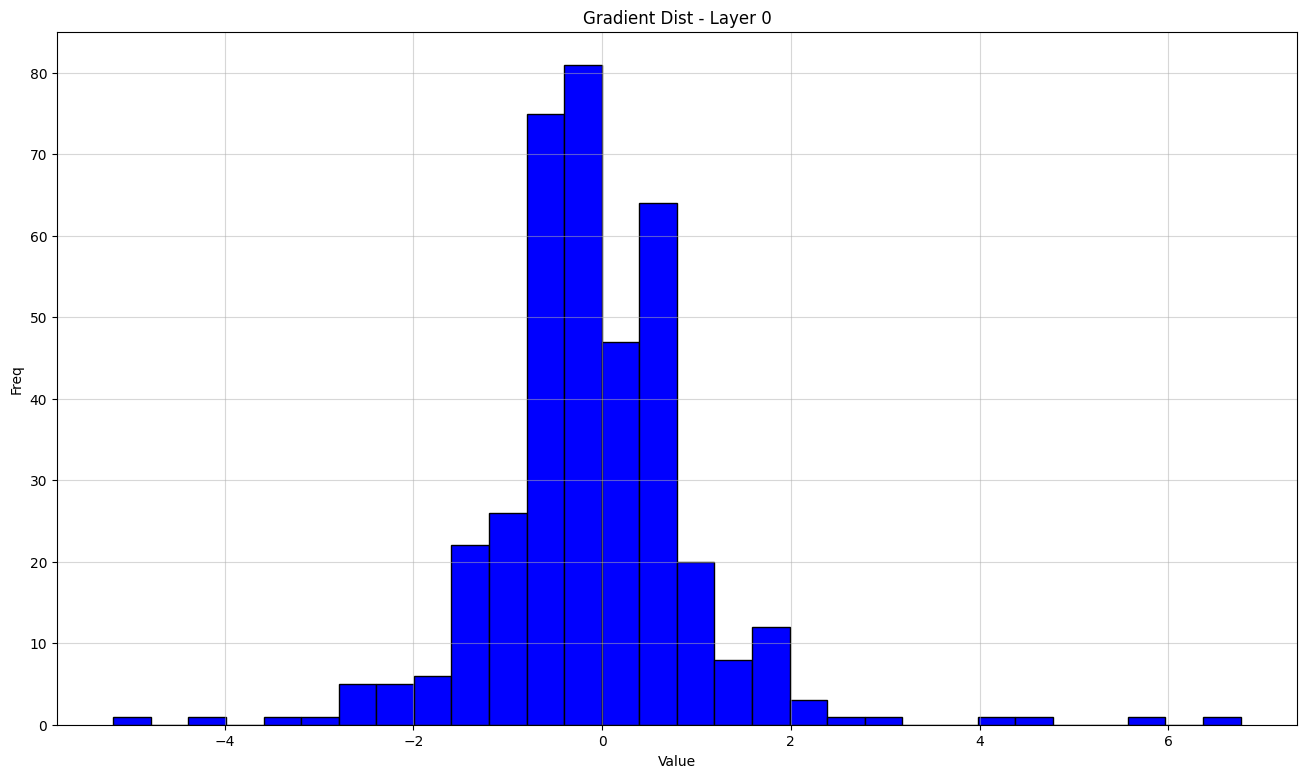

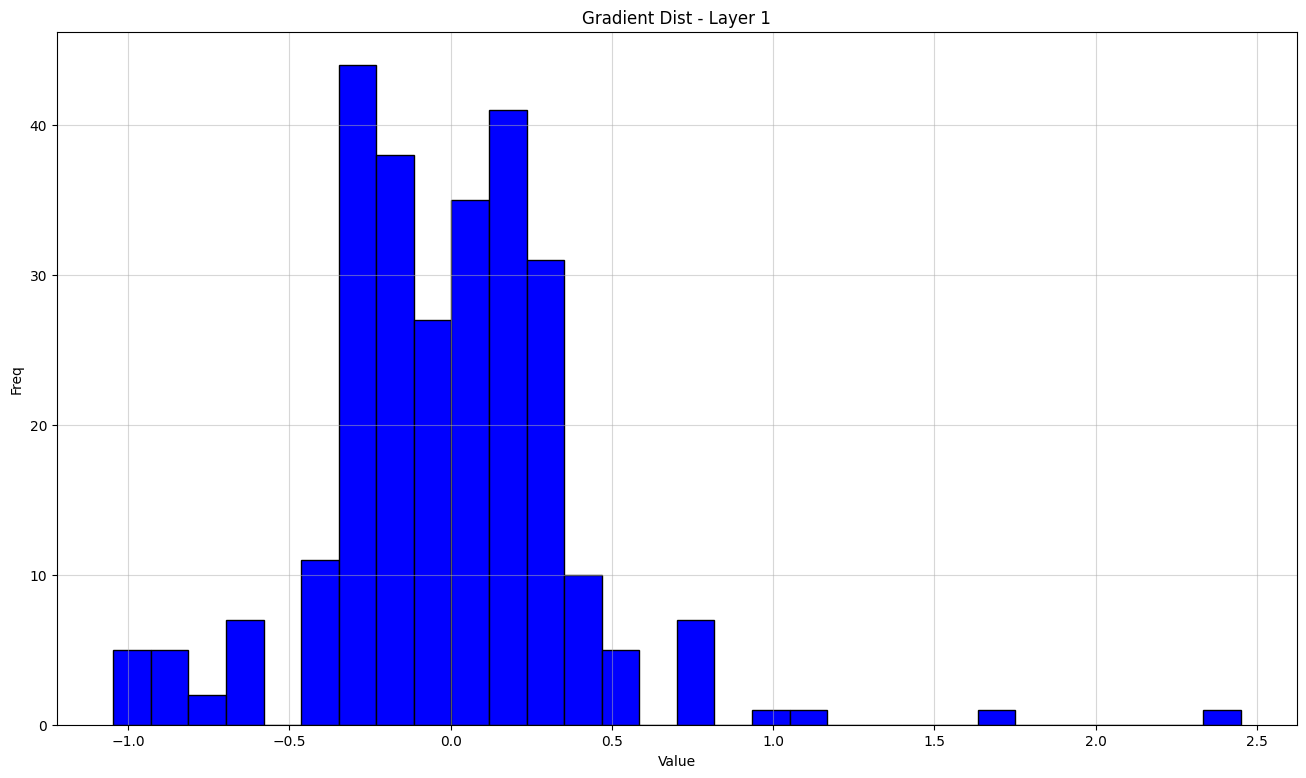

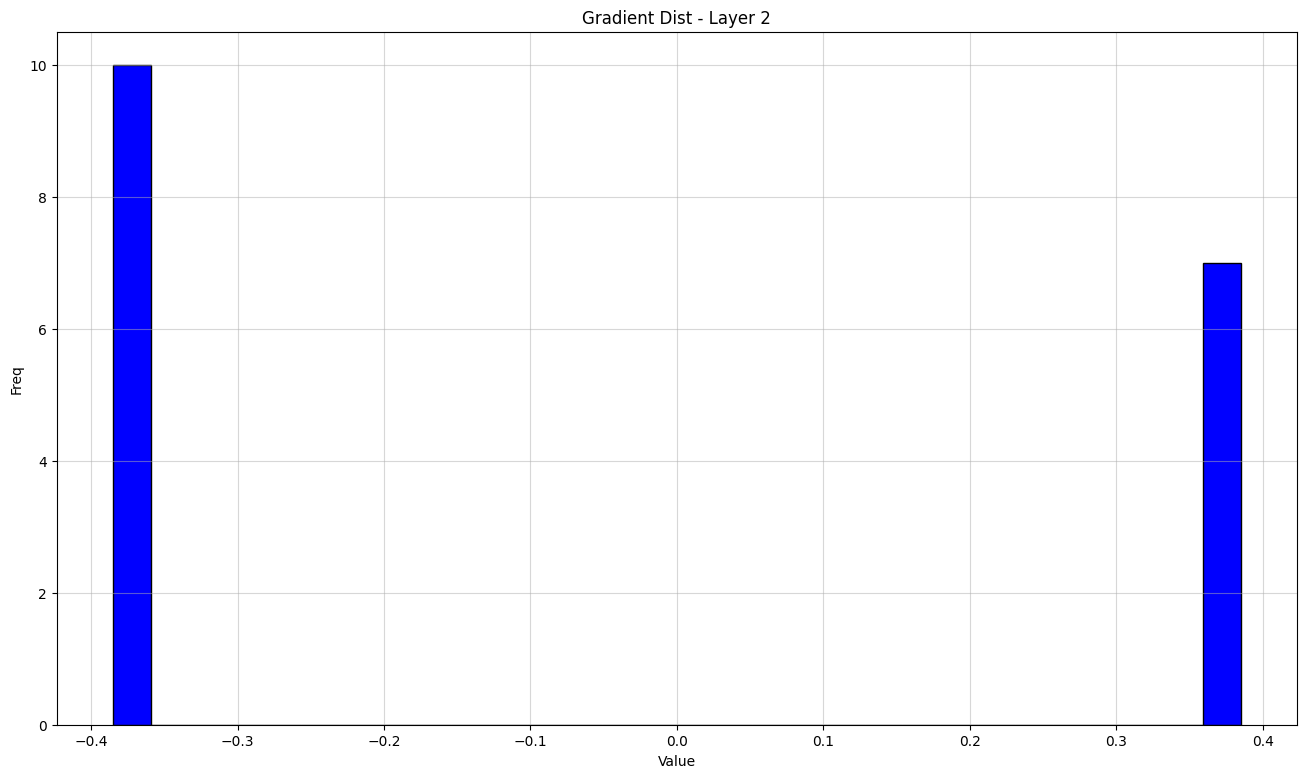

Training: 100%|██████████| 30/30 [00:15<00:00,  1.98it/s, loss=4251.713379]

  [ACT] h1=ReLU
                precision    recall  f1-score   support

not placed (0)       0.69      0.67      0.68       775
    placed (1)       0.79      0.81      0.80      1225

      accuracy                           0.76      2000
     macro avg       0.74      0.74      0.74      2000
  weighted avg       0.76      0.76      0.76      2000

>>> Macro F1-Score: 0.7423



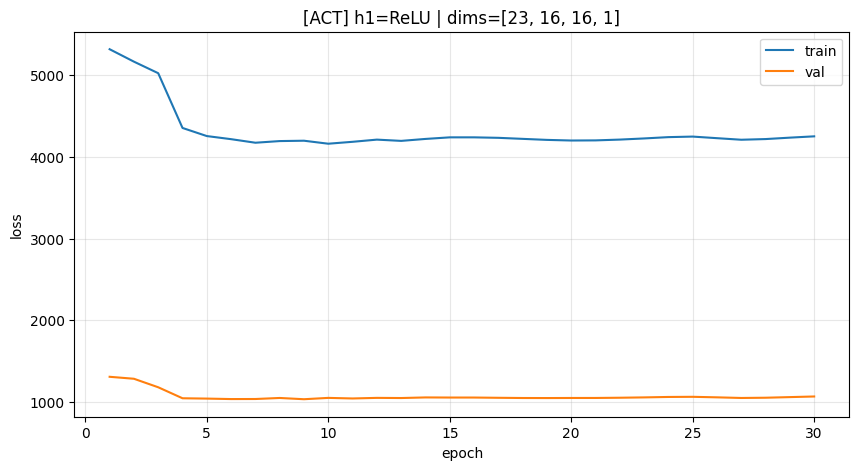

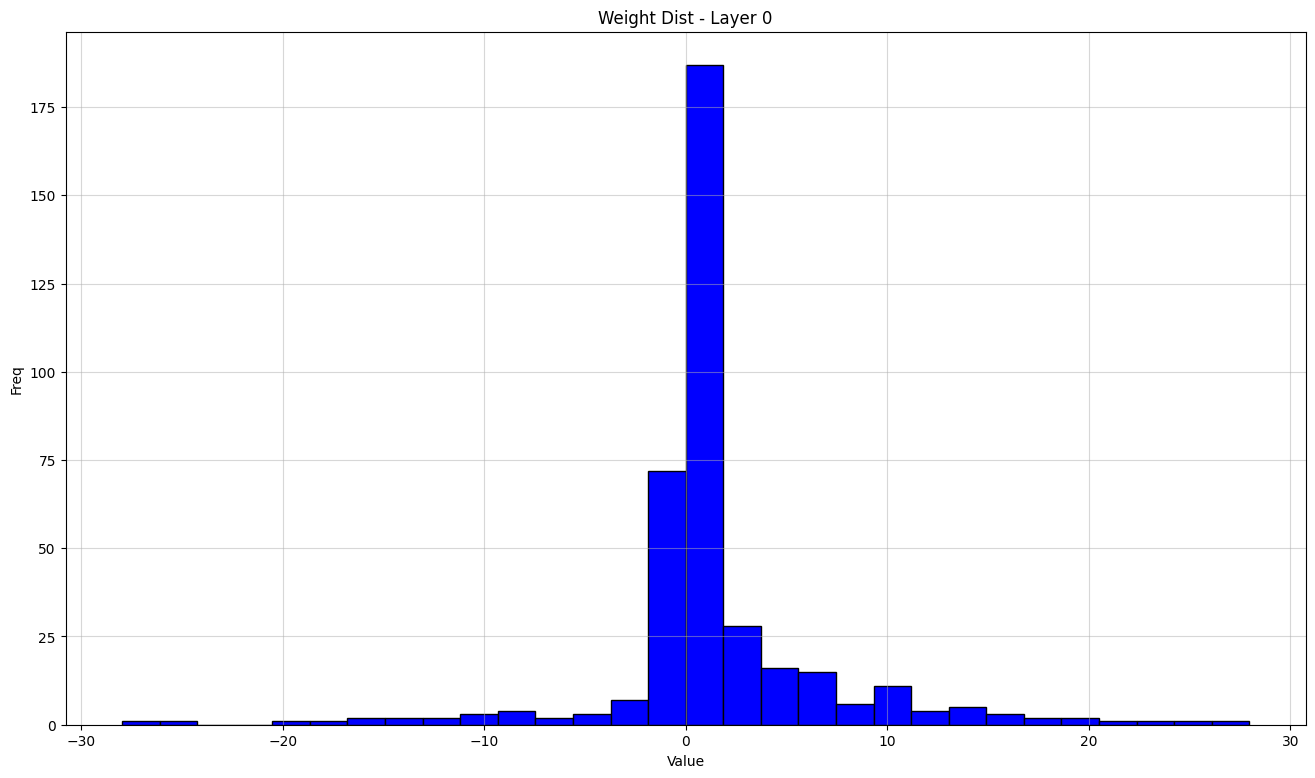

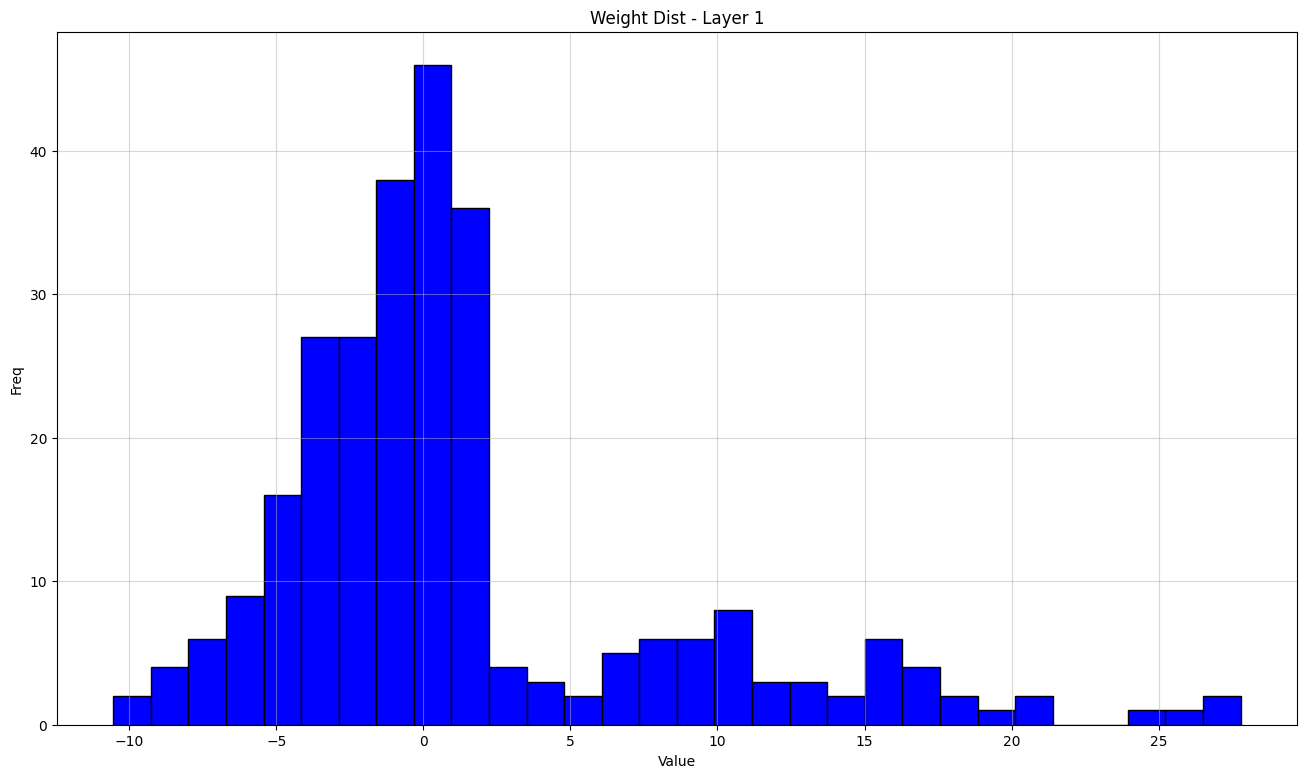

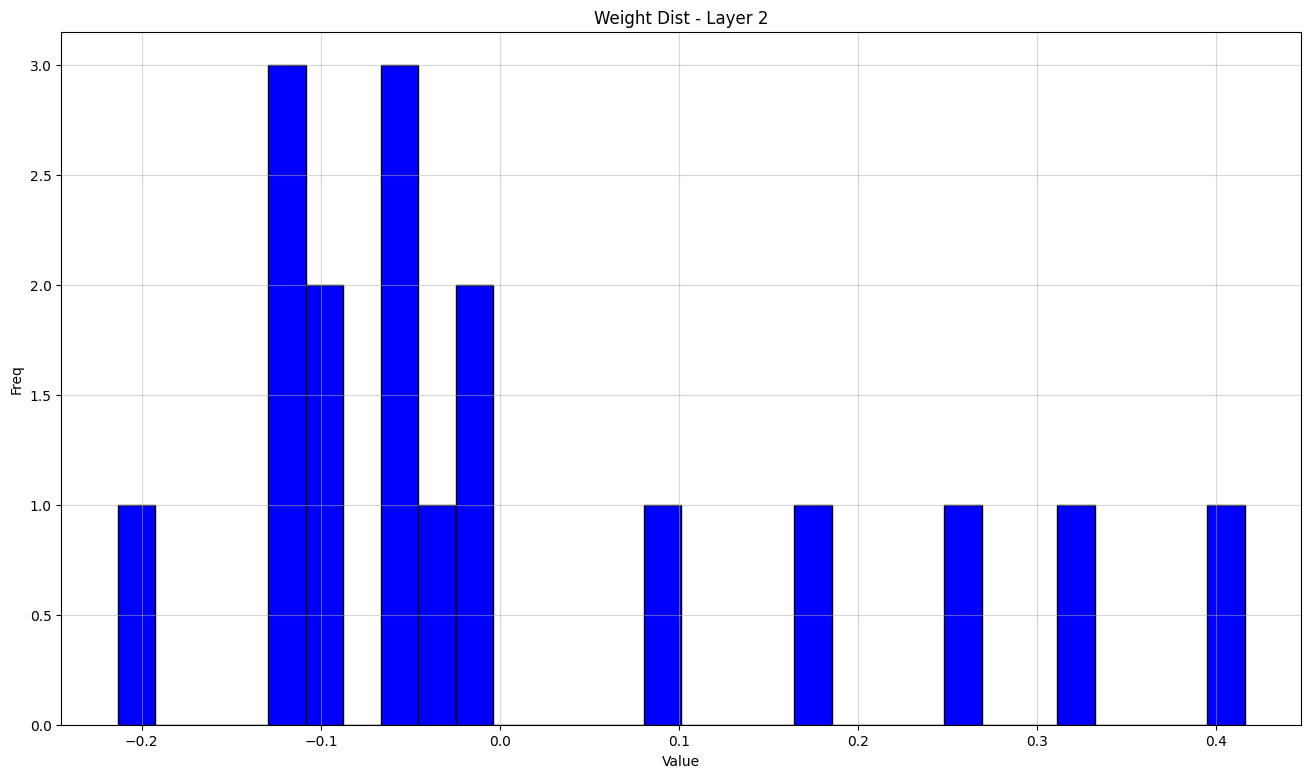

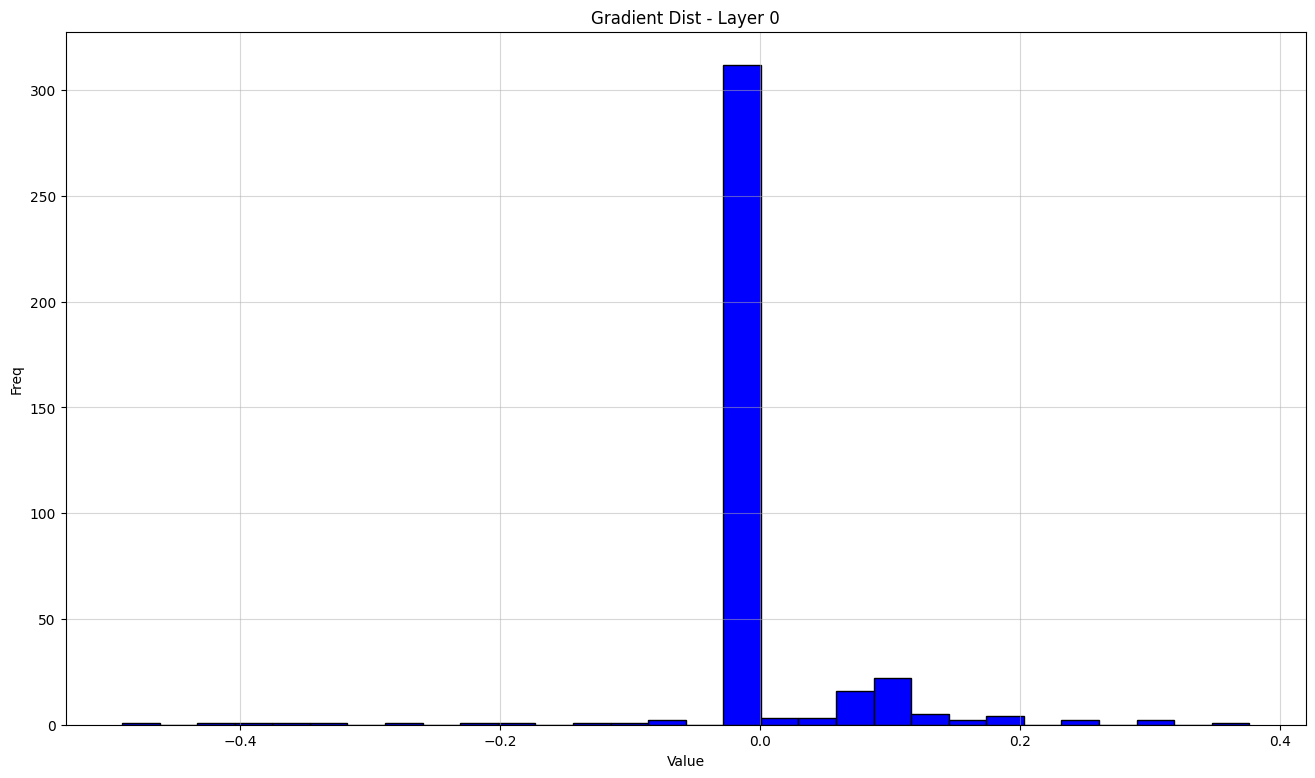

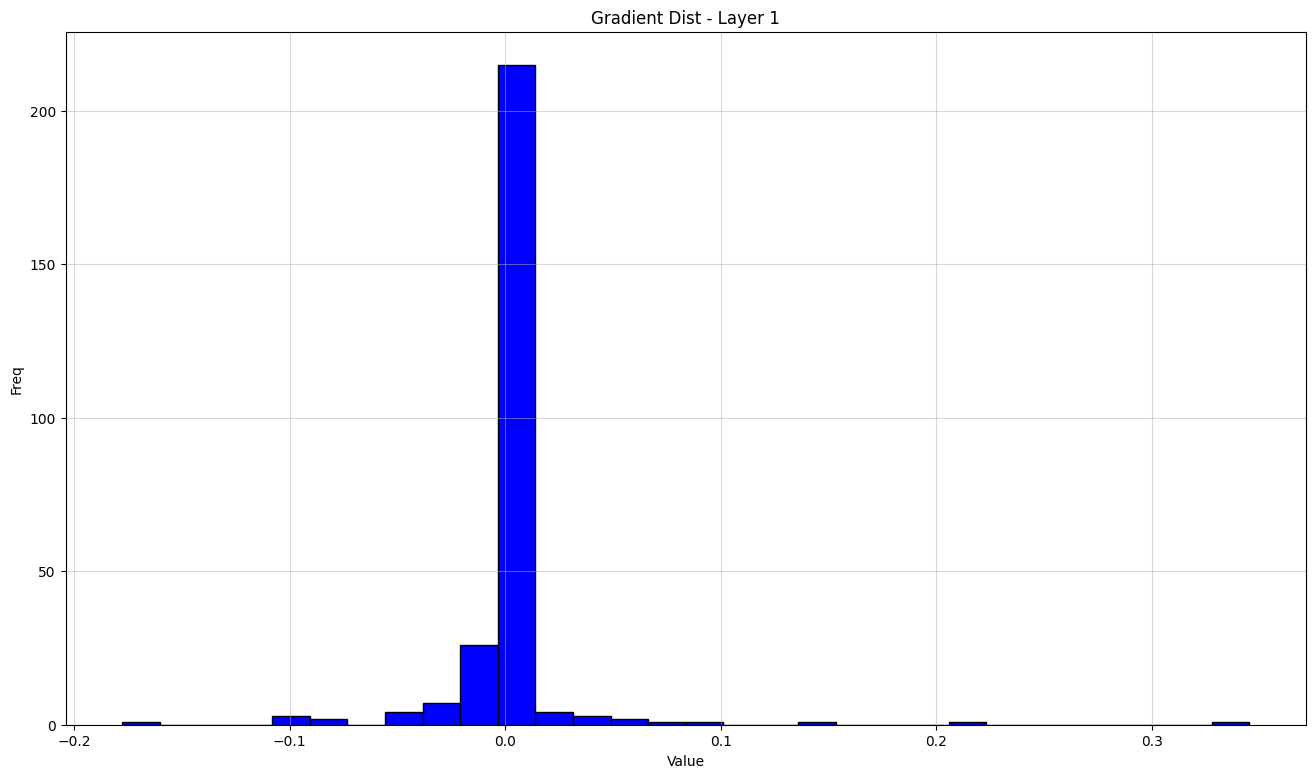

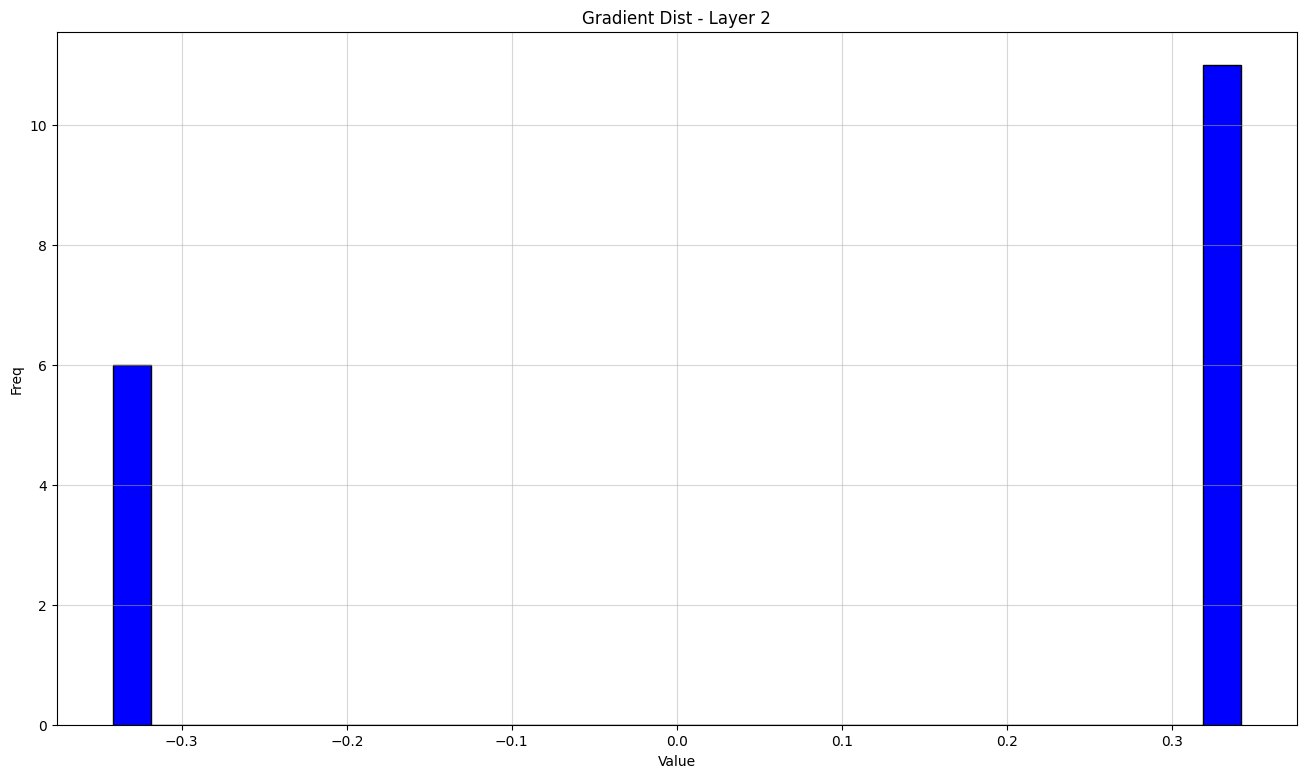

Training: 100%|██████████| 30/30 [00:17<00:00,  1.72it/s, loss=4077.812988]

  [ACT] h1=Sigmoid
                precision    recall  f1-score   support

not placed (0)       0.77      0.54      0.63       775
    placed (1)       0.75      0.90      0.82      1225

      accuracy                           0.76      2000
     macro avg       0.76      0.72      0.73      2000
  weighted avg       0.76      0.76      0.75      2000

>>> Macro F1-Score: 0.7259



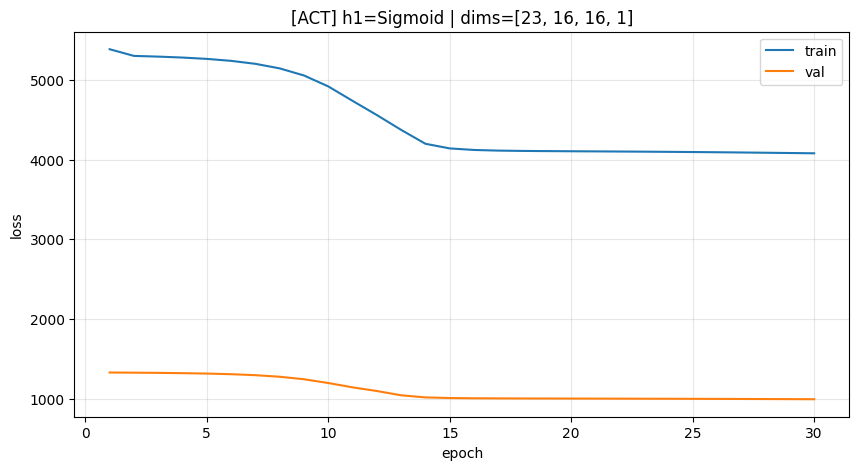

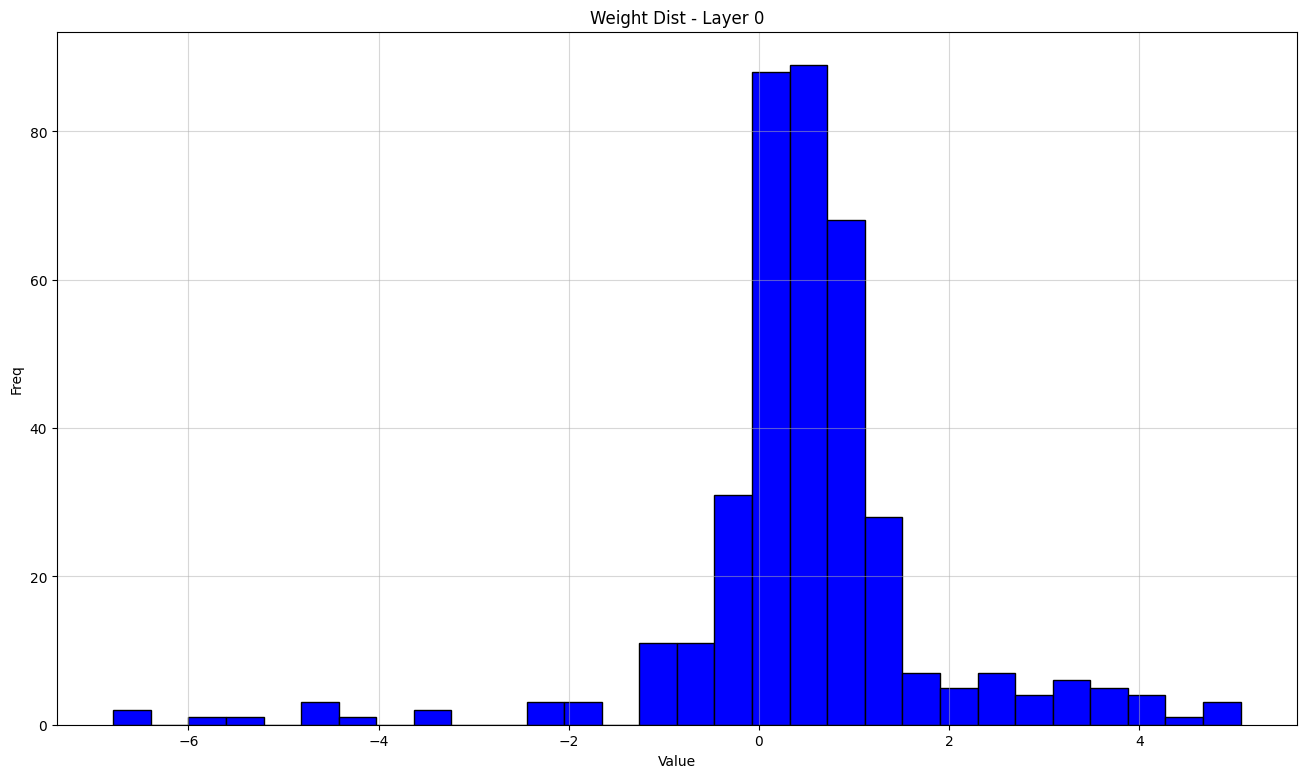

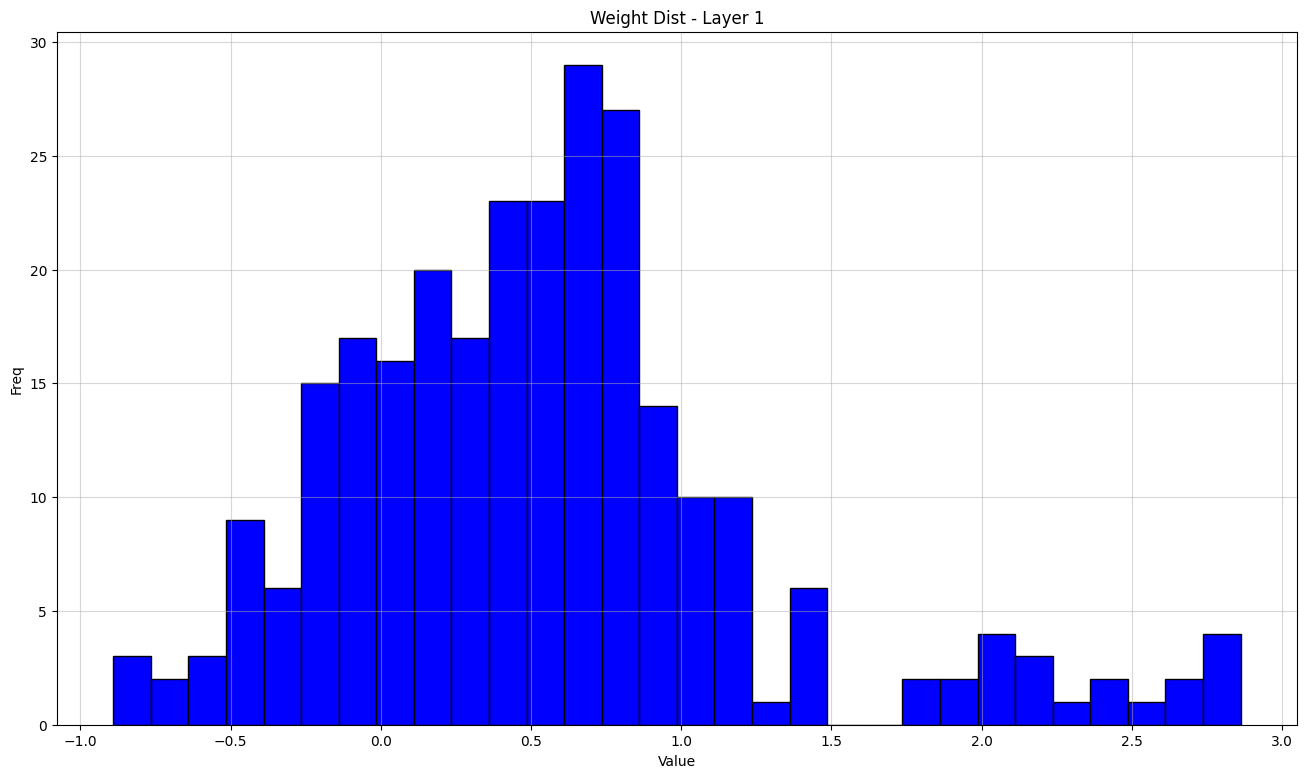

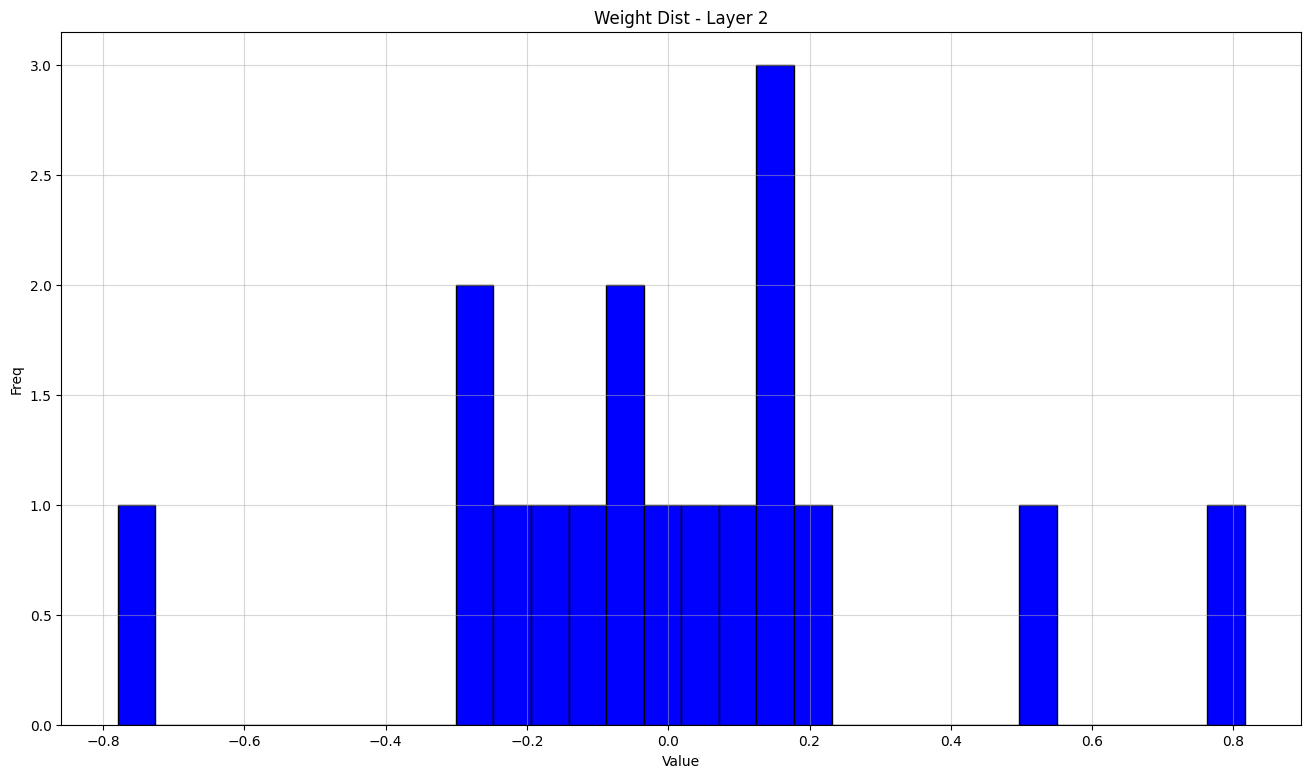

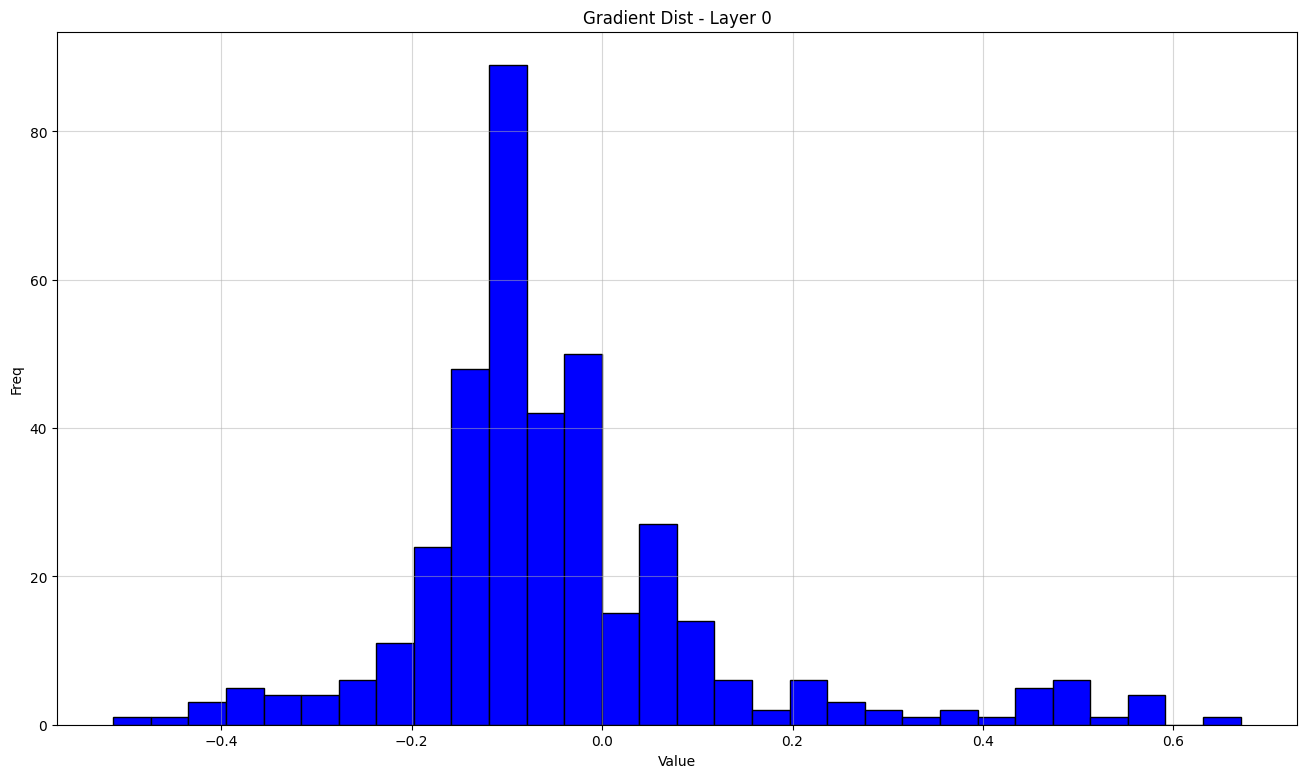

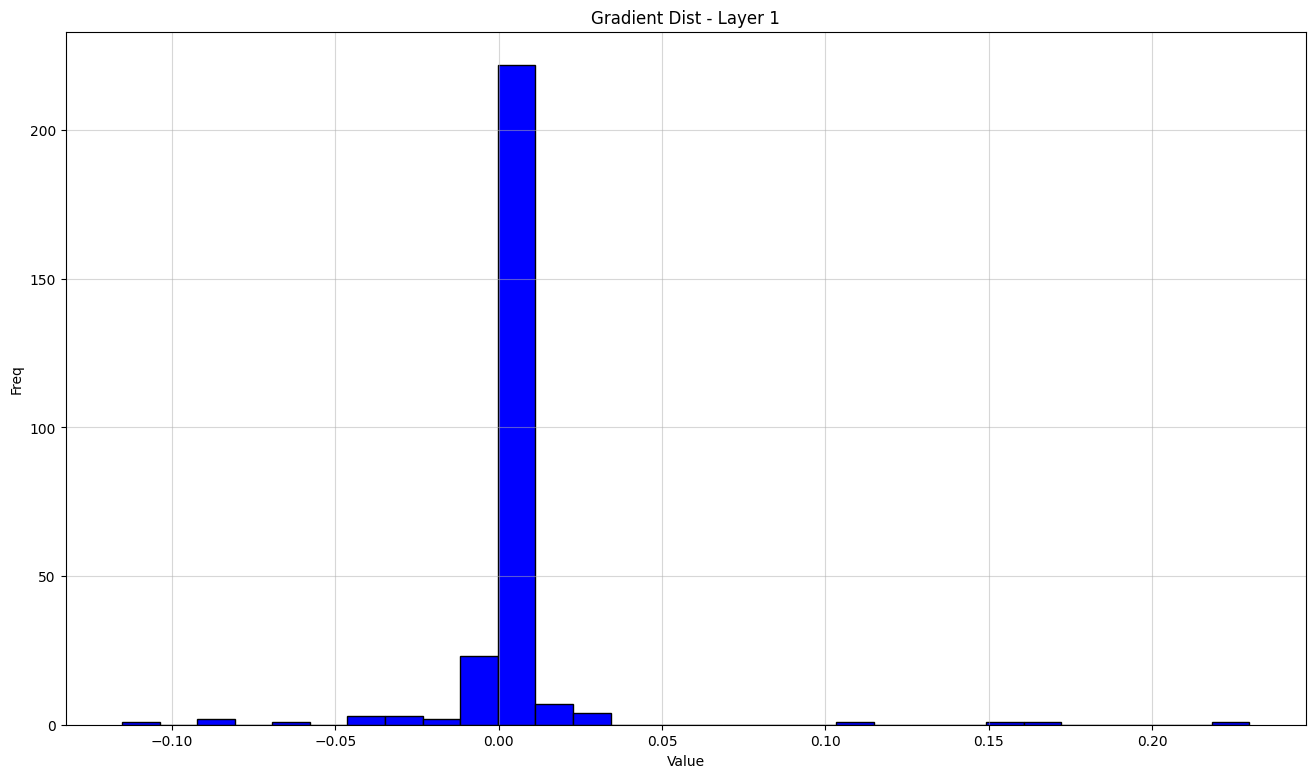

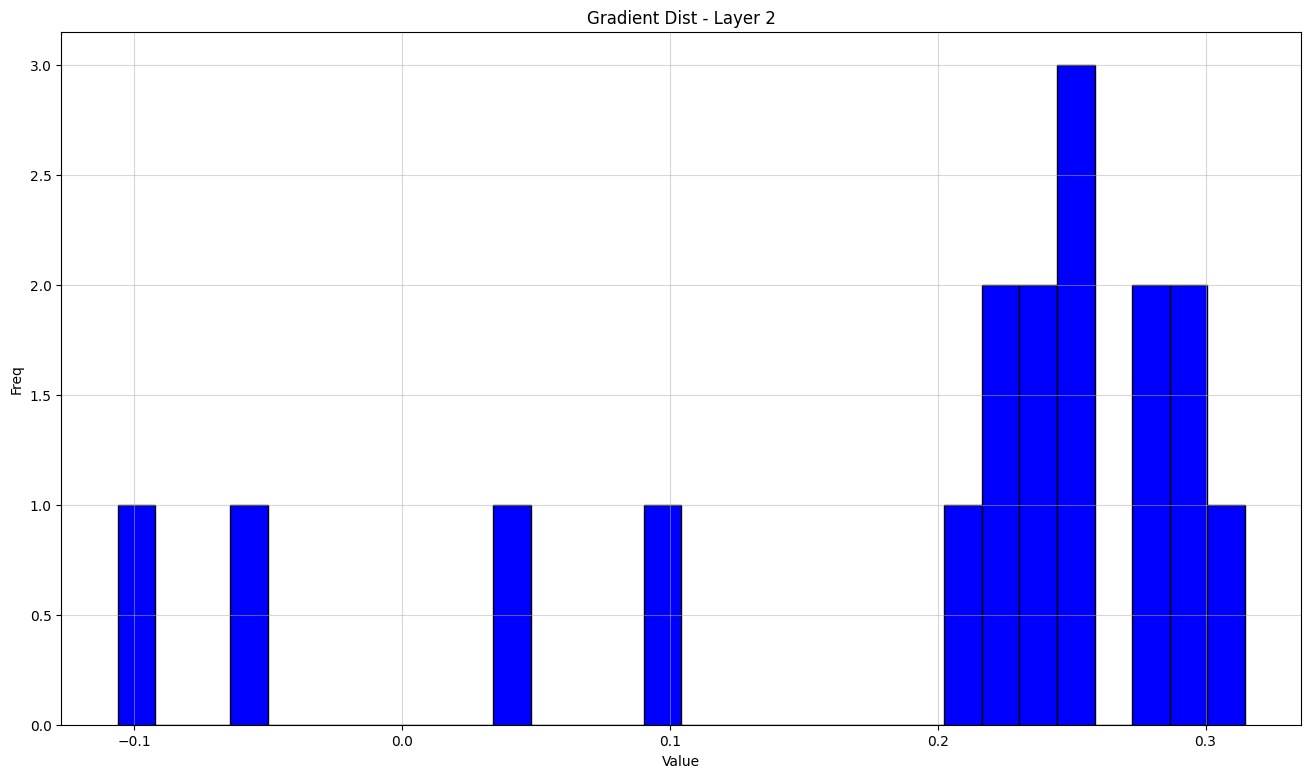

Training: 100%|██████████| 30/30 [00:14<00:00,  2.03it/s, loss=4076.620117]

  [ACT] h1=Tanh
                precision    recall  f1-score   support

not placed (0)       0.70      0.63      0.66       775
    placed (1)       0.78      0.83      0.80      1225

      accuracy                           0.75      2000
     macro avg       0.74      0.73      0.73      2000
  weighted avg       0.75      0.75      0.75      2000

>>> Macro F1-Score: 0.7345



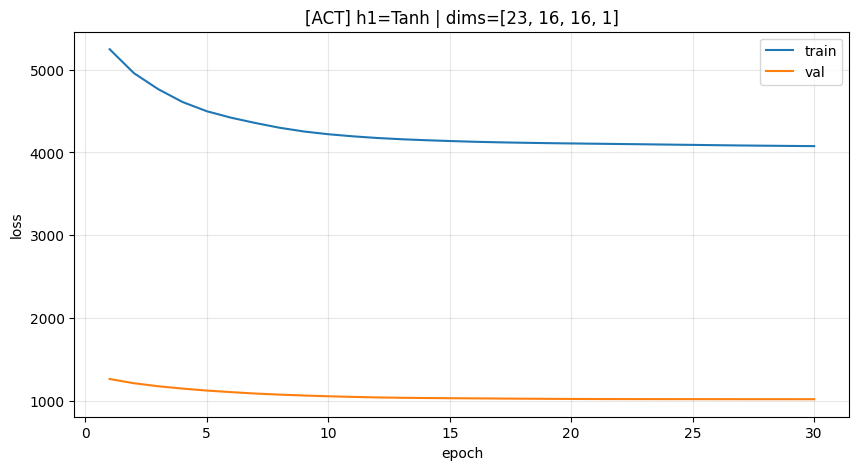

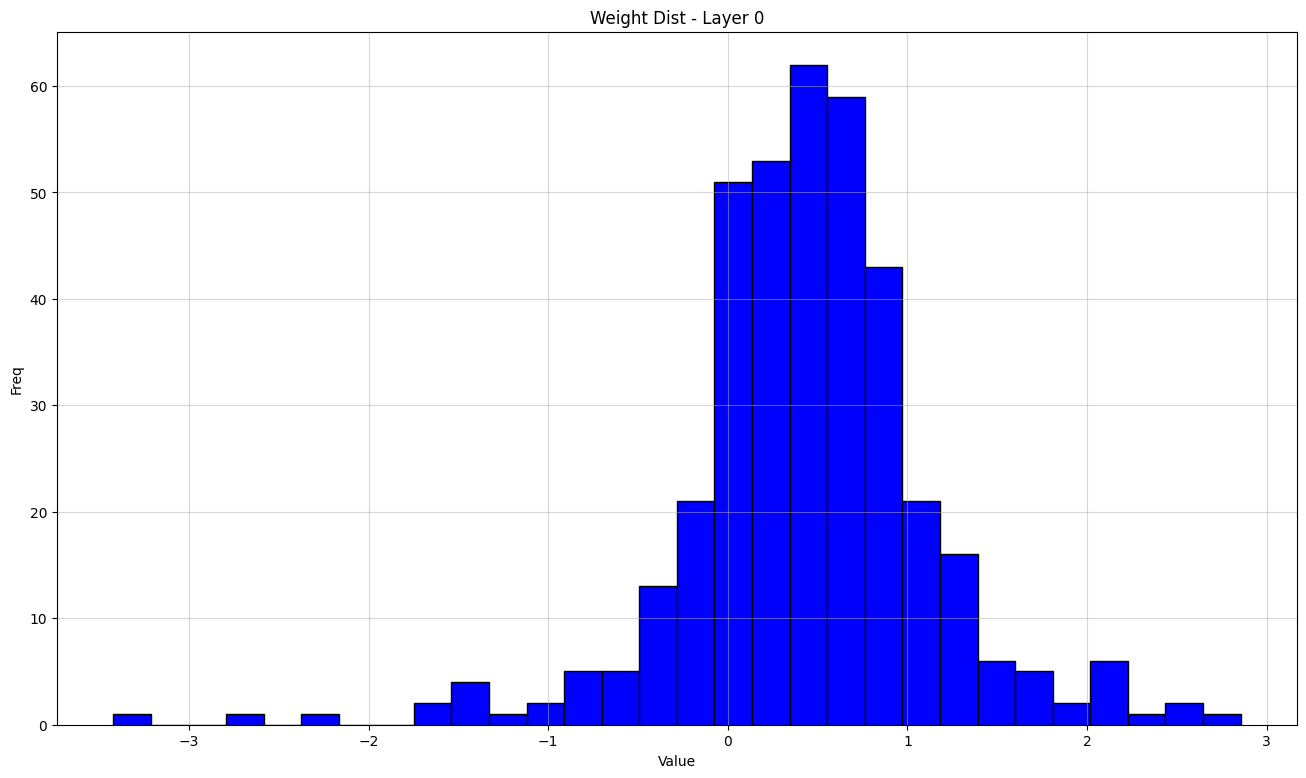

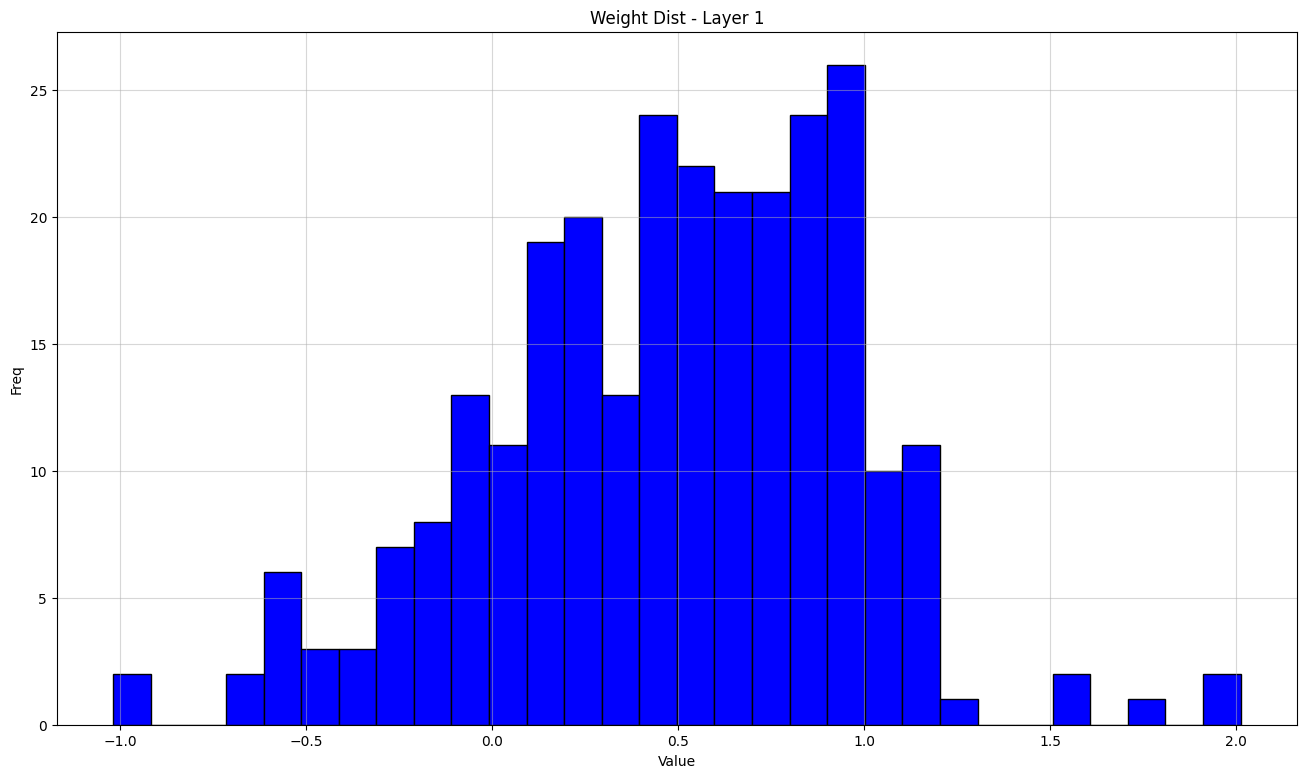

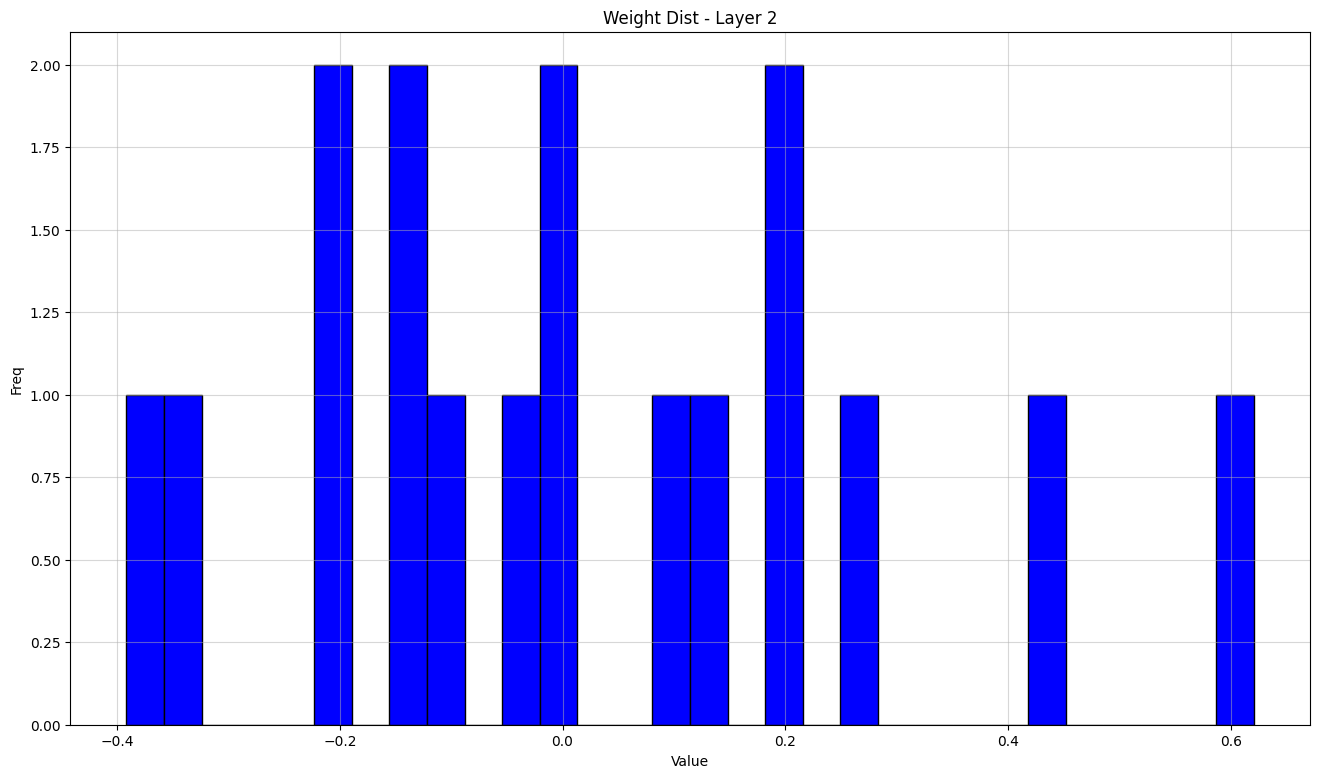

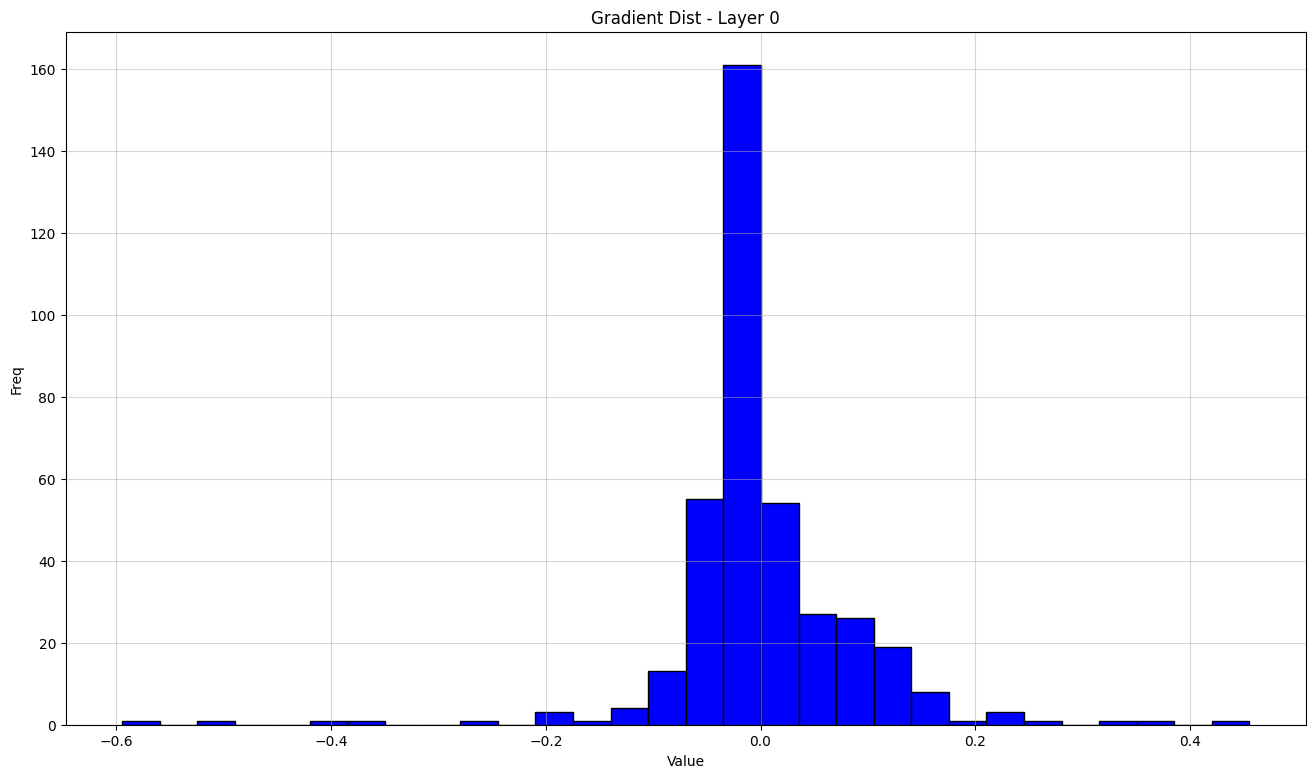

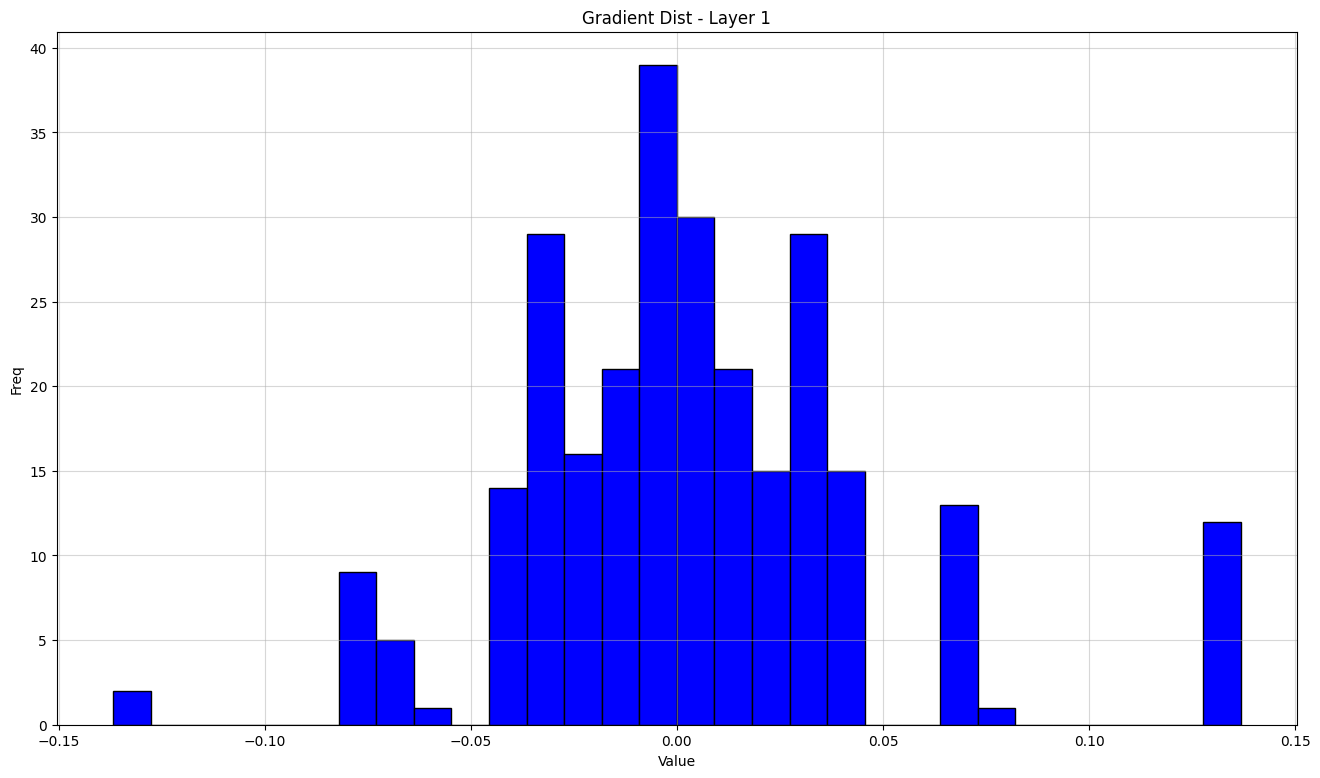

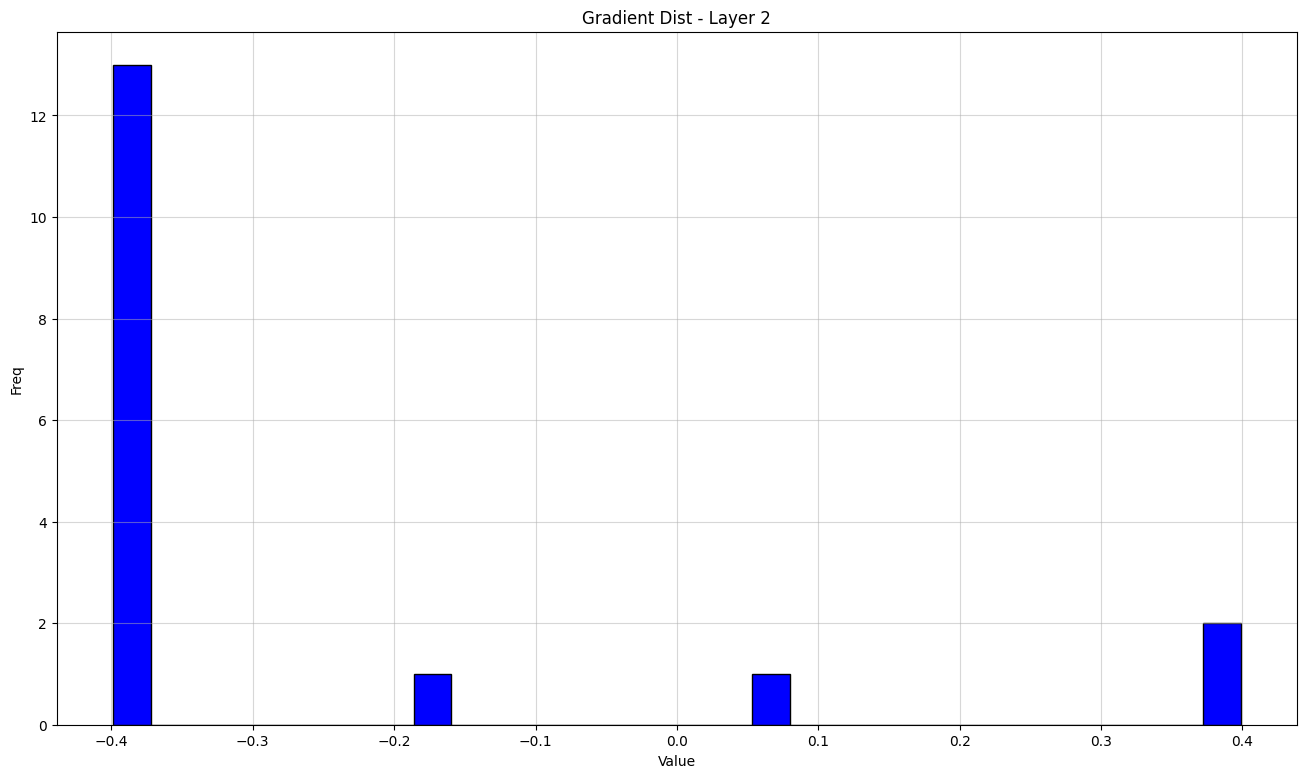

Summary act: [{'act': 'Linear', 'macro_f1': 0.7403117894358018}, {'act': 'ReLU', 'macro_f1': 0.7422787017210055}, {'act': 'Sigmoid', 'macro_f1': 0.7259454880661718}, {'act': 'Tanh', 'macro_f1': 0.7344953907539901}]


In [40]:
epochs = 30
lr = 0.001
input_dim = int(X_train.shape[1])
dims = [input_dim, 16, 16, 1]

acts = [Linear, ReLU, Sigmoid, Tanh]
res_act = []

for act in acts:
    model = FFNN(dims, [act, Tanh, Sigmoid], BCE, lr)
    model.train(X_train, y_train, epochs, True, None, X_val, y_val)
    loss_train = model.training_loss
    loss_val = model.validation_loss
    f1 = evaluate_model(model, X_val, y_val, model_name=f"[ACT] h1={act.__name__}")
    plot_loss(loss_train, loss_val, title=f"[ACT] h1={act.__name__} | dims={dims}")
    model.plot_w([0, 1, 2])
    model.plot_g([0, 1, 2])
    res_act.append({"act": act.__name__, "macro_f1": f1})
print("Summary act:", res_act)

Training: 100%|██████████| 30/30 [00:14<00:00,  2.08it/s, loss=4076.620117]

  [LR] lr=0.001
                precision    recall  f1-score   support

not placed (0)       0.70      0.63      0.66       775
    placed (1)       0.78      0.83      0.80      1225

      accuracy                           0.75      2000
     macro avg       0.74      0.73      0.73      2000
  weighted avg       0.75      0.75      0.75      2000

>>> Macro F1-Score: 0.7345



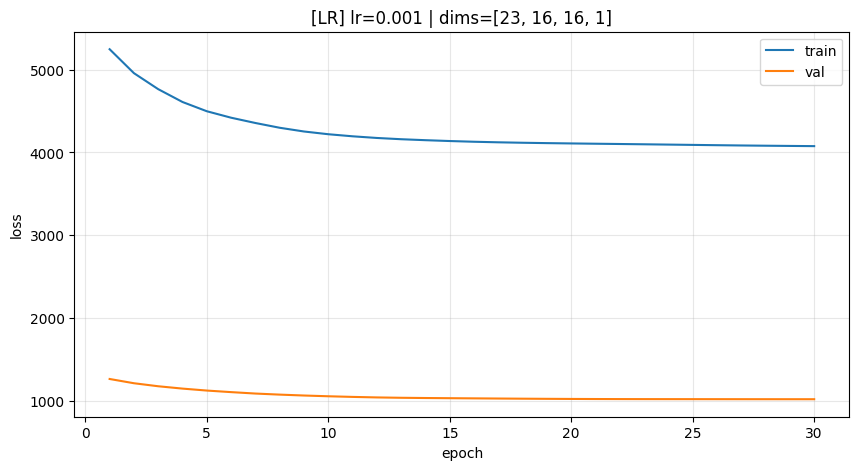

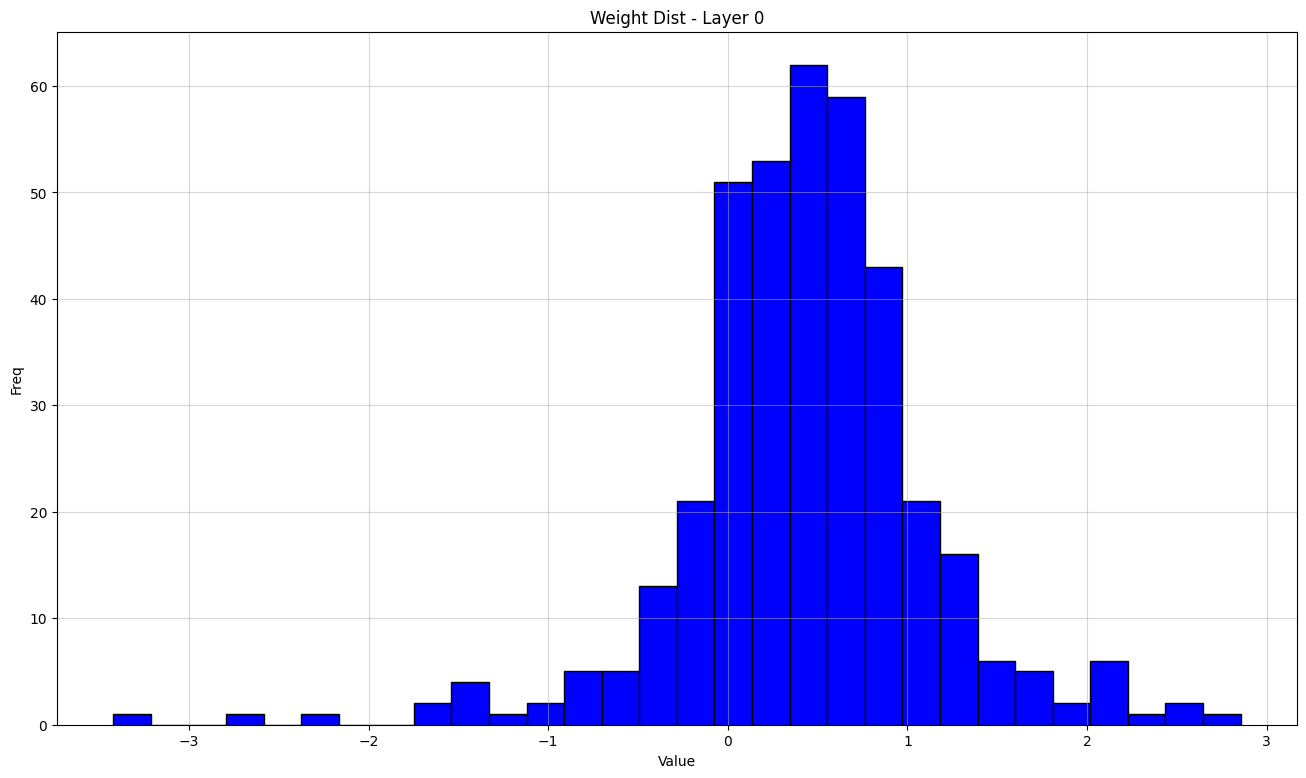

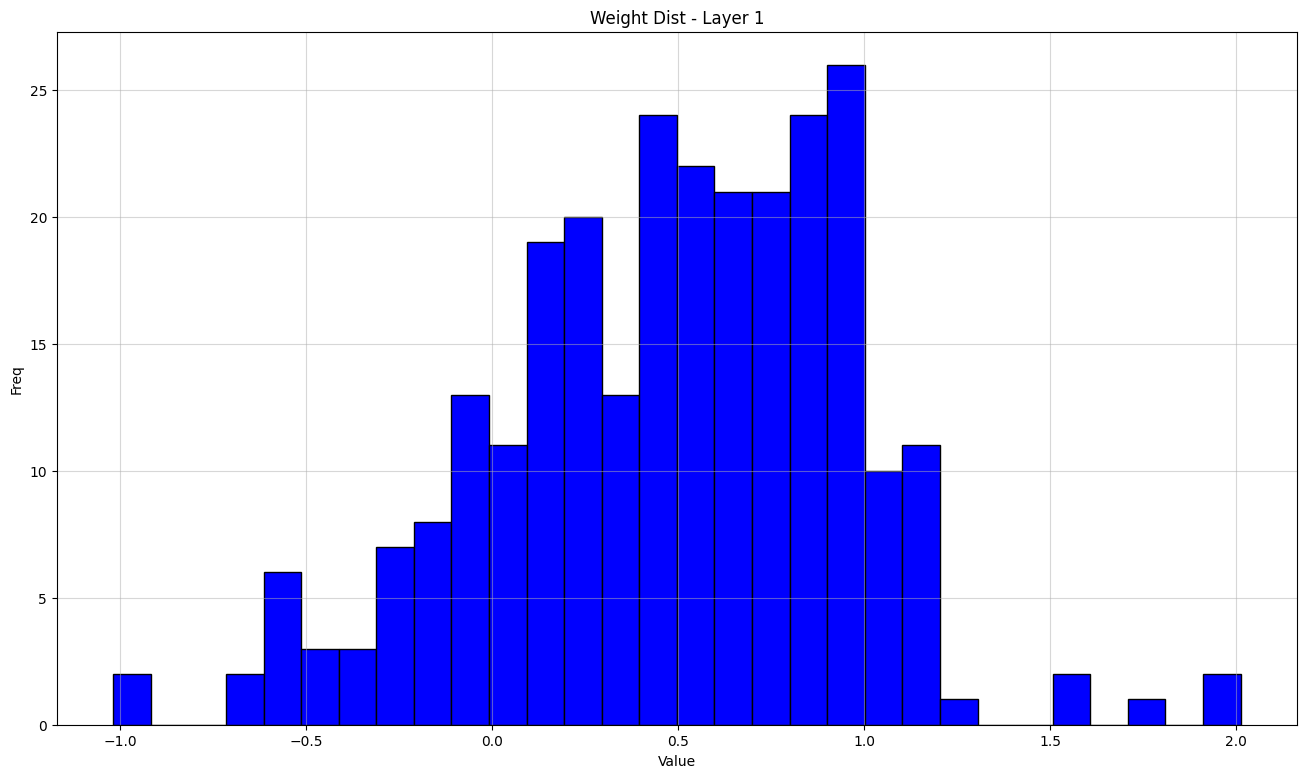

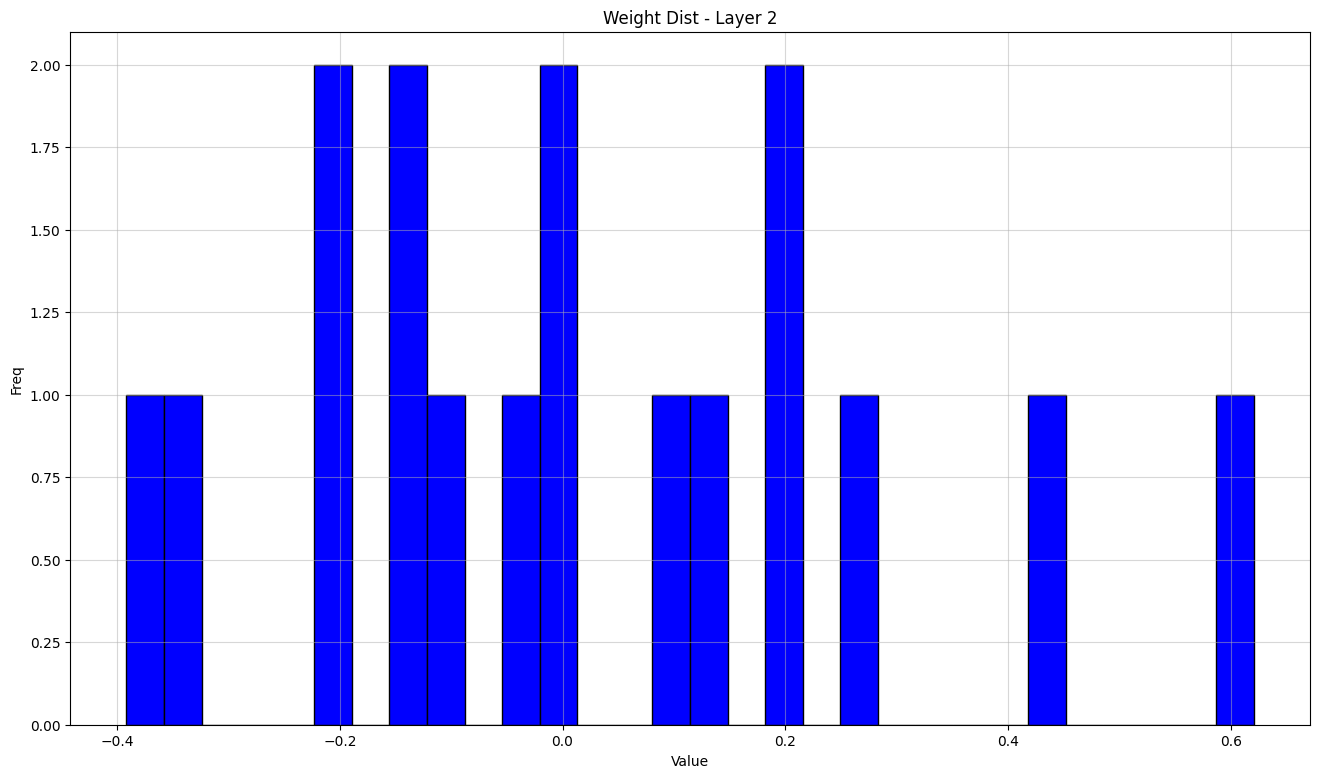

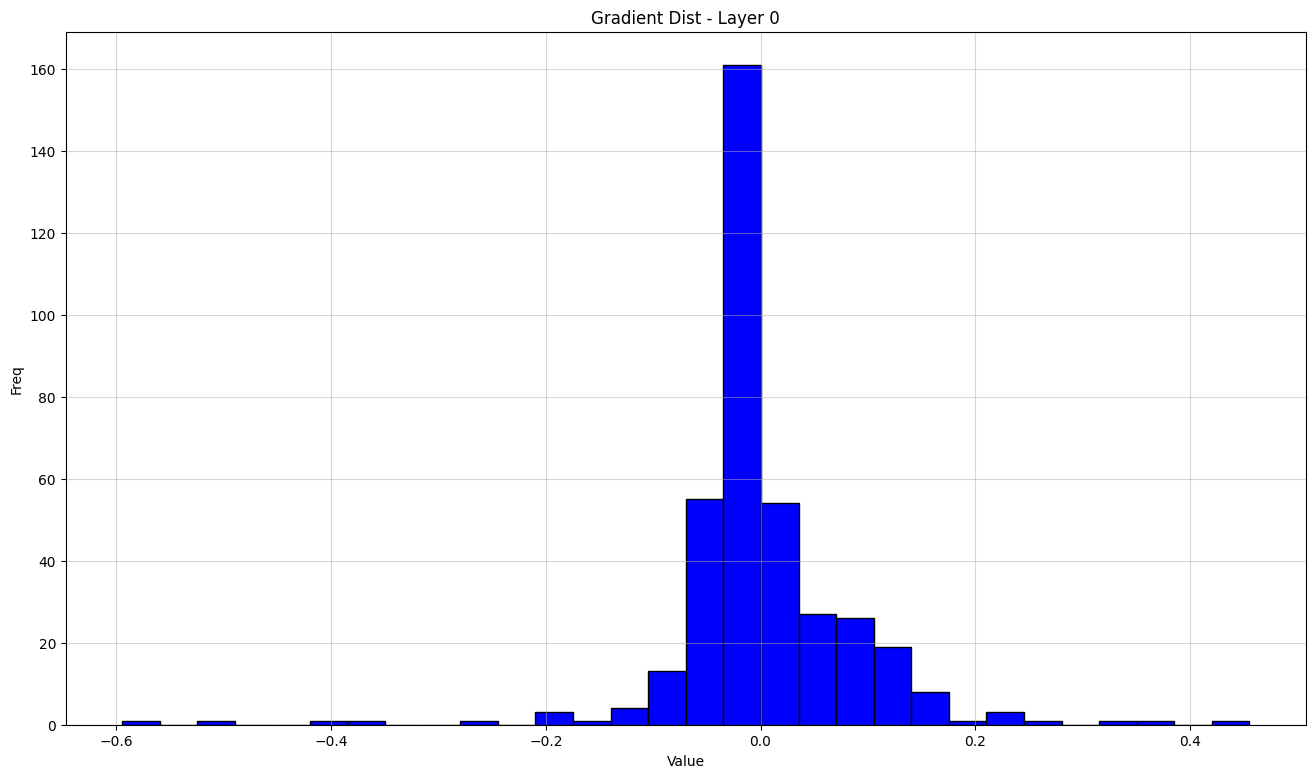

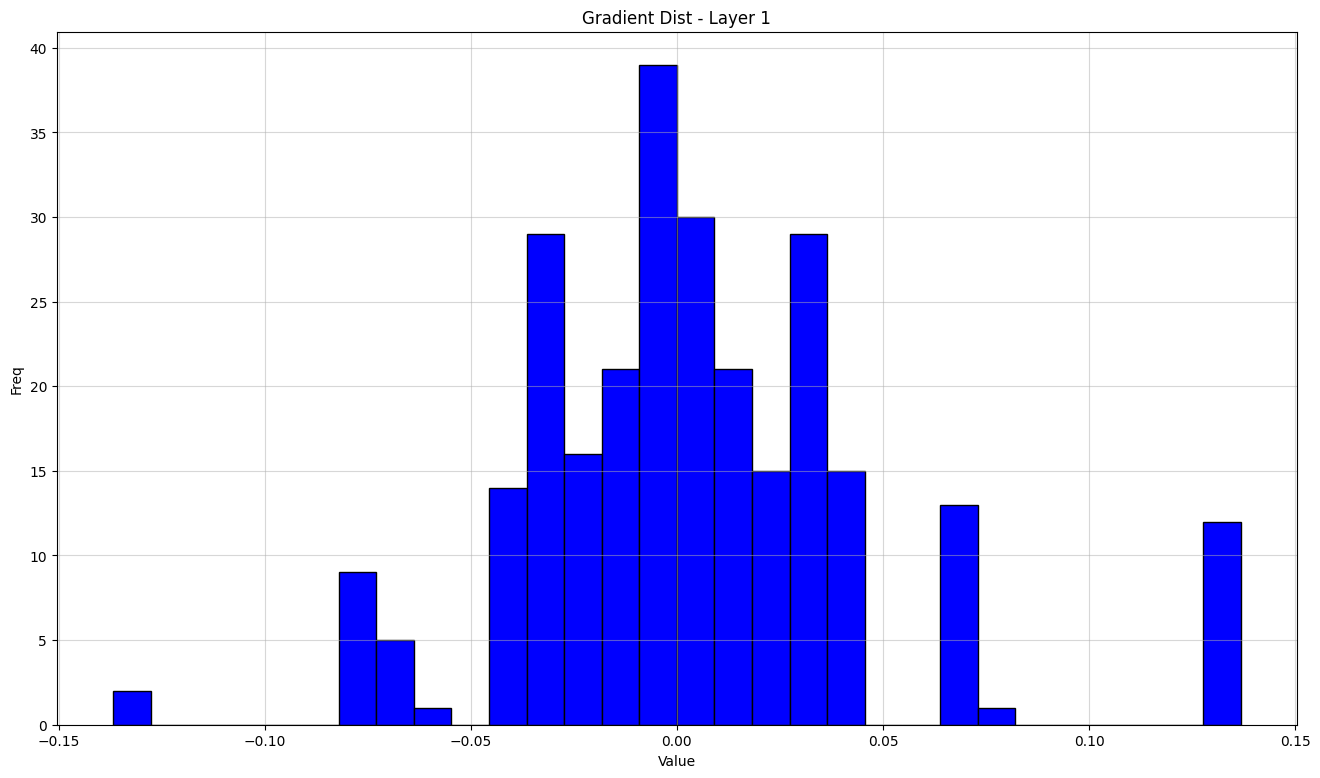

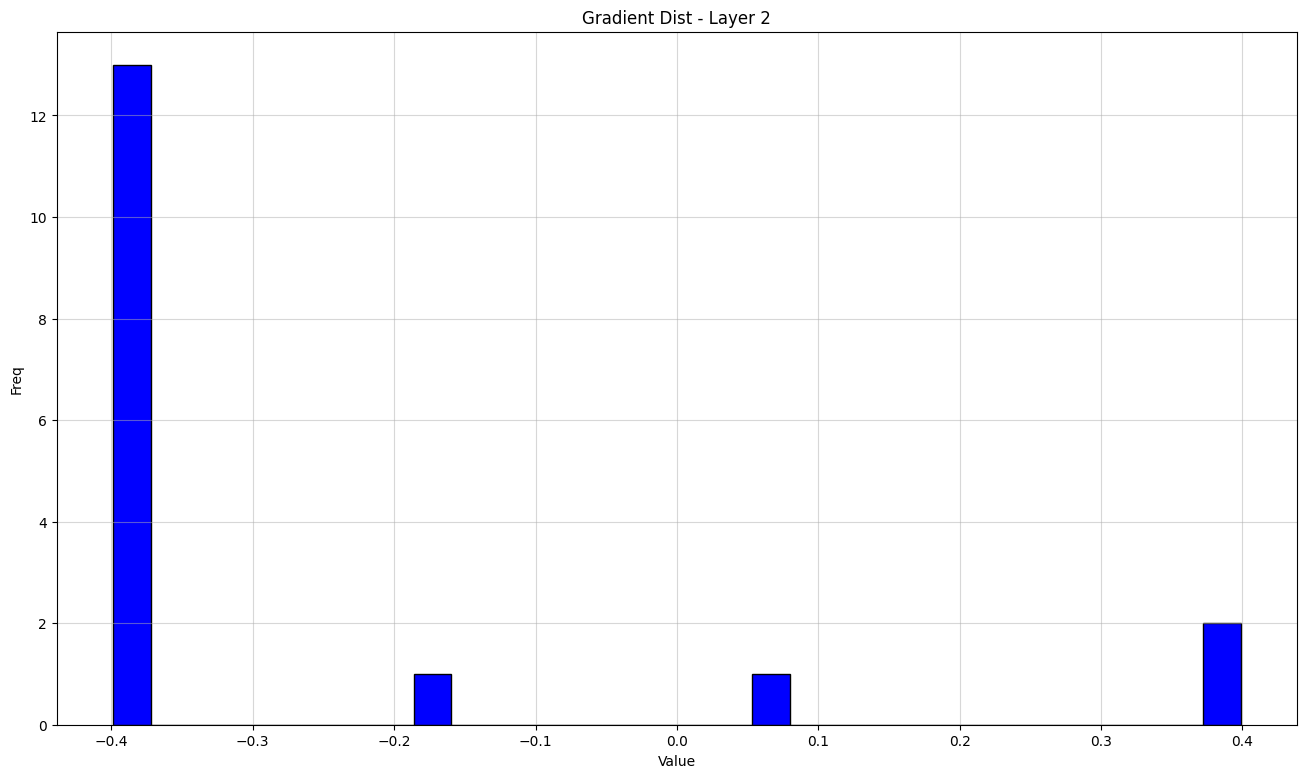

Training: 100%|██████████| 30/30 [00:14<00:00,  2.13it/s, loss=42562.976562]

  [LR] lr=0.01
                precision    recall  f1-score   support

not placed (0)       0.66      0.63      0.65       775
    placed (1)       0.77      0.80      0.78      1225

      accuracy                           0.73      2000
     macro avg       0.72      0.71      0.72      2000
  weighted avg       0.73      0.73      0.73      2000

>>> Macro F1-Score: 0.7158



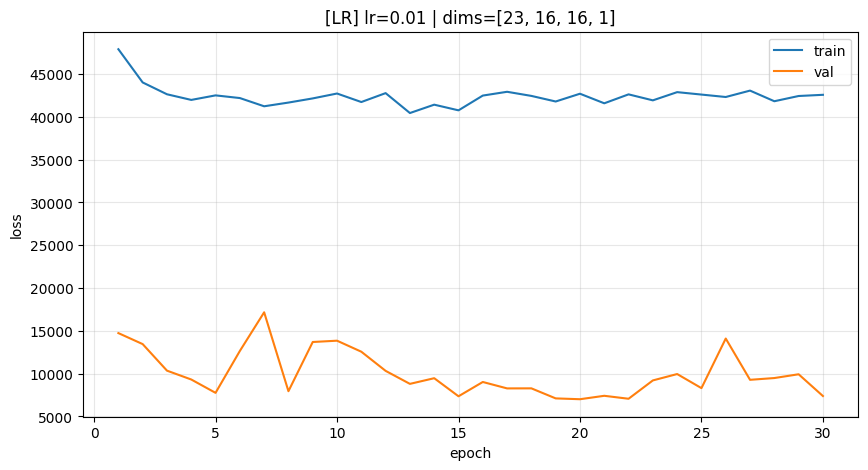

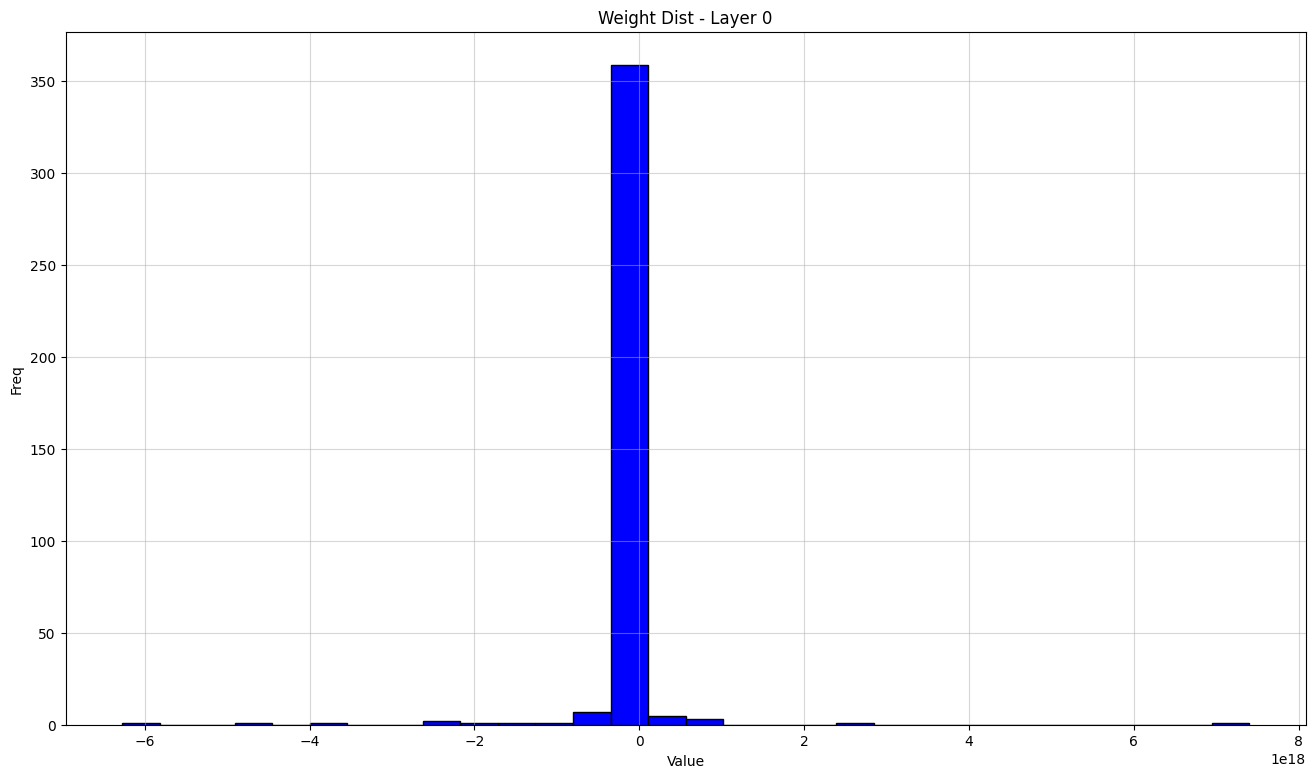

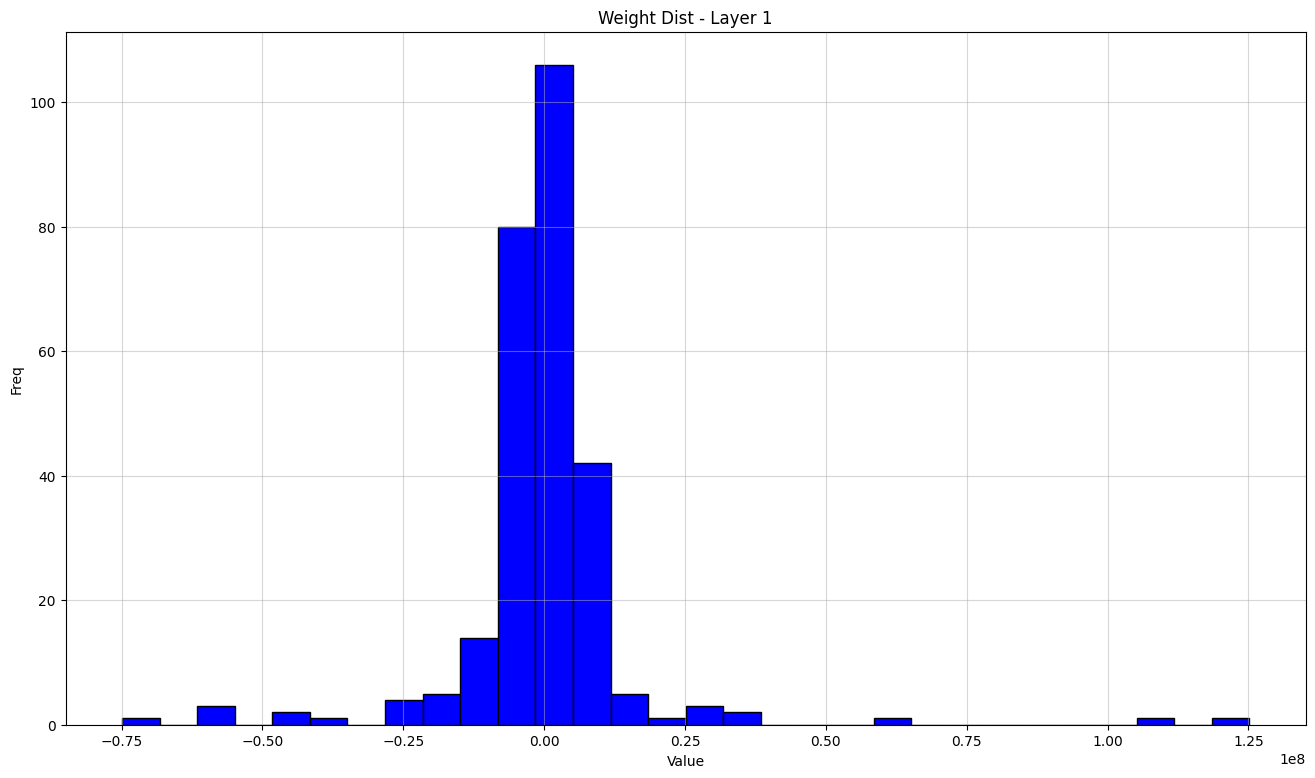

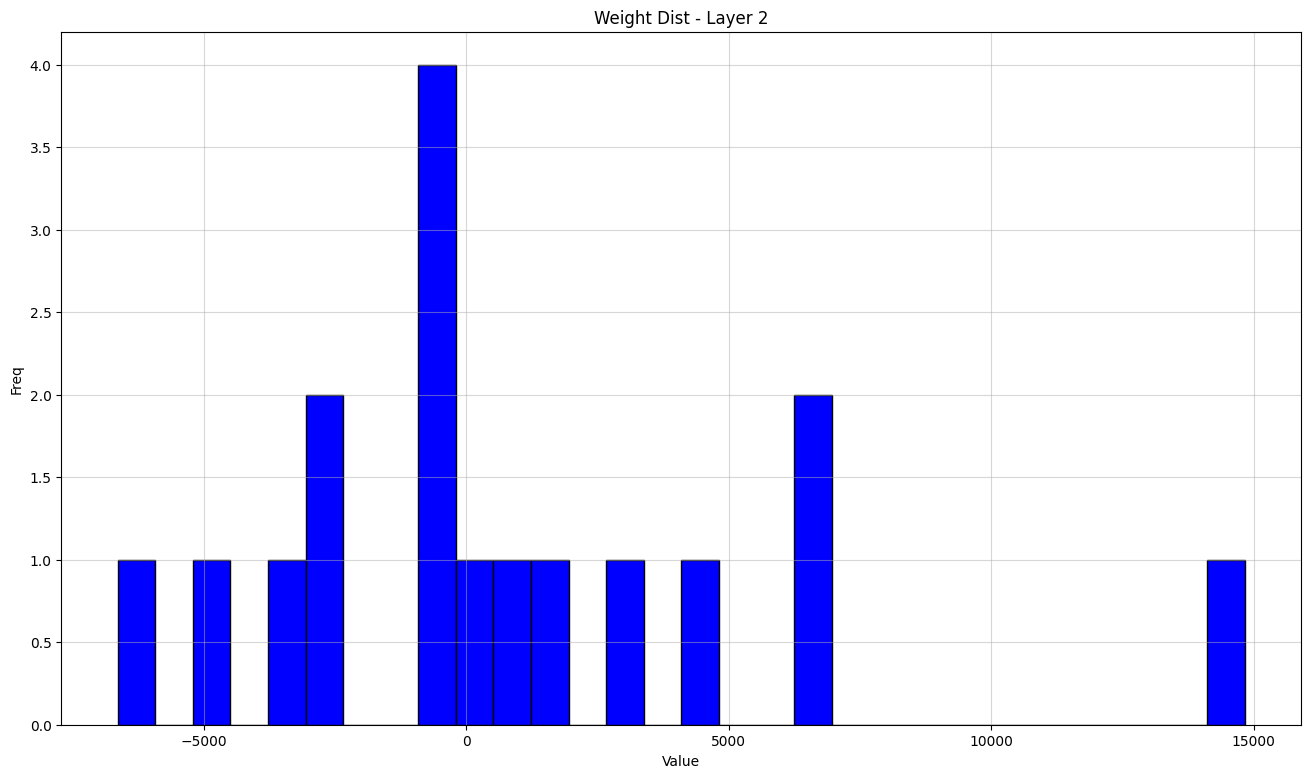

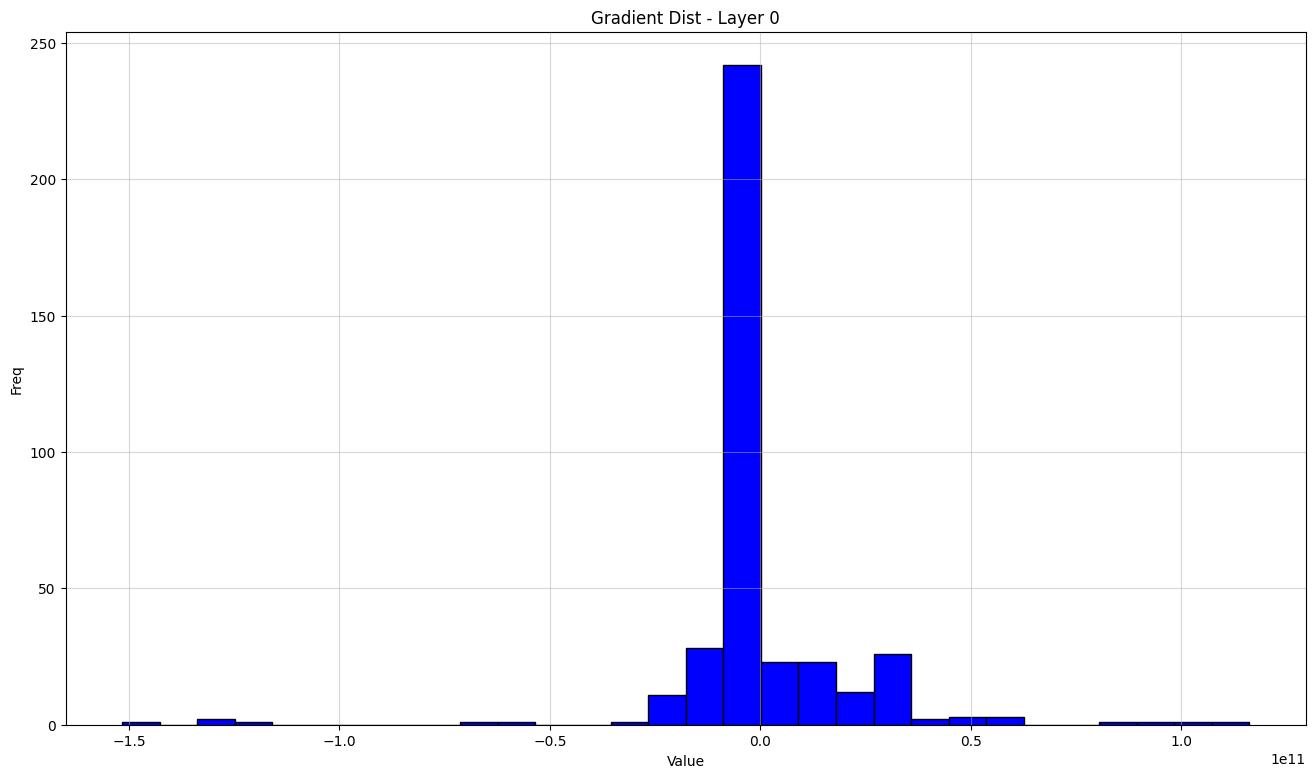

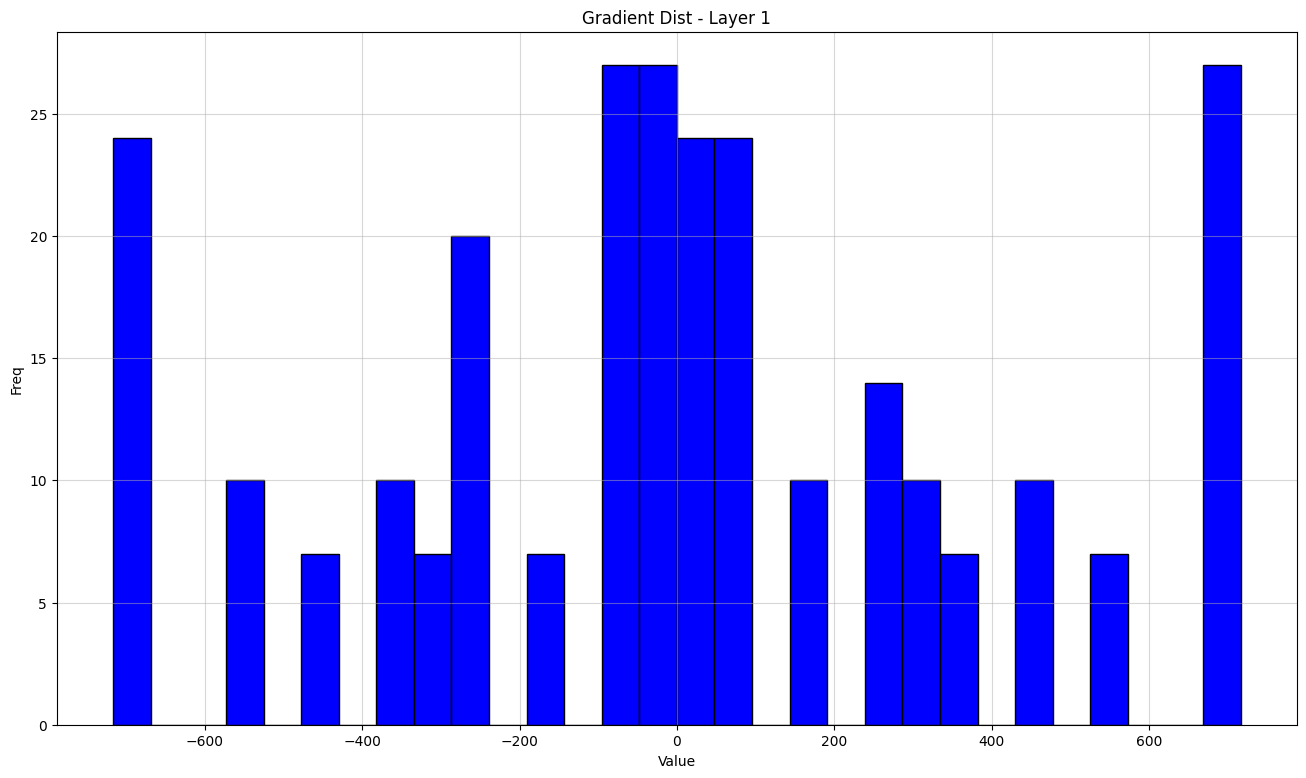

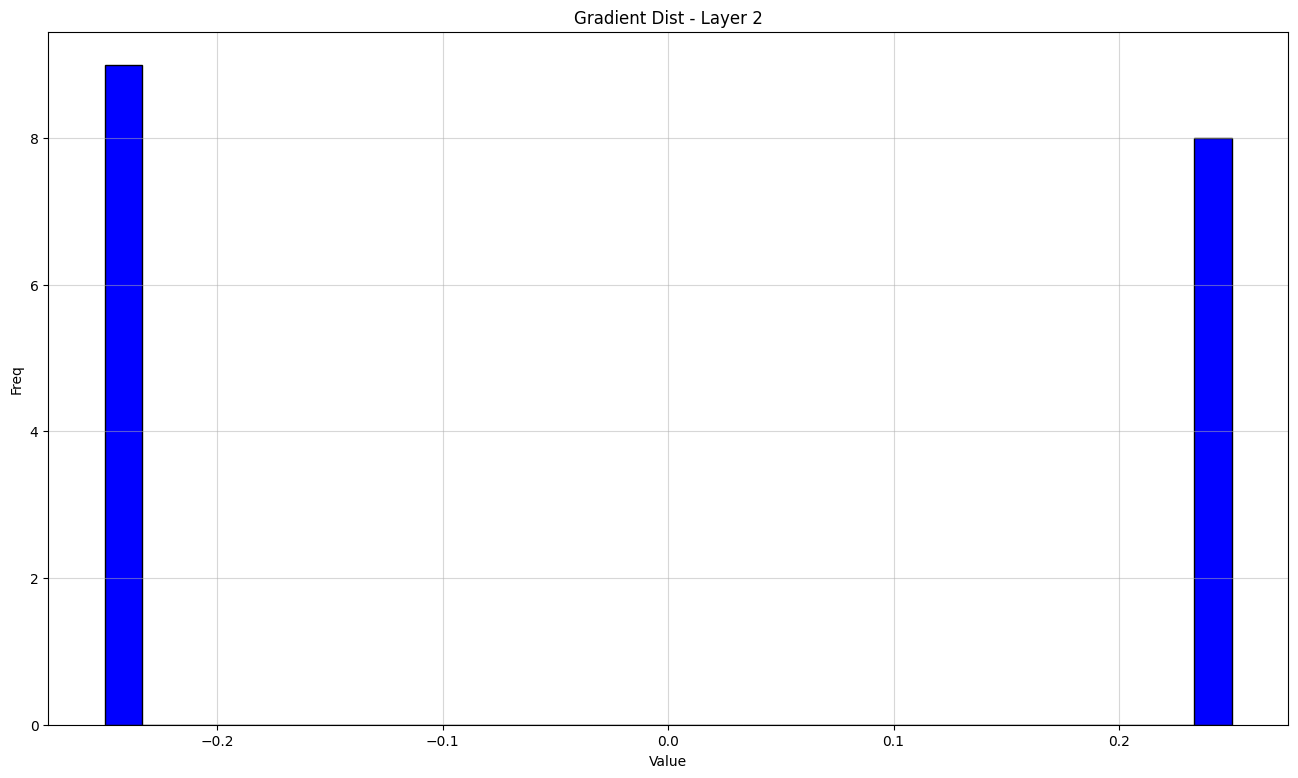

Training: 100%|██████████| 30/30 [00:14<00:00,  2.08it/s, loss=43606.414062]

  [LR] lr=0.1
                precision    recall  f1-score   support

not placed (0)       0.46      0.39      0.42       775
    placed (1)       0.65      0.71      0.68      1225

      accuracy                           0.59      2000
     macro avg       0.55      0.55      0.55      2000
  weighted avg       0.58      0.59      0.58      2000

>>> Macro F1-Score: 0.5498



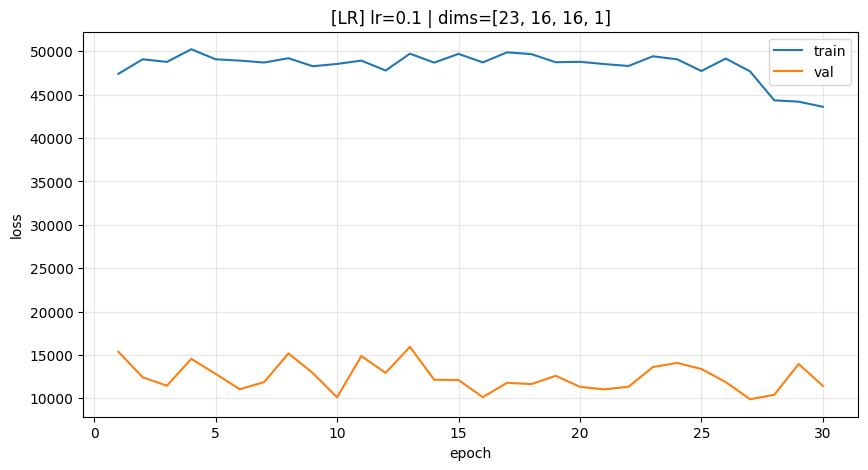

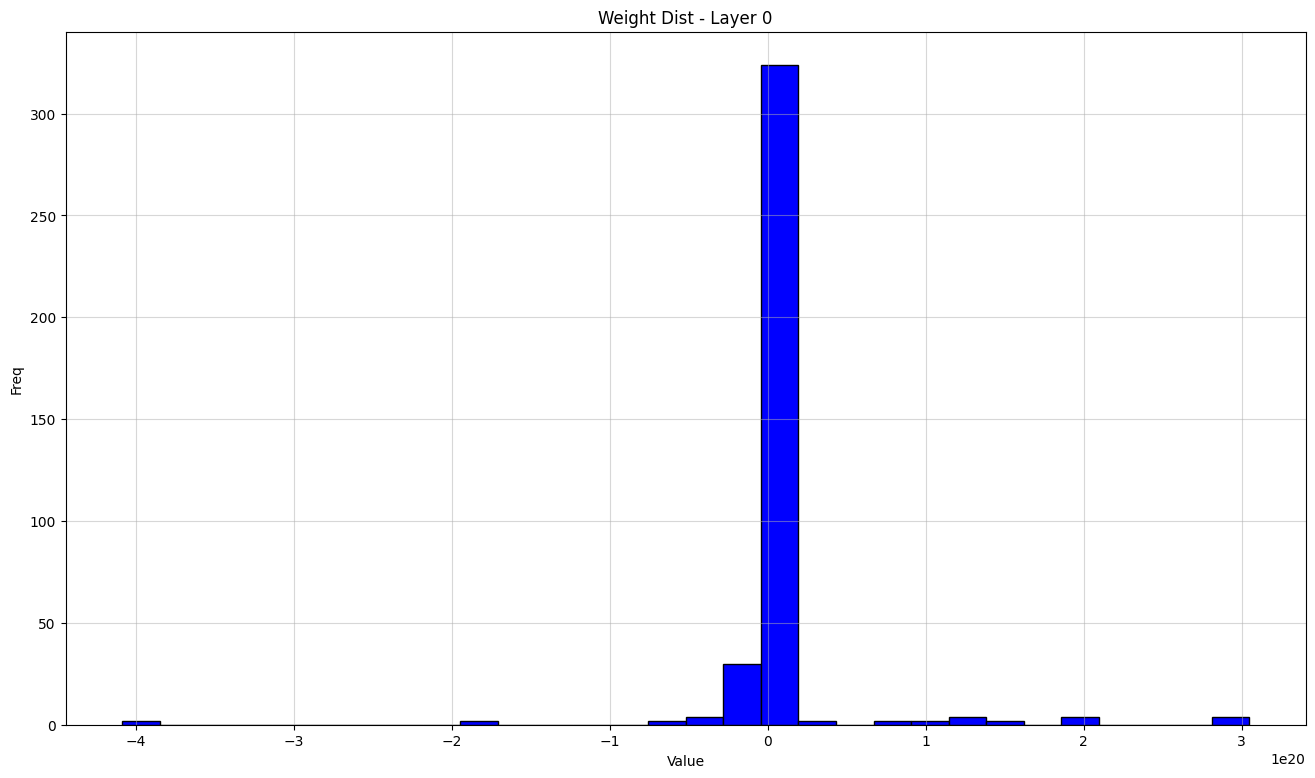

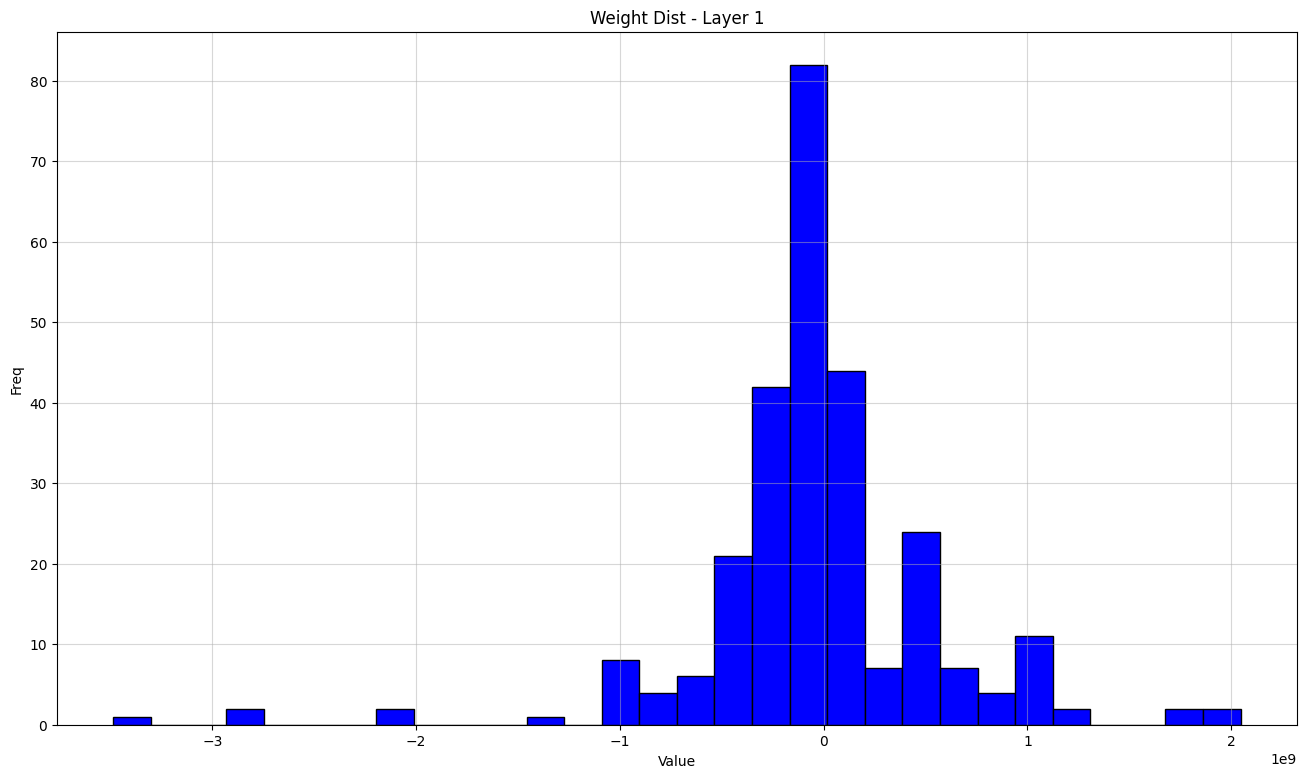

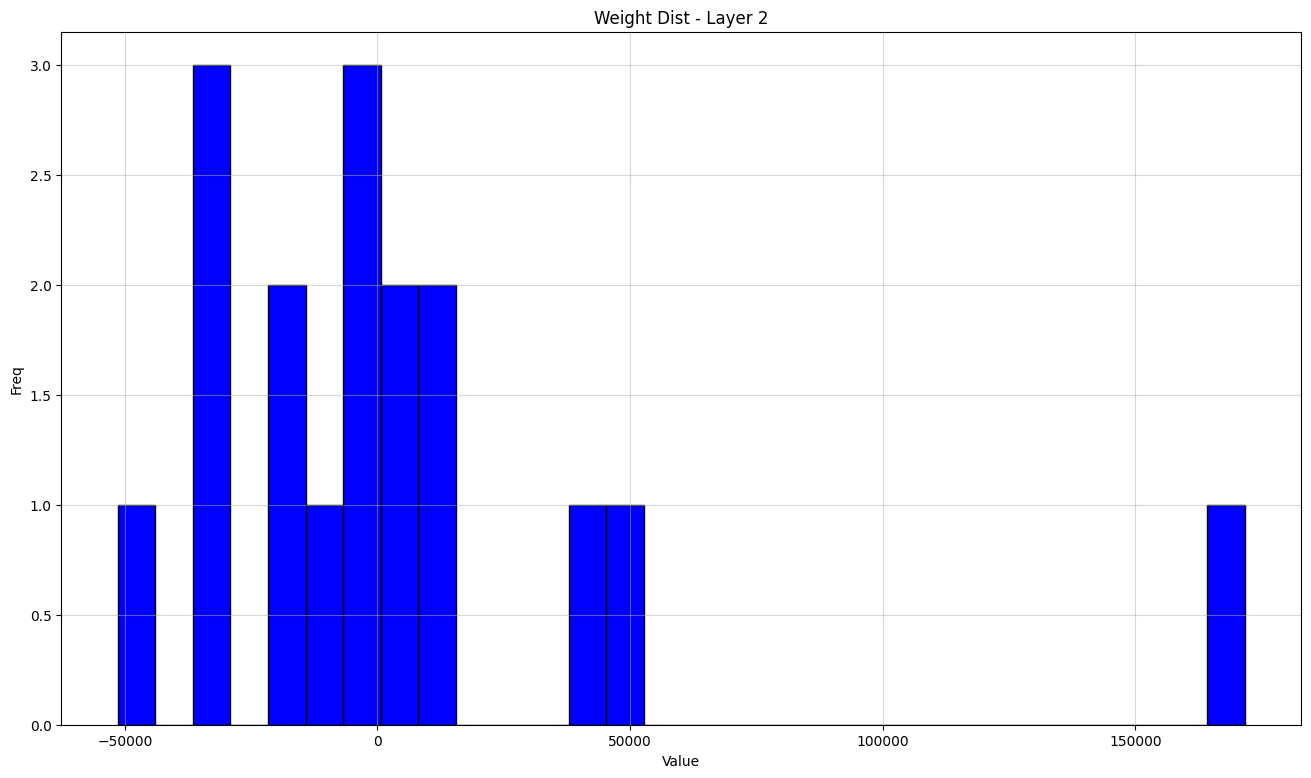

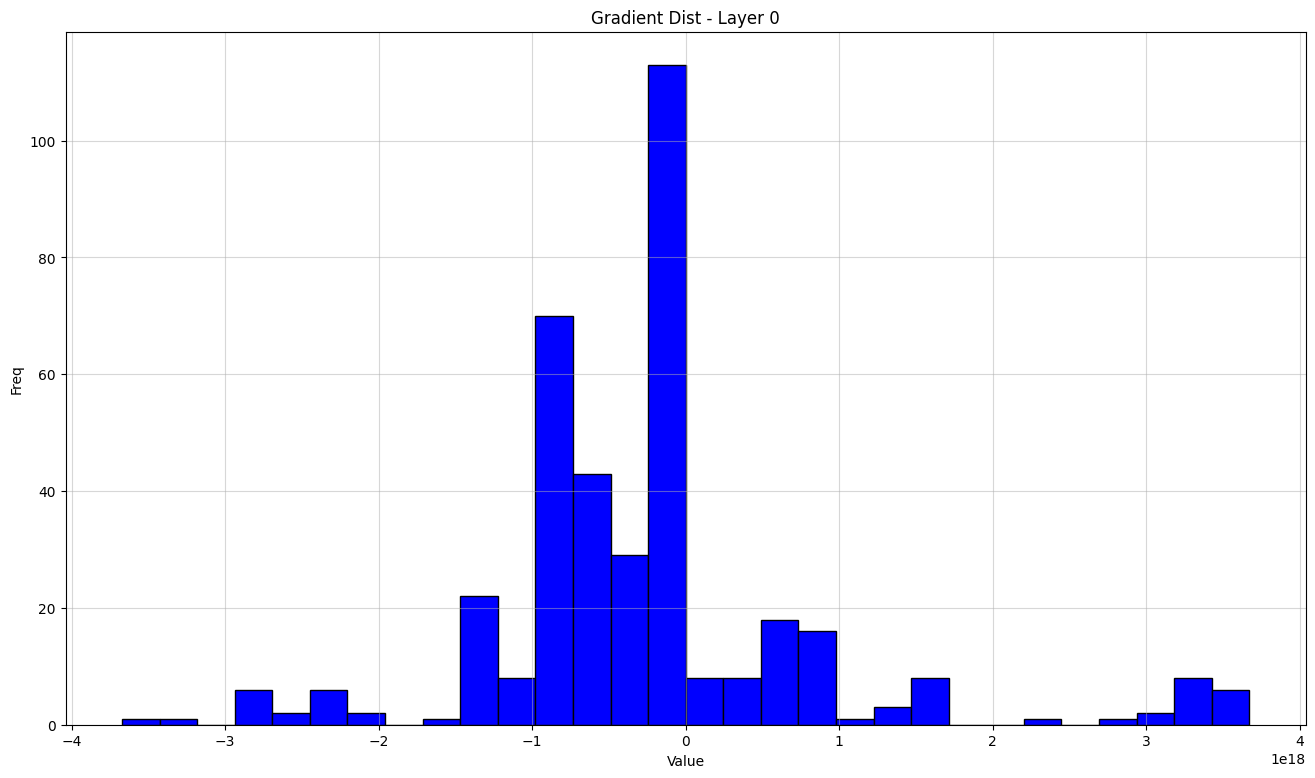

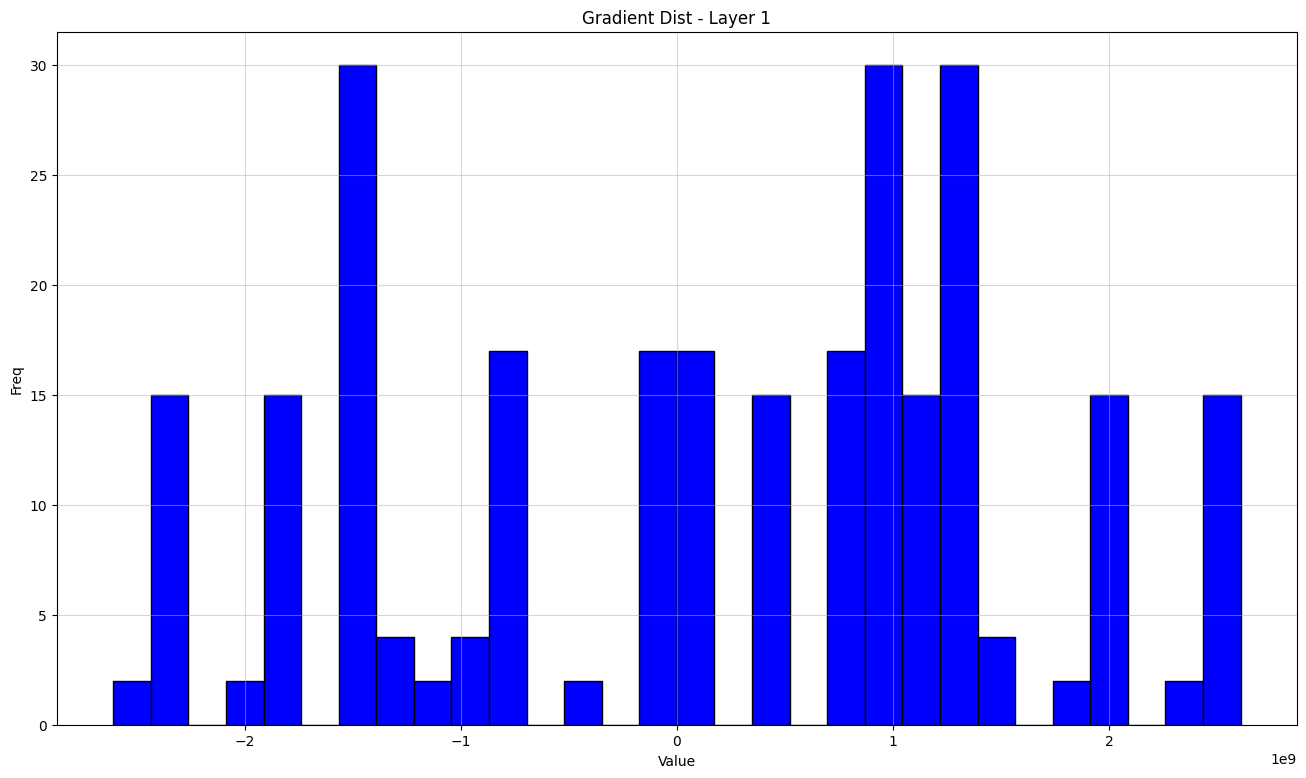

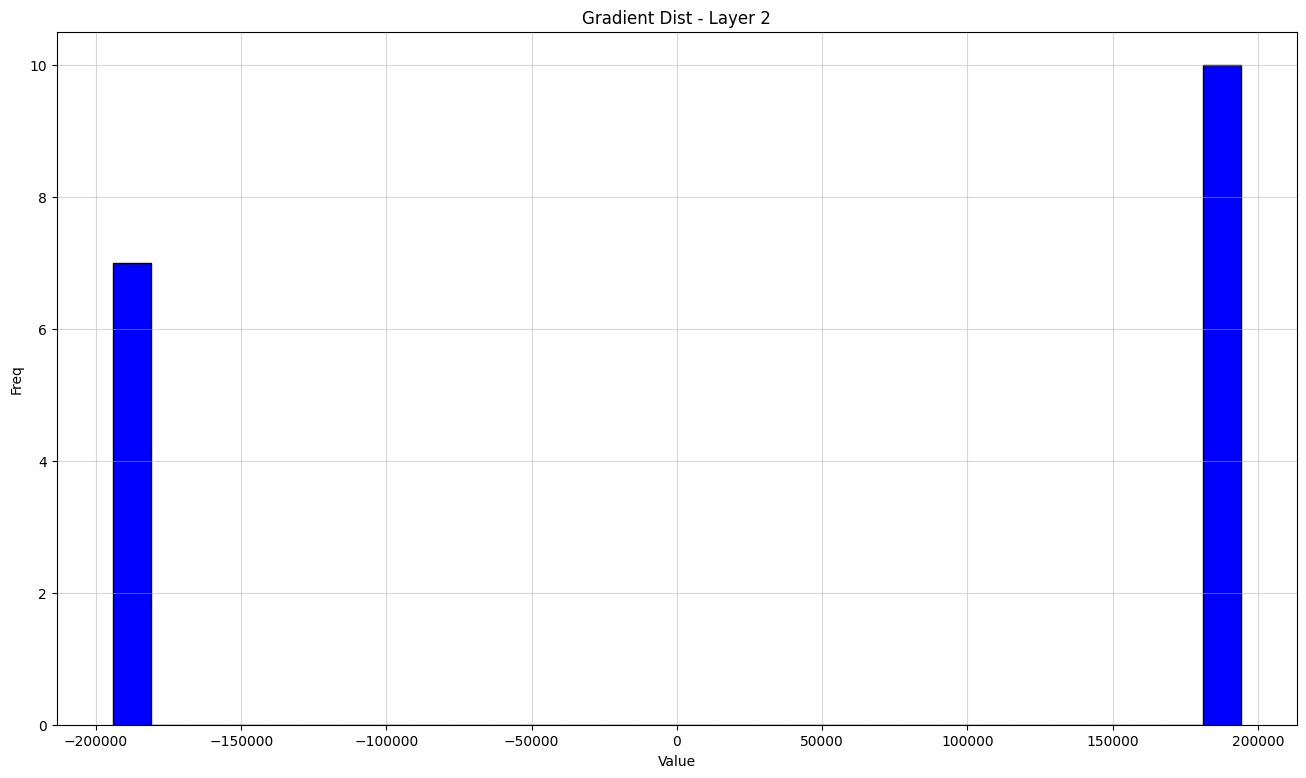

Summary lr: [{'lr': 0.001, 'macro_f1': 0.7344953907539901}, {'lr': 0.01, 'macro_f1': 0.7157864679828143}, {'lr': 0.1, 'macro_f1': 0.5498044480082658}]


In [41]:
epochs = 30
lrs = [0.001, 0.01, 0.1]
input_dim = int(X_train.shape[1])
dims = [input_dim, 16, 16, 1]

res_lr = []

for lr in lrs:
    model = FFNN(dims, [Tanh, Tanh, Sigmoid], BCE, lr)
    model.train(X_train, y_train, epochs, True, None, X_val, y_val)
    loss_train = model.training_loss
    loss_val = model.validation_loss
    f1 = evaluate_model(model, X_val, y_val, model_name=f"[LR] lr={lr}")
    plot_loss(loss_train, loss_val, title=f"[LR] lr={lr} | dims={dims}")

    model.plot_w([0, 1, 2])
    model.plot_g([0, 1, 2])
    res_lr.append({"lr": lr, "macro_f1": f1})

print("Summary lr:", res_lr)


In [ ]:
epochs = 30
inits = ['zero', 'random_uniform', 'random_normal', 'xavier', 'he']
input_dim = int(X_train.shape[1])
dims = [input_dim, 16, 16, 1]

res_init = []

for init in inits:
    model = FFNN(dims, [Tanh, Tanh, Sigmoid], BCE, 0.001, weight_initialization=init)
    model.train(X_train, y_train, epochs, True, None, X_val, y_val)
    loss_train = model.training_loss
    loss_val = model.validation_loss
    f1 = evaluate_model(model, X_val, y_val, model_name=f"[LR] lr={0.001}")
    plot_loss(loss_train, loss_val, title=f"[LR] lr={lr} | dims={dims}")

    model.plot_w([0, 1, 2])
    model.plot_g([0, 1, 2])
    res_init.append({"lr": lr, "macro_f1": f1})

print("Summary lr:", res_init)


Training:   3%|███▊                                                                                                              | 1/30 [00:01<00:36,  1.25s/it, loss=5386.450195]

Training: 100%|██████████| 30/30 [00:18<00:00,  1.60it/s, loss=42562.976562]

  [REG] none
                precision    recall  f1-score   support

not placed (0)       0.66      0.63      0.65       775
    placed (1)       0.77      0.80      0.78      1225

      accuracy                           0.73      2000
     macro avg       0.72      0.71      0.72      2000
  weighted avg       0.73      0.73      0.73      2000

>>> Macro F1-Score: 0.7158



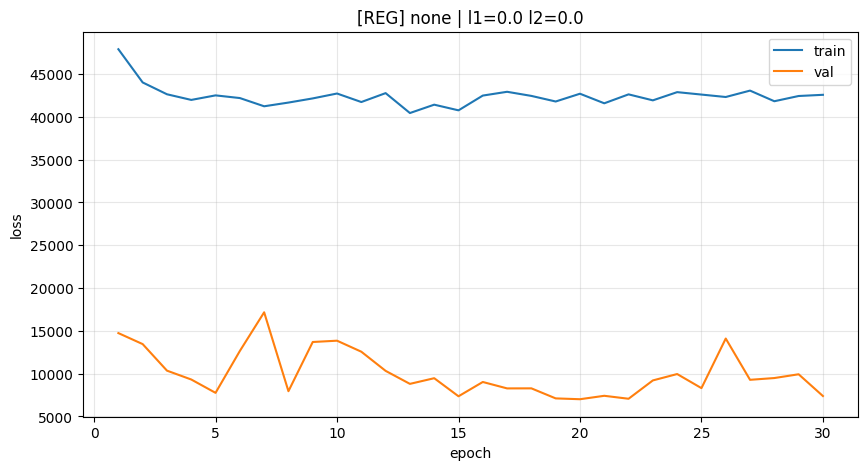

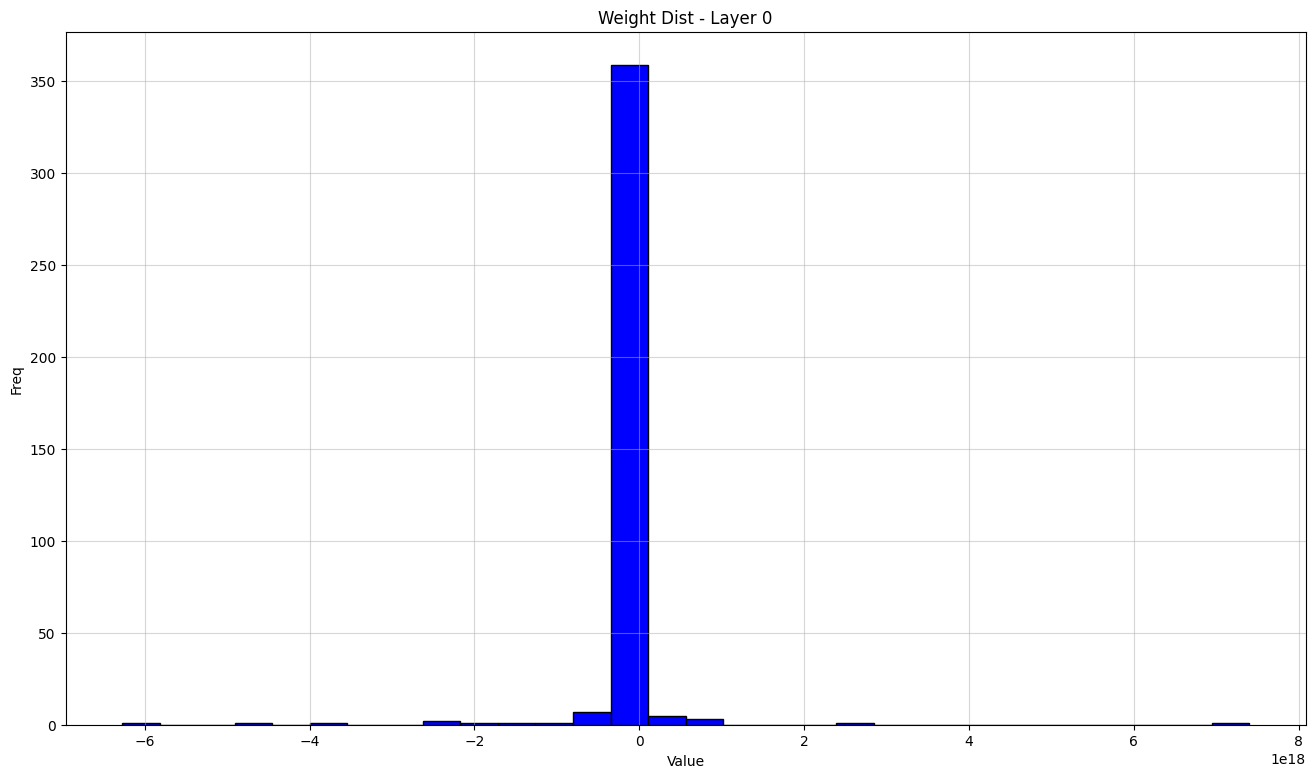

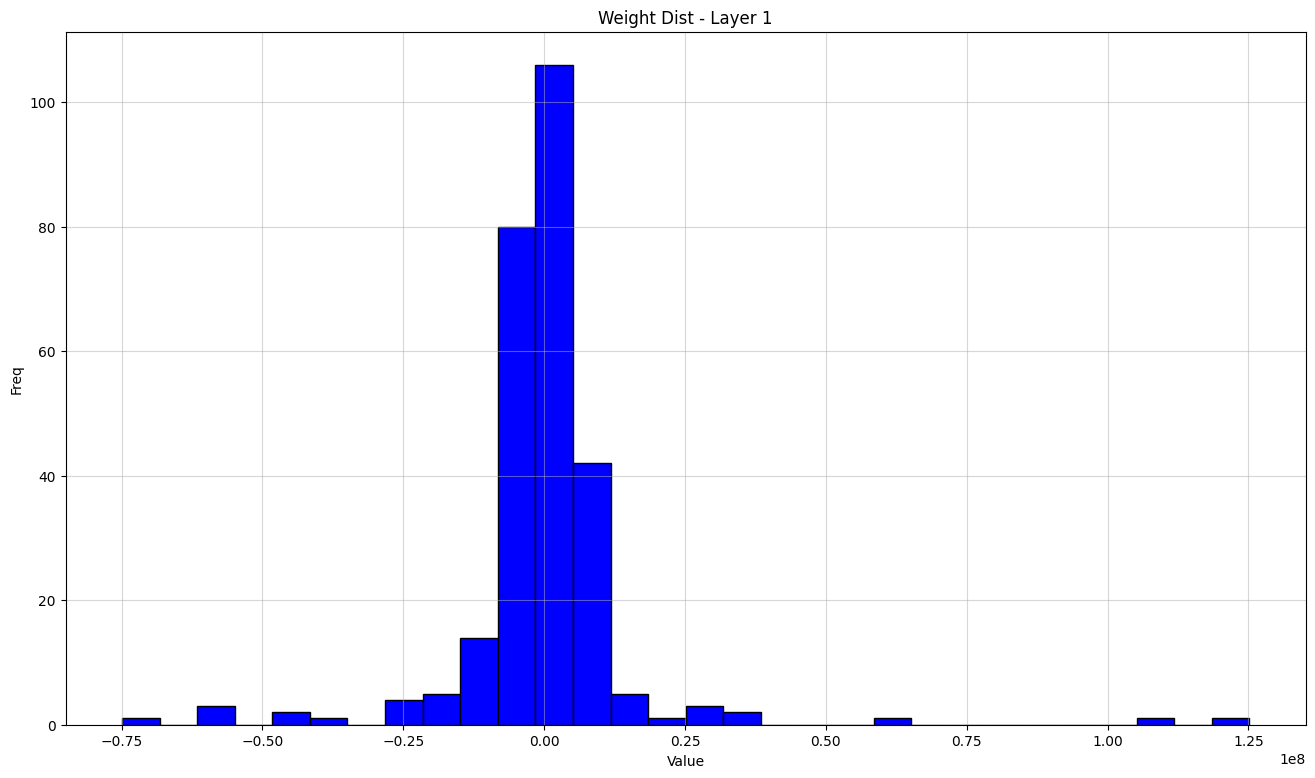

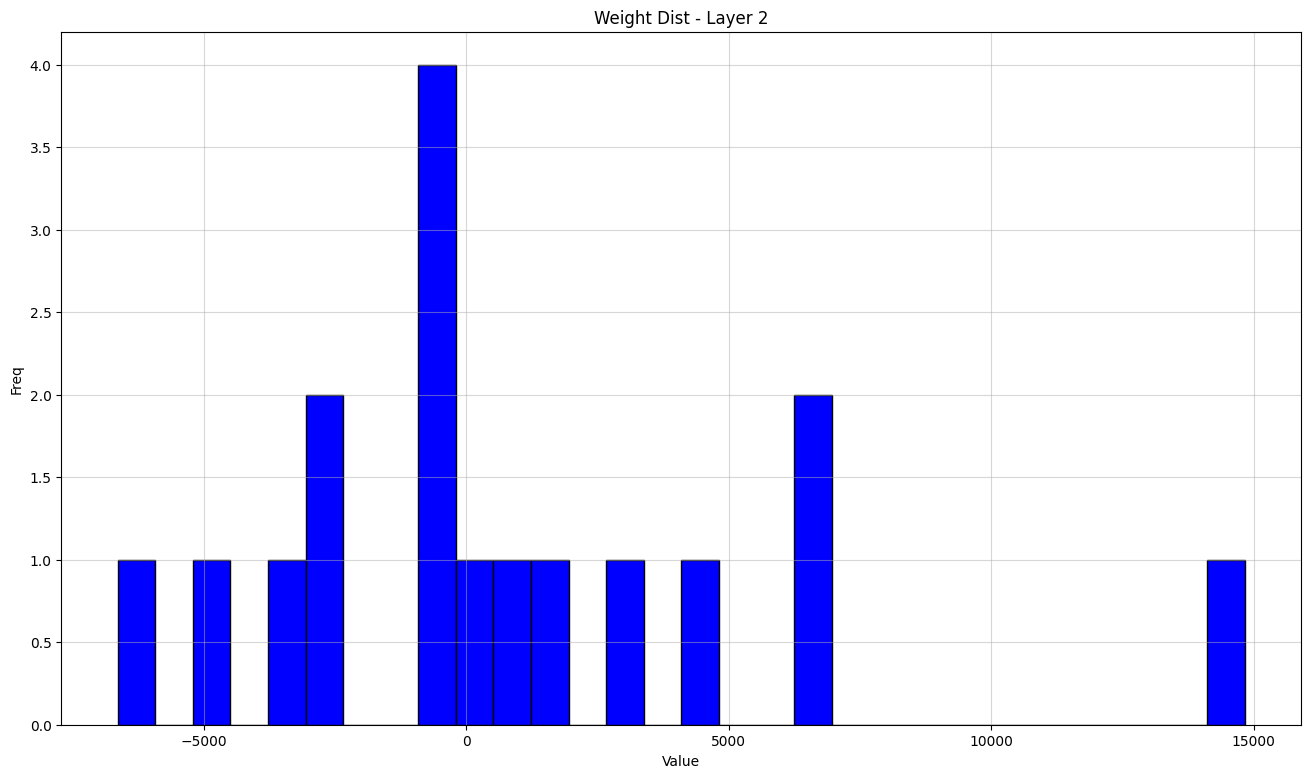

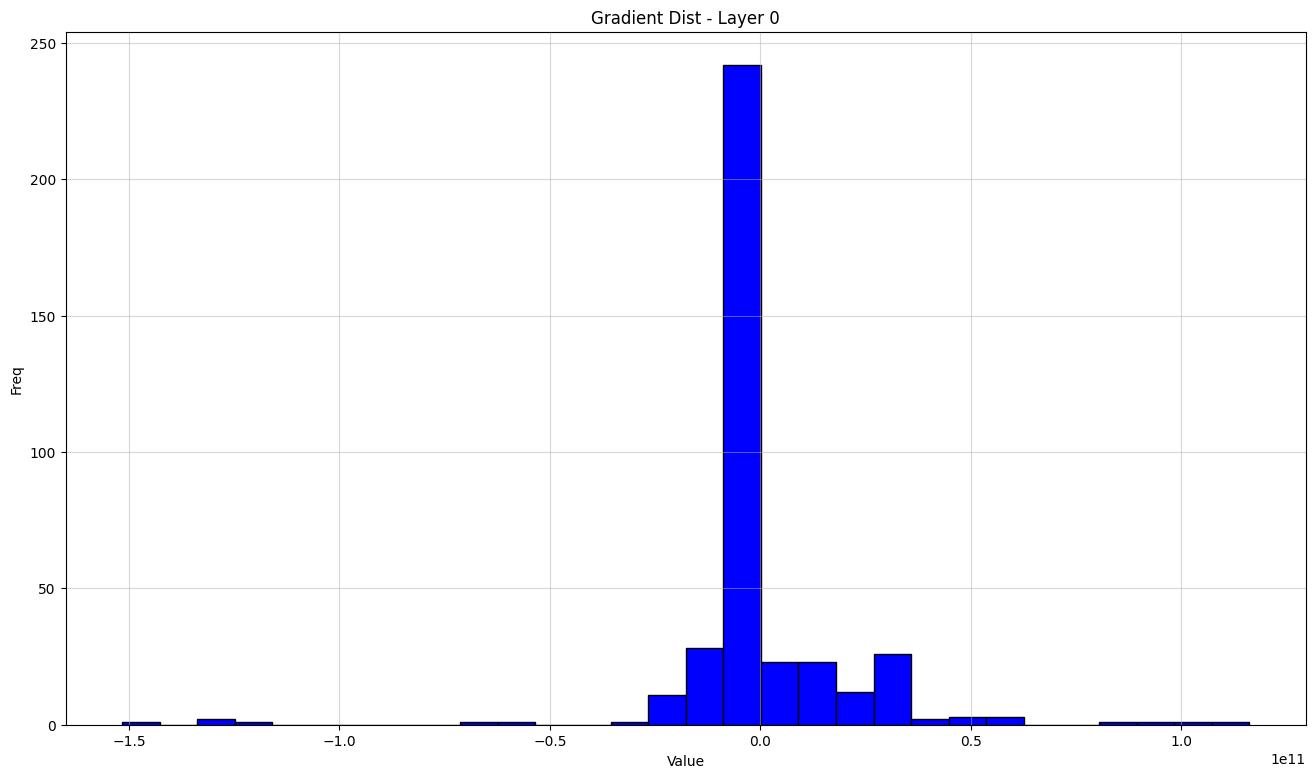

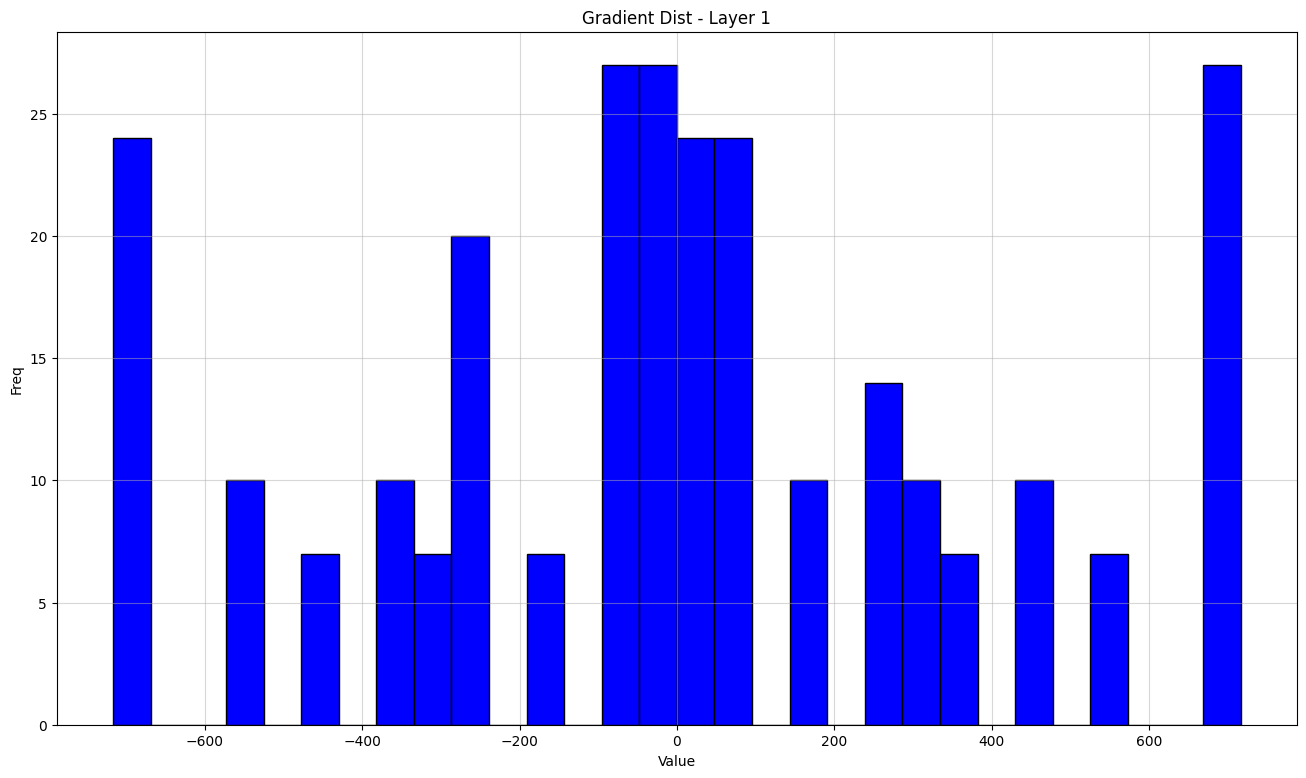

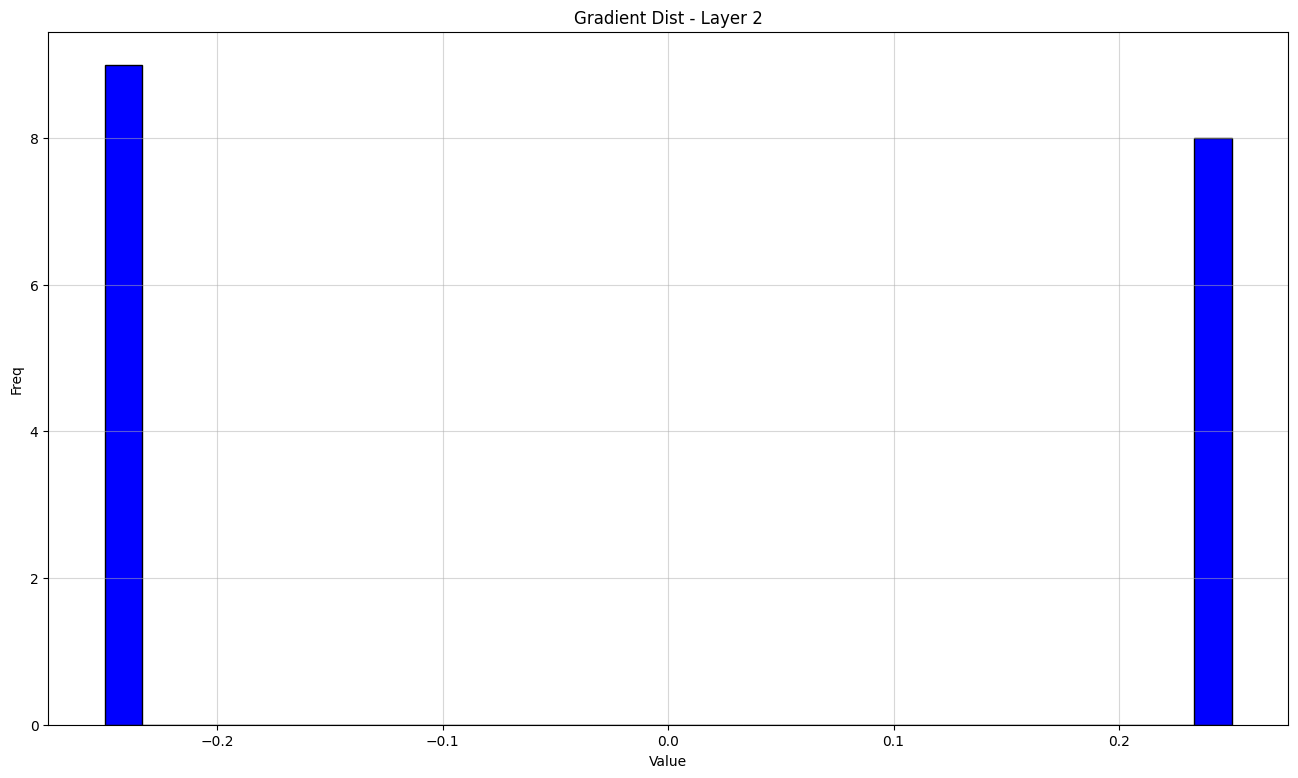

Training: 100%|██████████| 30/30 [00:17<00:00,  1.67it/s, loss=42831.058594]

  [REG] l1
                precision    recall  f1-score   support

not placed (0)       0.62      0.30      0.40       775
    placed (1)       0.67      0.88      0.76      1225

      accuracy                           0.66      2000
     macro avg       0.64      0.59      0.58      2000
  weighted avg       0.65      0.66      0.62      2000

>>> Macro F1-Score: 0.5810



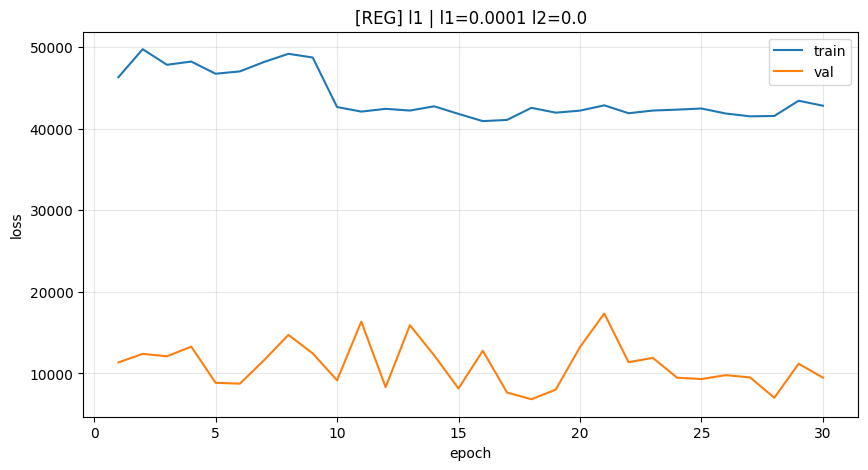

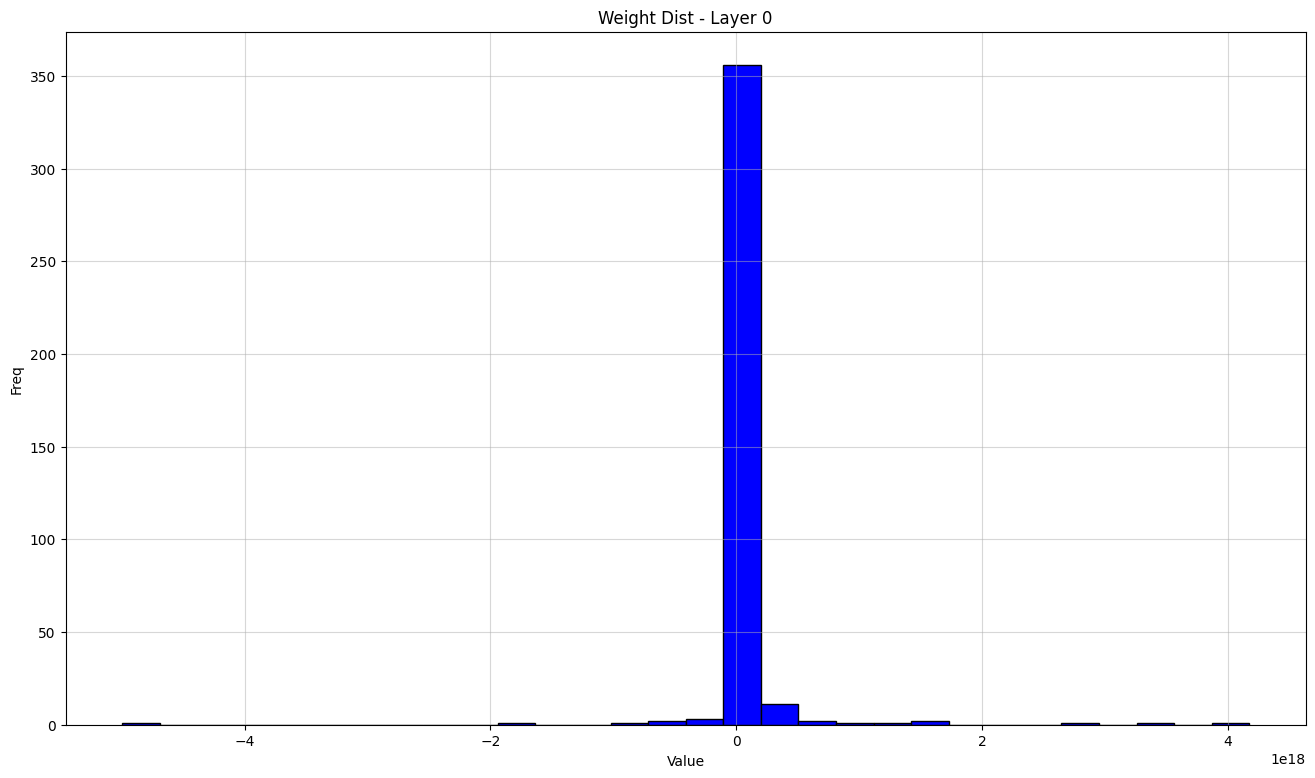

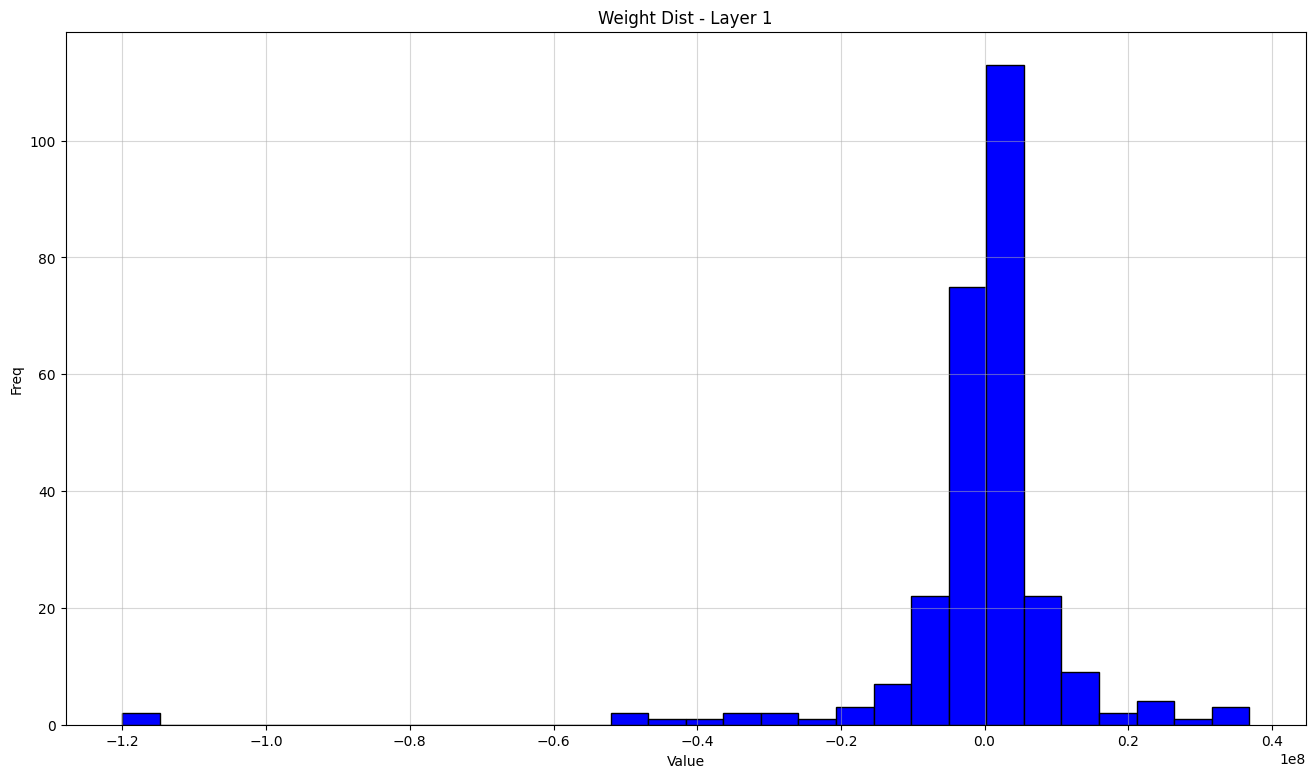

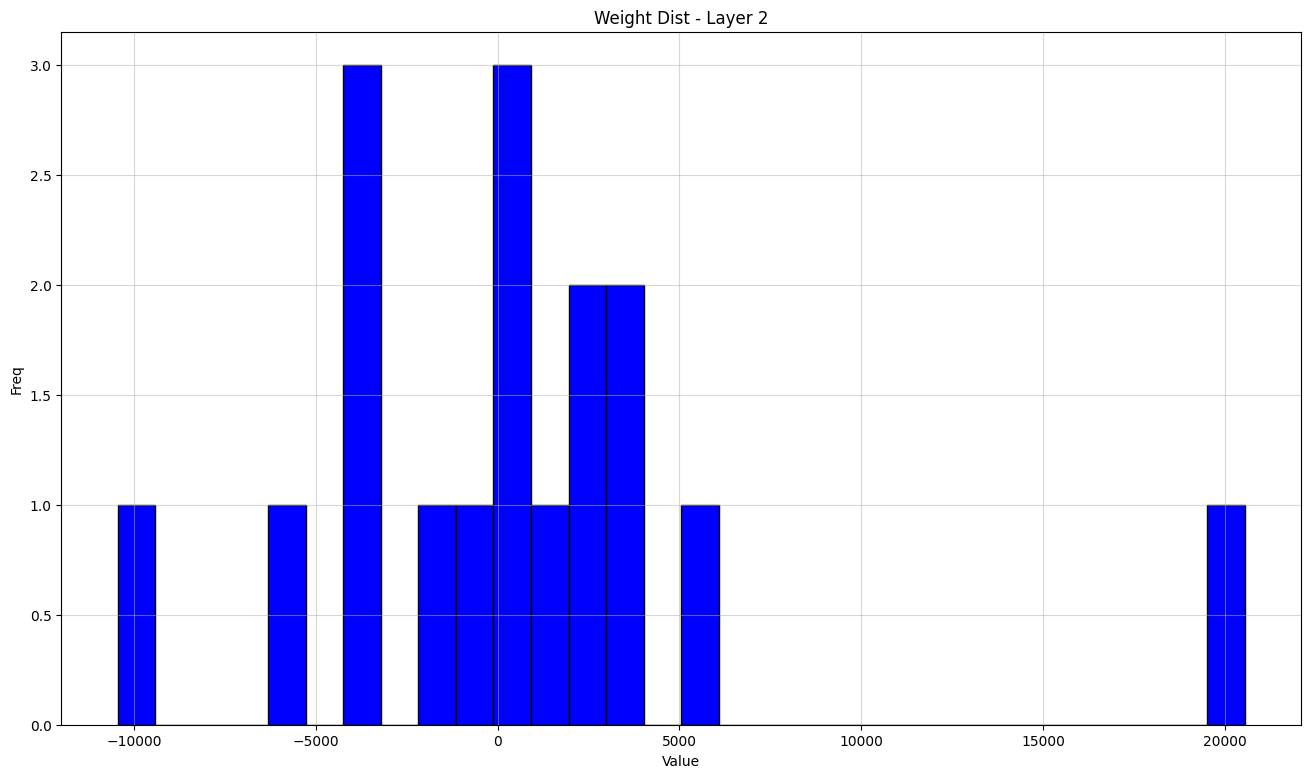

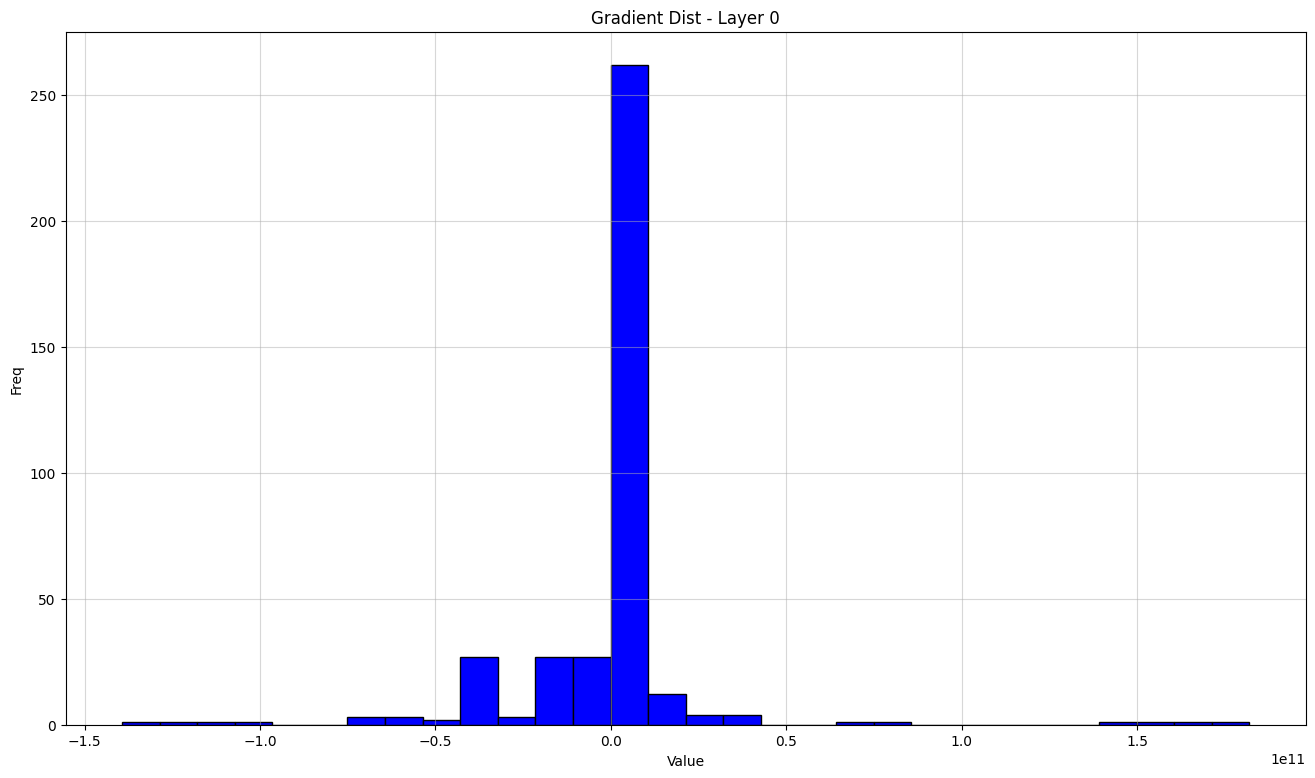

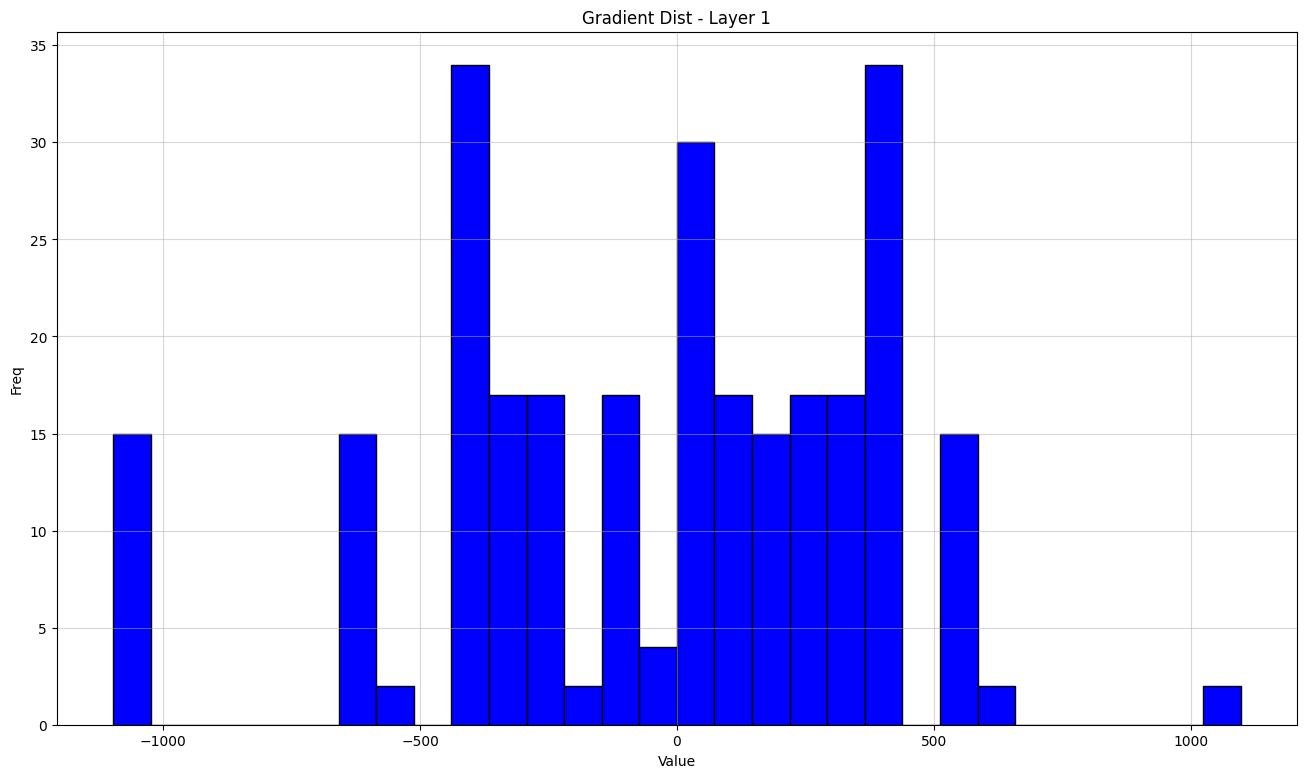

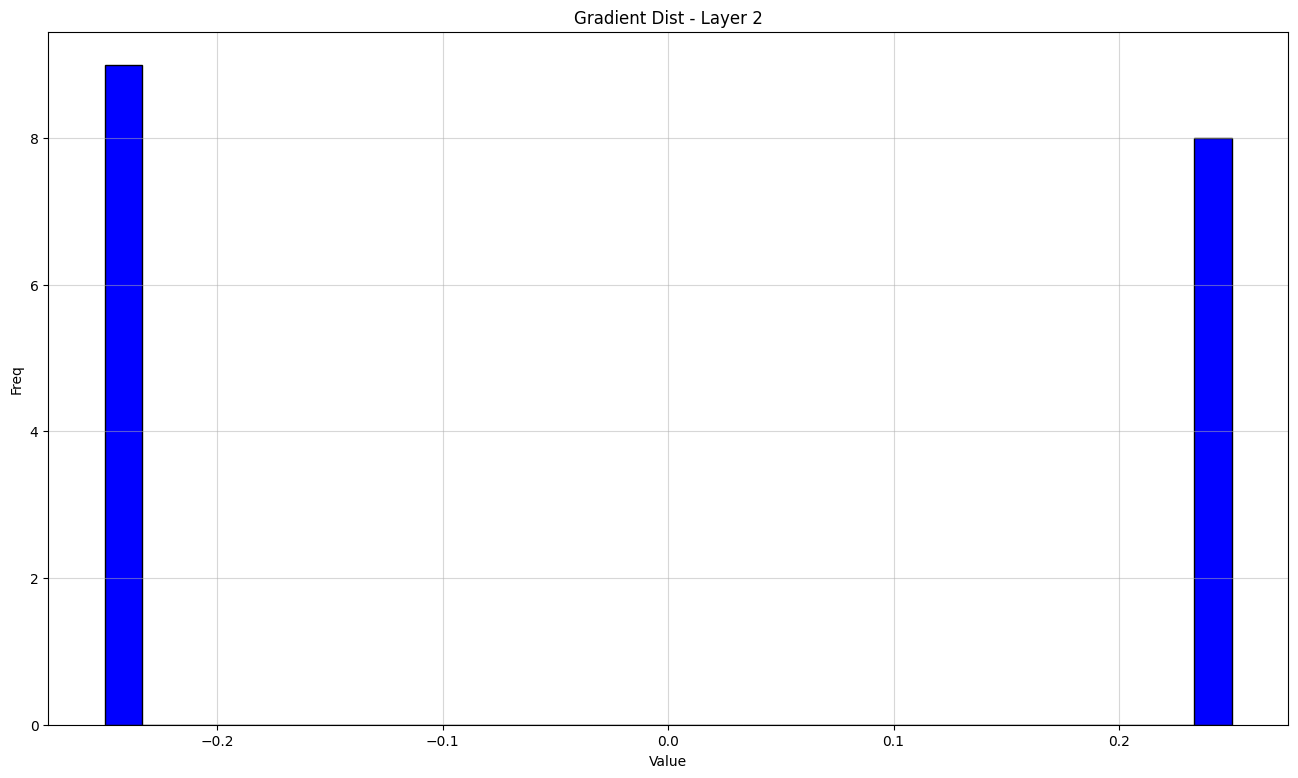

Training: 100%|██████████| 30/30 [00:16<00:00,  1.79it/s, loss=41850.640625]

  [REG] l2
                precision    recall  f1-score   support

not placed (0)       0.65      0.37      0.47       775
    placed (1)       0.69      0.87      0.77      1225

      accuracy                           0.68      2000
     macro avg       0.67      0.62      0.62      2000
  weighted avg       0.67      0.68      0.65      2000

>>> Macro F1-Score: 0.6199



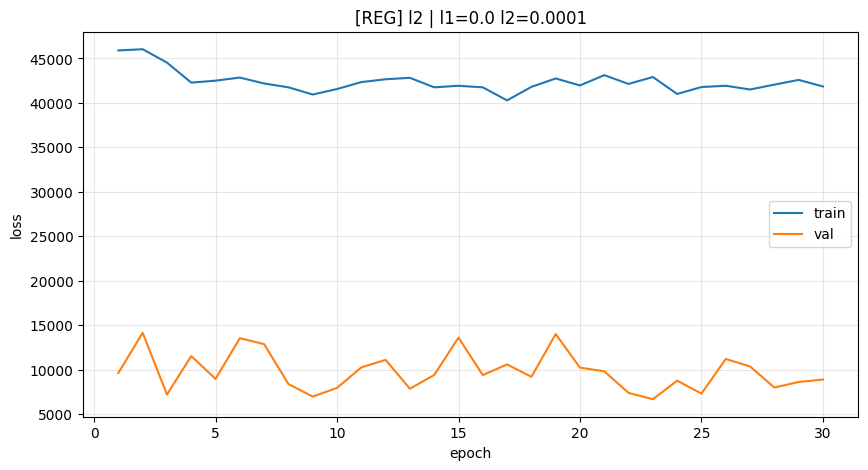

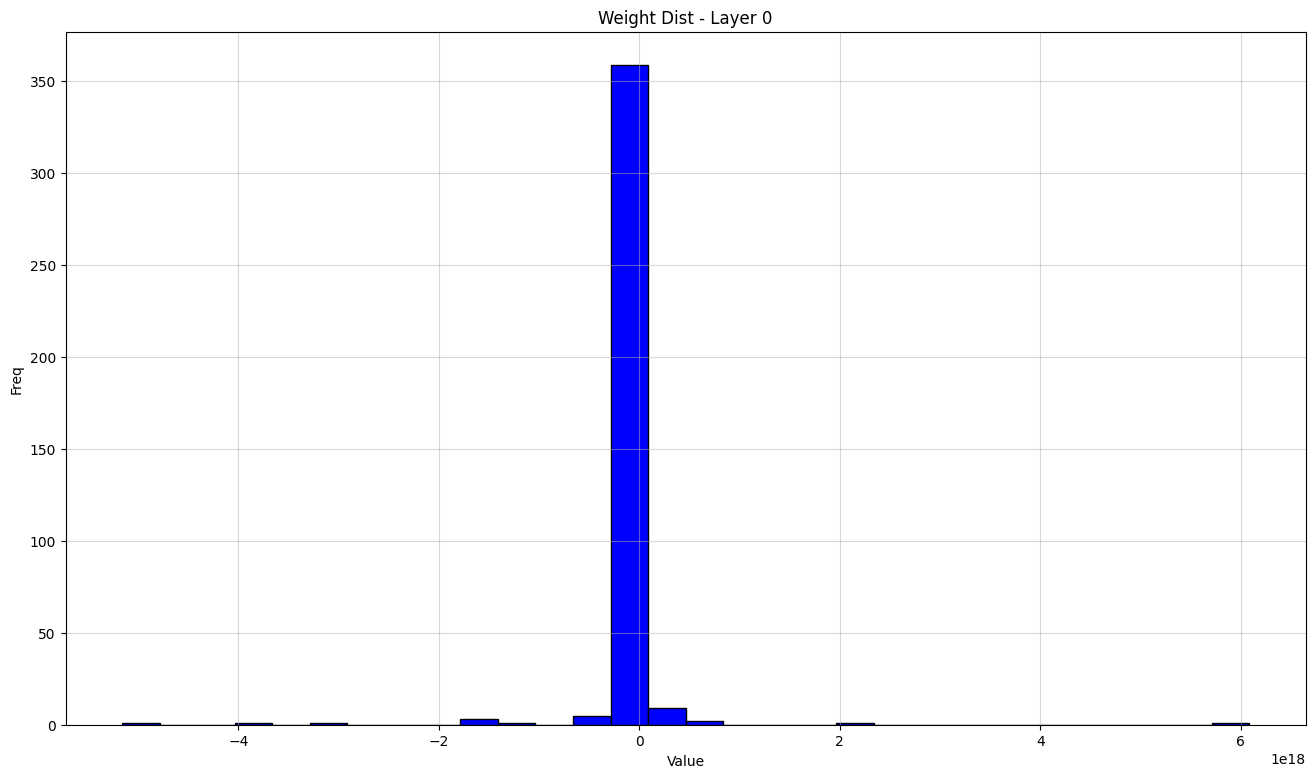

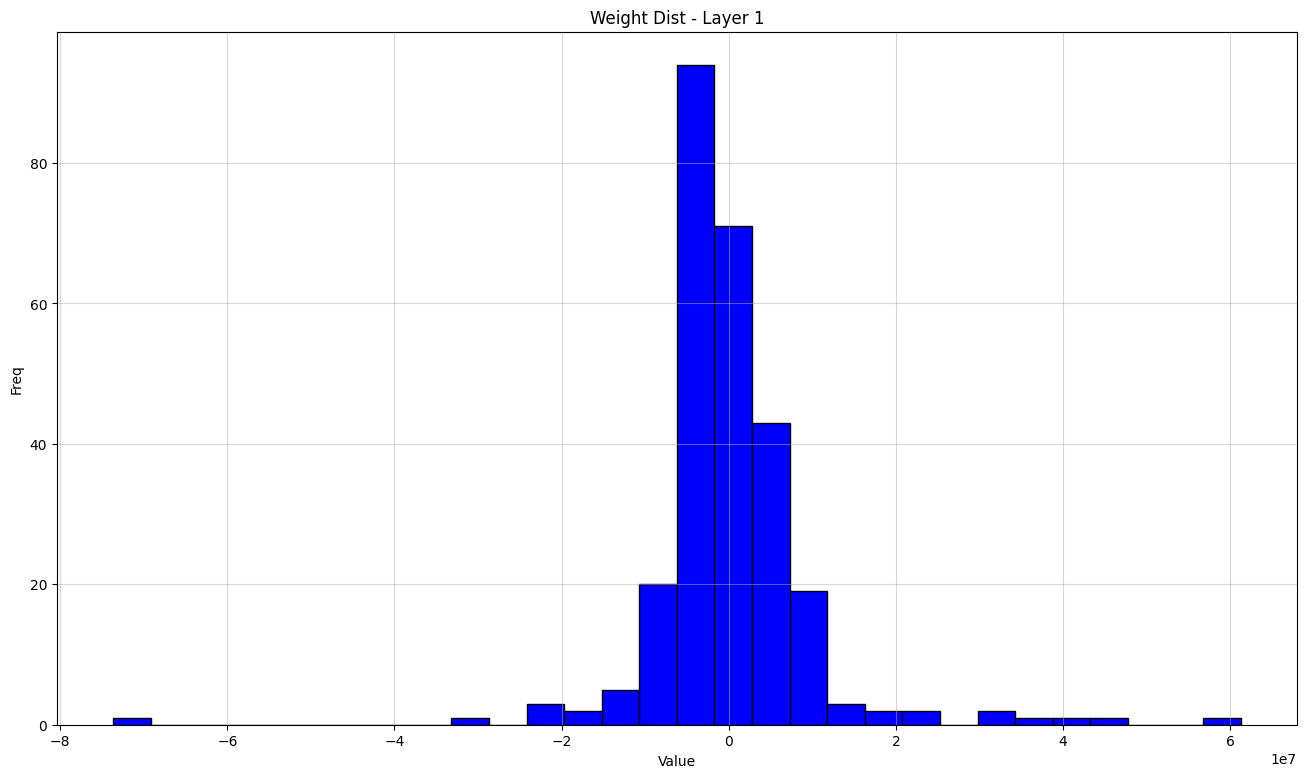

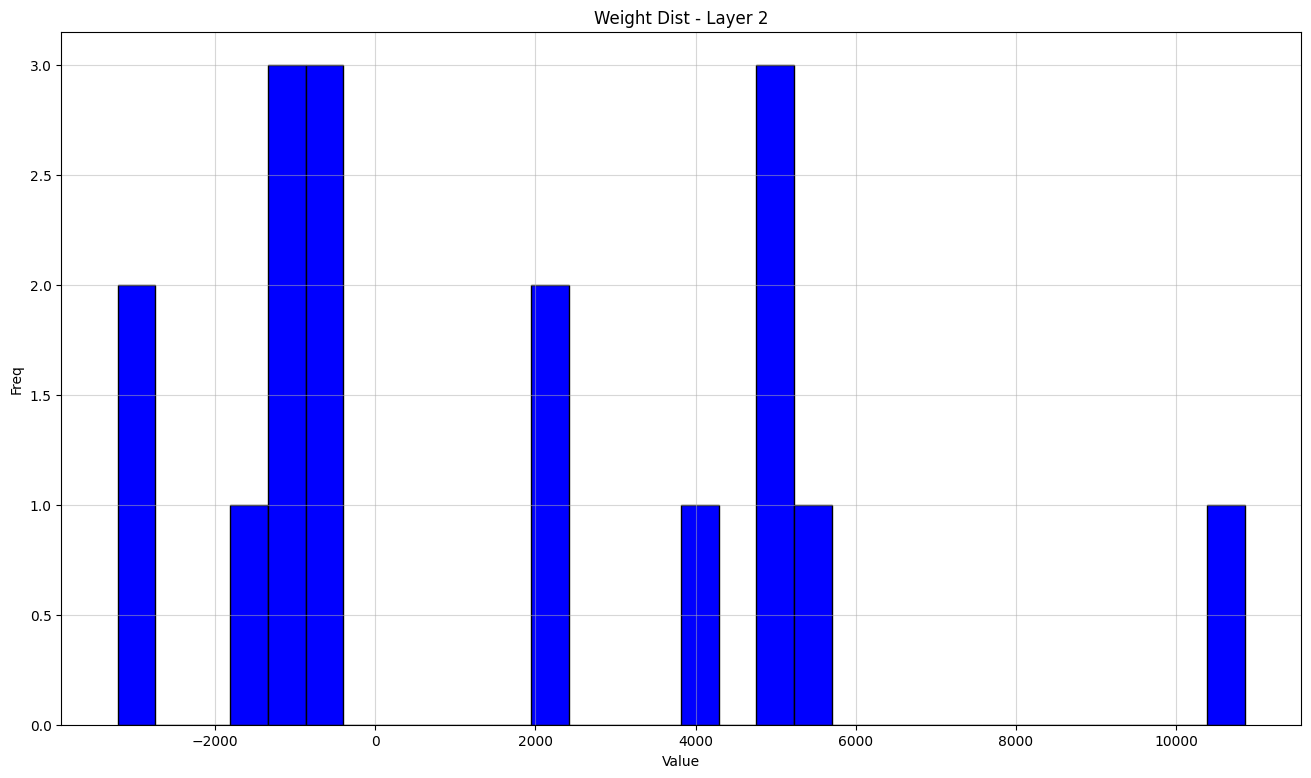

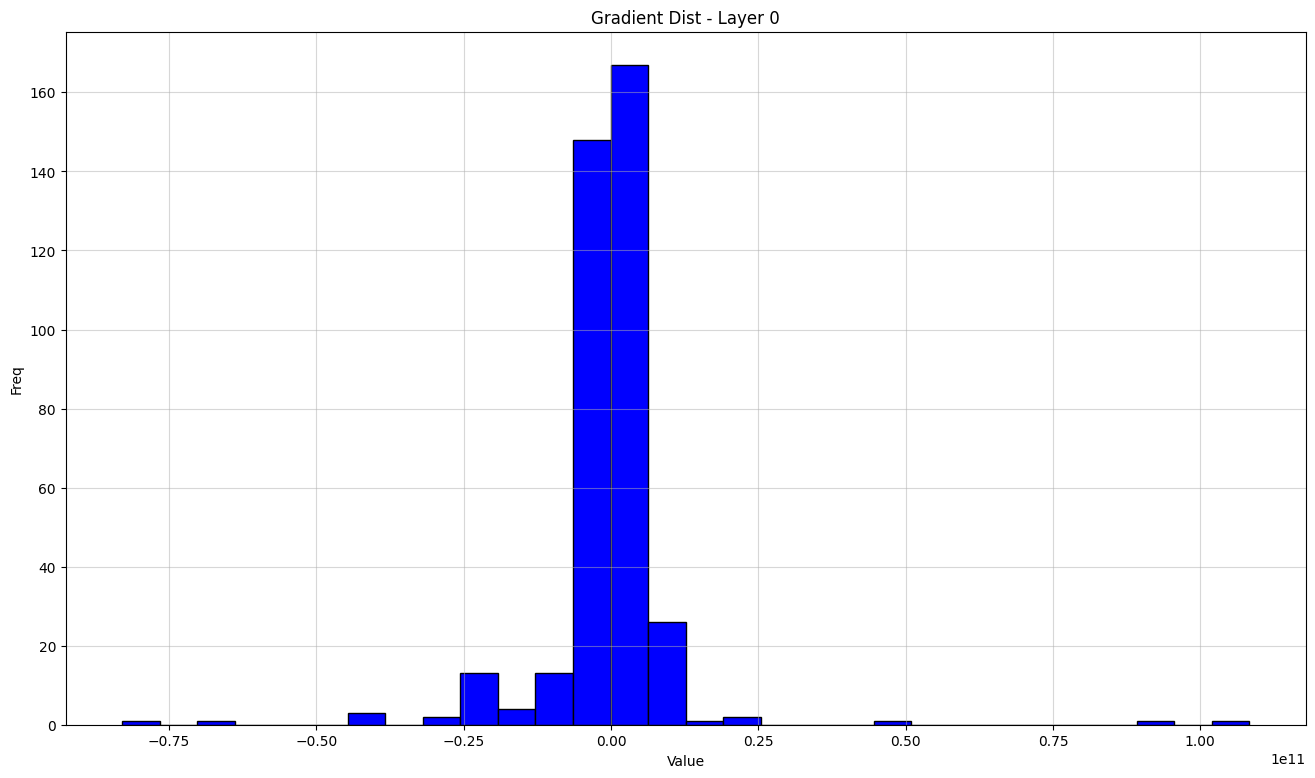

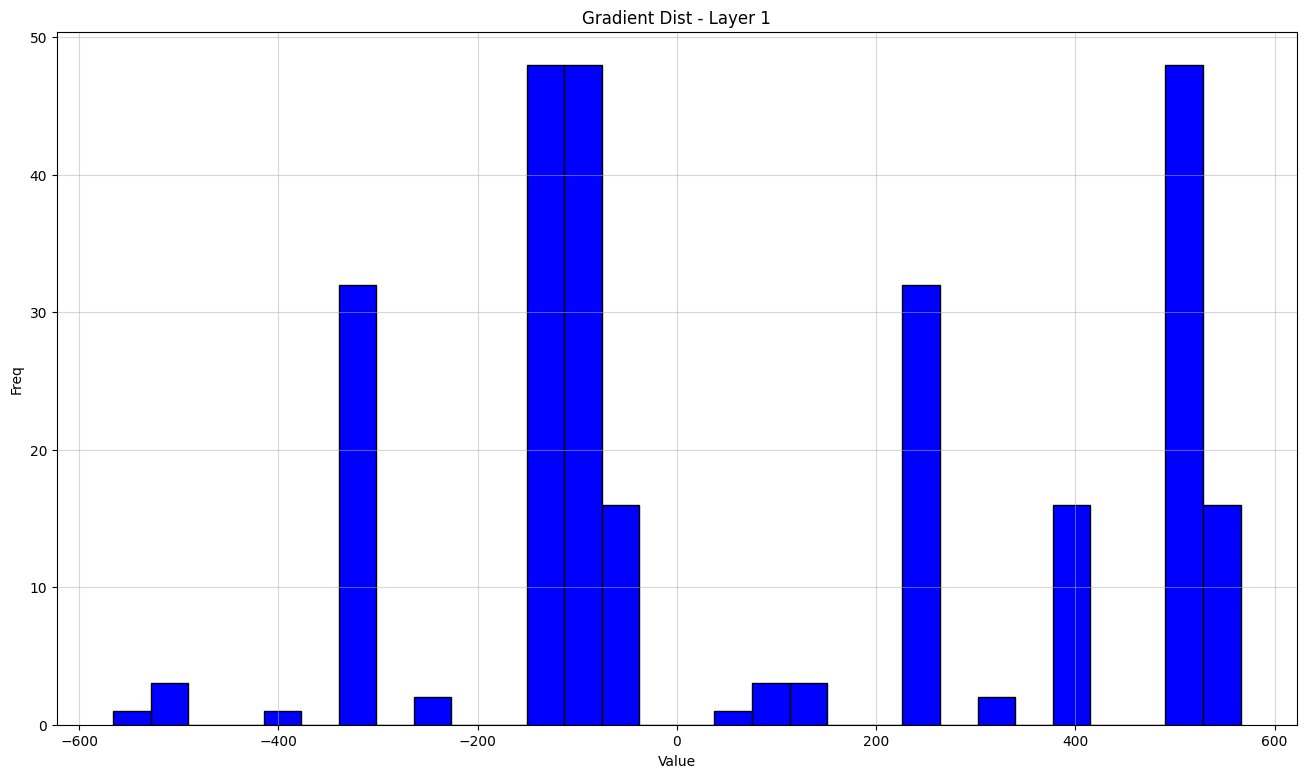

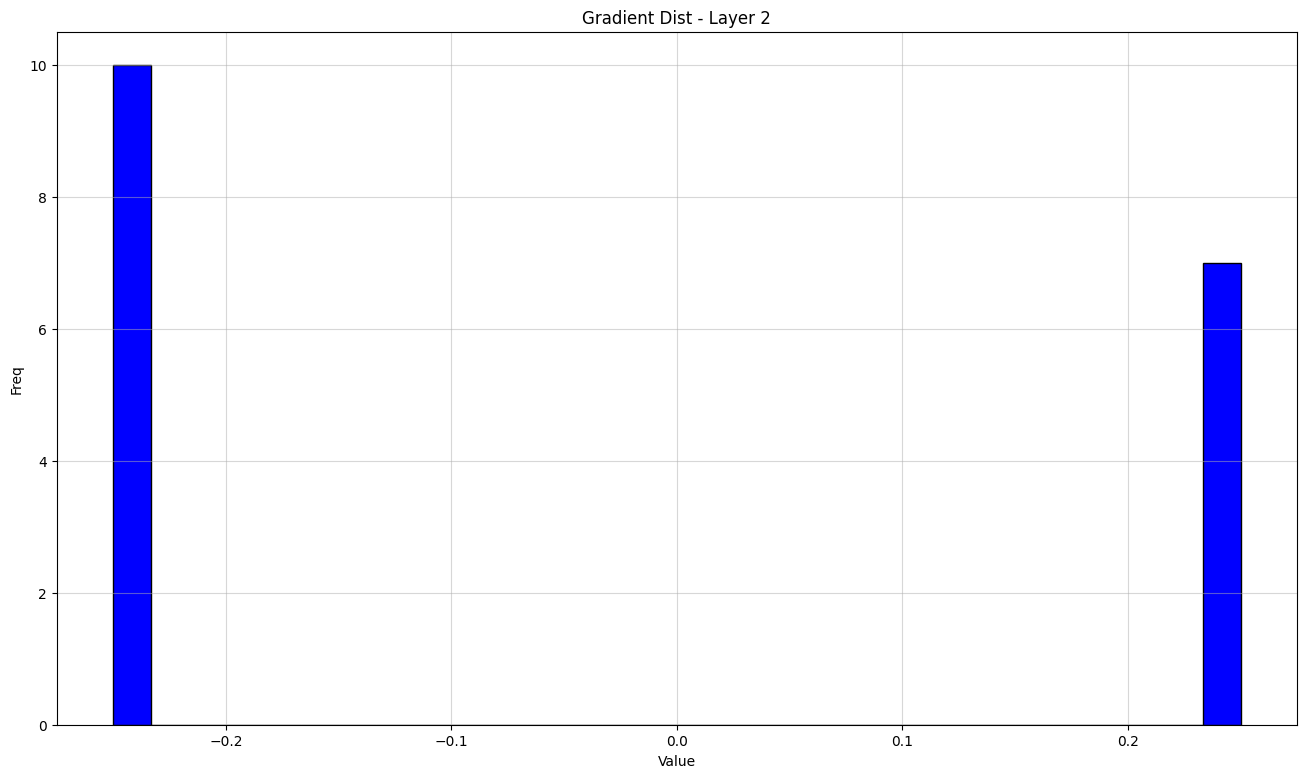

Summary reg: [{'reg': 'none', 'l1': 0.0, 'l2': 0.0, 'macro_f1': 0.7157864679828143}, {'reg': 'l1', 'l1': 0.0001, 'l2': 0.0, 'macro_f1': 0.5809952369465836}, {'reg': 'l2', 'l1': 0.0, 'l2': 0.0001, 'macro_f1': 0.6198881148929489}]


In [44]:
epochs = 30
lr = 0.01

input_dim = int(X_train.shape[1])
dims = [input_dim, 16, 16, 1]
acts = [Tanh, Tanh, Sigmoid]

lmb = 1e-4

settings = [
    ("none", 0.0, 0.0),
    ("l1", lmb, 0.0),
    ("l2", 0.0, lmb),
]

res_reg = []

for name, l1_lmb, l2_lmb in settings:
    model = FFNN(dims, acts, BCE, lr, l1_lambda=l1_lmb, l2_lambda=l2_lmb)
    model.train(X_train, y_train, epochs, True, None, X_val, y_val)

    loss_train = model.training_loss
    loss_val = model.validation_loss

    f1 = evaluate_model(model, X_val, y_val, model_name=f"[REG] {name}")
    plot_loss(loss_train, loss_val, title=f"[REG] {name} | l1={l1_lmb} l2={l2_lmb}")

    model.plot_w([0, 1, 2])
    model.plot_g([0, 1, 2])

    res_reg.append({"reg": name, "l1": l1_lmb, "l2": l2_lmb, "macro_f1": f1})

print("Summary reg:", res_reg)


In [43]:
from sklearn.neural_network import MLPClassifier

epochs = 100
lr = 0.1
input_dim = int(X_train.shape[1])
dims = [input_dim, 16, 16, 1]

y_train_skl = y_train.astype(int).reshape(-1)
y_val_skl = y_val.astype(int).reshape(-1)

clf = MLPClassifier(
    hidden_layer_sizes=(16, 16),
    activation="tanh",
    solver="sgd",
    learning_rate="constant",
    learning_rate_init=lr,
    max_iter=epochs,
    shuffle=False,
    batch_size=1,
    momentum=0.0,
    nesterovs_momentum=False,
    alpha=0.0,
    random_state=42,
    early_stopping=False,
    tol=1e-12,
)

clf.fit(X_train, y_train_skl)

y_pred_skl = clf.predict(X_val)
f1_skl = f1_score(y_val_skl, y_pred_skl, average="macro")
print("Sklearn MLP macro_f1:", f1_skl)

model = FFNN(dims, [Tanh, Tanh, Sigmoid], BCE, lr, weight_initialization="xavier", seed=42,
)

model.train(X_train, y_train, epochs, False, None, X_val, y_val)

model.predict(X_val)
y_prob_ffnn = np.asarray(model.result()).reshape(-1)
y_pred_ffnn = (y_prob_ffnn >= 0.5).astype(int)
f1_ffnn = f1_score(y_val_skl, y_pred_ffnn, average="macro")
print("FFNN from scratch macro_f1:", f1_ffnn)


Sklearn MLP macro_f1: 0.663808463923631


Training: 100%|██████████| 100/100 [00:48<00:00,  2.05it/s]

FFNN from scratch macro_f1: 0.6365517742687208


# Kesimpulan dan Saran

## Kesimpulan
Hasil dari pengujian di notebook ini didapat bahwa ffnn yang dibuat mendapatkan hasil yang lumayan bagus di beberapa saat yaitu
1. learning rate yang kecil
2. model depth yang rendah 
3. aktivasi hidden yang efektif berupa relu
4. regulasi yang tidak terlalu kecil menurunkan performa dibanding tanpa regulasi

Hasil dari ffnn dari scratch ini juga mirip dengan hasil skl dimana berbeda sekitaran 0.03

## Saran
1. mungkin untuk regulasi dapat dicoba lambda yang lebih kecil atau lebih besar agar dapat hasil yang lebih baik
2. tuning hyperparameter untuk mengatasi gradien agar tidak terlalu besar